# Data Curation for PROTAC-Splitter

## Setup and Imports

In [12]:
# from IPython.display import display_html
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = 'all'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import typing
from typing import Mapping, Literal, Callable, List, ClassVar, Any

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys, rdFMCS, Draw

from functools import partial

import sklearn
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn import preprocessing

from collections import Counter

from tqdm.auto import tqdm  # for notebooks

tqdm.pandas()

pd.set_option('display.max_columns', 1000, 'display.width', 2000, 'display.max_colwidth', 100)
data_dir = os.path.join(os.getcwd(), '..', 'data')
src_dir = os.path.join(os.getcwd(), '..', 'src')
fig_dir = os.path.join(data_dir, 'figures')
dirs_to_make = [
    src_dir,
    data_dir,
    os.path.join(data_dir, 'processed'),
    fig_dir,
]
for d in dirs_to_make:
    if not os.path.exists(d):
        os.makedirs(d)

## Load Raw Datasets

In [13]:
df_file = os.path.join(data_dir, 'raw', 'protac_pedia_20220210.csv')
protac_pedia_df = pd.read_csv(df_file)
protac_pedia_df.head()

,PROTACDB ID,PROTAC SMILES,Active/Inactive,Best PROTAC,Cells,cLogP,Comments,Curator,Dc50,Dmax,E3 Binder SMILES,E3 Ligase,Ec50 of Ligand Cells,Ec50 of PROTAC Cells,exit_vector,Hbond acceptors,Hbond donors,Ic50 of Ligand,Ic50 of PROTAC,Ligand Name,Ligand SMILES,Linker,Linker Type,linker_ha,linker_no,linker_rb,MW,Off Targets Reported,PATENT,Ligand PDB,Ligand ID,Pubmed,PROTAC Name,Proteomics Data Available,Secondary Pubmed,Status,Target,Tested A Non Binding E3 Control,Tested Competition With Ligand,Tested Engagement In Cells,Tested Proteaseome Inhibitor,Time,TPSA
0,1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,Inactive,No,MOLT-4,10.83732,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,VHL,NaN,NaN,morpholine_to_piperazine,17,5,NaN,NaN,ABT-263,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,NC(=O)CC=O,Alkane,6,3,2,1486.282,No degradation of BCL2,NaN,4QNQ,1XJ,32145645.0,1a,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
1,2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,Inactive,No,MOLT-4,11.22742,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,VHL,NaN,NaN,morpholine_to_piperazine,17,5,NaN,NaN,ABT-263,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,NC(=O)CCC=O,Alkane,7,3,3,1500.309,No degradation of BCL2,NaN,4QNQ,1XJ,32145645.0,1b,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
2,3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,Inactive,No,MOLT-4,11.61752,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,VHL,NaN,NaN,morpholine_to_piperazine,17,5,NaN,NaN,ABT-263,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,NC(=O)CCCC=O,Alkane,8,3,4,1514.336,No degradation of BCL2,NaN,4QNQ,1XJ,32145645.0,1c,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
3,4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,Active,No,MOLT-4,12.00762,IC50's are for cell viability assays,Ronen Gabizon,NaN,NaN,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,VHL,NaN,NaN,morpholine_to_piperazine,17,5,NaN,NaN,ABT-263,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,NC(=O)CCCCC=O,Alkane,9,3,5,1528.363,No degradation of BCL2,NaN,4QNQ,1XJ,32145645.0,1d,No,NaN,Reviewed,Q07817,No,No,No,No,48,251.07
4,5,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,Active,No,MOLT-4,12.39772,IC50's are for cell viability assays,Ronen Gabizon,53 nM,~ 100 %,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,VHL,NaN,NaN,morpholine_to_piperazine,17,5,NaN,NaN,ABT-263,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,NC(=O)CCCCCC=O,Alkane,10,3,6,1542.390,No degradation of BCL2,NaN,4QNQ,1XJ,32145645.0,1e (DT2216),No,NaN,Reviewed,Q07817,No,No,Yes,No,48,251.07


Drop NaN and duplicates:

In [14]:
cols = ['PROTAC SMILES', 'E3 Binder SMILES', 'Linker', 'Ligand SMILES']
protac_pedia_df = protac_pedia_df[cols].dropna().drop_duplicates()
old2new = {
    'Linker': 'Linker SMILES',
    'Ligand SMILES': 'POI Ligand SMILES',
}
protac_pedia_df = protac_pedia_df.rename(columns=old2new)
protac_pedia_df.head()

,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...


Some entries have identical POI ligand and E3 binder, we remove them:

In [15]:
print(f'Before removal: {len(protac_pedia_df)}')
protac_pedia_df = protac_pedia_df[protac_pedia_df['POI Ligand SMILES'] != protac_pedia_df['E3 Binder SMILES']]
print(f'After removal: {len(protac_pedia_df)}')

Before removal: 1203
After removal: 1195


From [PROTAC-DB paper](https://academic.oup.com/nar/article/49/D1/D1381/5917660?login=false#:~:text=For%20linkers%2C%20only%20the%202D%20structures%2C%20compound%20IDs%20and%20targeted%20proteins%20are%20shown%20in%20the%20datasheet.%20The%20%E2%80%98R1%E2%80%99%20and%20%E2%80%98R2%E2%80%99%20in%20the%20structures%20represent%20the%20sites%20that%20conjugate%20warheads%20and%20E3%20ligands%2C%20respectively.):

> For linkers, only the 2D structures, compound IDs and targeted proteins are shown in the datasheet. The ‘R1’ and ‘R2’ in the structures represent the sites that conjugate warheads and E3 ligands, respectively.

In [16]:
protac_db_df = pd.read_csv(os.path.join(data_dir, 'raw', 'protac_db.csv')).reset_index(drop=True)
protac_db_linker_df = pd.read_csv(os.path.join(data_dir, 'raw', 'protac_db_linkers.csv')).reset_index(drop=True)
protac_db_e3_df = pd.read_csv(os.path.join(data_dir, 'raw', 'protac_db_e3_ligands.csv')).reset_index(drop=True)
protac_db_poi_df = pd.read_csv(os.path.join(data_dir, 'raw', 'protac_db_poi_binders.csv')).reset_index(drop=True)

print('protac_db_df:', len(protac_db_df['Compound ID'].unique()))
print('protac_db_poi_df:', len(protac_db_poi_df['Compound ID'].unique()))
print('protac_db_linker_df:', len(protac_db_linker_df['Compound ID'].unique()))
print('protac_db_e3_df:', len(protac_db_e3_df['Compound ID'].unique()))

protac_db_df: 3270
protac_db_poi_df: 365
protac_db_linker_df: 1501
protac_db_e3_df: 82


Isolate SMILES-related columns and remove duplicates:

In [17]:
protac_db_linker_df = protac_db_linker_df.rename(columns={'Smiles': 'Linker SMILES', 'Smiles_R': 'Linker SMARTS'})
protac_db_df = protac_db_df.rename(columns={'Smiles': 'PROTAC SMILES'})
protac_db_e3_df = protac_db_e3_df.rename(columns={'Smiles': 'E3 Binder SMILES'})
protac_db_poi_df = protac_db_poi_df.rename(columns={'Smiles': 'POI Ligand SMILES'})

protac_db_linker_df = protac_db_linker_df.drop_duplicates(subset=['Linker SMILES', 'Linker SMARTS'])
protac_db_df = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
protac_db_e3_df = protac_db_e3_df.drop_duplicates(subset=['E3 Binder SMILES'])
protac_db_poi_df = protac_db_poi_df.drop_duplicates(subset=['POI Ligand SMILES'])
print('protac_db_df:', len(protac_db_df))
print('protac_db_linker_df:', len(protac_db_linker_df))
print('protac_db_e3_df:', len(protac_db_e3_df))
print('protac_db_poi_df:', len(protac_db_poi_df))

protac_db_df: 3270
protac_db_linker_df: 1501
protac_db_e3_df: 82
protac_db_poi_df: 365


Cannonize SMILES:

In [18]:
def canonize_smiles(smiles):
    try:
        return Chem.MolToSmiles(Chem.MolFromSmiles(smiles), canonical=True)
    except:
        return np.nan

smiles_cols = ['PROTAC SMILES', 'E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
for c in smiles_cols:
    protac_pedia_df[c] = protac_pedia_df[c].progress_apply(lambda x: canonize_smiles(x))

protac_db_df['PROTAC SMILES'] = protac_db_df['PROTAC SMILES'].progress_apply(lambda x: canonize_smiles(x))
protac_db_e3_df['E3 Binder SMILES'] = protac_db_e3_df['E3 Binder SMILES'].progress_apply(lambda x: canonize_smiles(x))
protac_db_linker_df['Linker SMILES'] = protac_db_linker_df['Linker SMILES'].progress_apply(lambda x: canonize_smiles(x))
protac_db_poi_df['POI Ligand SMILES'] = protac_db_poi_df['POI Ligand SMILES'].progress_apply(lambda x: canonize_smiles(x))

protac_pedia_df = protac_pedia_df.dropna(subset=smiles_cols)
protac_db_df = protac_db_df.dropna(subset='PROTAC SMILES')
protac_db_e3_df = protac_db_e3_df.dropna(subset='E3 Binder SMILES')
protac_db_linker_df = protac_db_linker_df.dropna(subset='Linker SMILES')
protac_db_poi_df = protac_db_poi_df.dropna(subset='POI Ligand SMILES')
# protac_pedia_df.head()

  0%|          | 0/1195 [00:00<?, ?it/s]

  0%|          | 0/1195 [00:00<?, ?it/s]

  0%|          | 0/1195 [00:00<?, ?it/s]

[15:22:38] SMILES Parse Error: syntax error while parsing: None
[15:22:38] SMILES Parse Error: Failed parsing SMILES 'None' for input: 'None'
[15:22:38] non-ring atom 0 marked aromatic
[15:22:38] non-ring atom 0 marked aromatic
[15:22:38] non-ring atom 5 marked aromatic
[15:22:38] non-ring atom 8 marked aromatic
[15:22:38] non-ring atom 11 marked aromatic
[15:22:38] non-ring atom 14 marked aromatic
[15:22:38] non-ring atom 0 marked aromatic
[15:22:38] SMILES Parse Error: syntax error while parsing: None
[15:22:38] SMILES Parse Error: Failed parsing SMILES 'None' for input: 'None'
[15:22:38] non-ring atom 5 marked aromatic
[15:22:38] SMILES Parse Error: syntax error while parsing: None
[15:22:38] SMILES Parse Error: Failed parsing SMILES 'None' for input: 'None'
[15:22:38] SMILES Parse Error: syntax error while parsing: None
[15:22:38] SMILES Parse Error: Failed parsing SMILES 'None' for input: 'None'
[15:22:38] non-ring atom 0 marked aromatic
[15:22:38] non-ring atom 0 marked aromatic


  0%|          | 0/1195 [00:00<?, ?it/s]

  0%|          | 0/3270 [00:00<?, ?it/s]

  0%|          | 0/82 [00:00<?, ?it/s]

  0%|          | 0/1501 [00:00<?, ?it/s]

  0%|          | 0/365 [00:00<?, ?it/s]

Remove stereo-chemistry:

In [19]:
def remove_stereo(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        Chem.rdmolops.RemoveStereochemistry(mol)
        return Chem.MolToSmiles(mol)
    except:
        return np.nan

for c in smiles_cols:
    protac_pedia_df[c] = protac_pedia_df[c].progress_apply(lambda x: remove_stereo(x))

protac_db_df['PROTAC SMILES'] = protac_db_df['PROTAC SMILES'].progress_apply(lambda x: remove_stereo(x))
protac_db_e3_df['E3 Binder SMILES'] = protac_db_e3_df['E3 Binder SMILES'].progress_apply(lambda x: remove_stereo(x))
protac_db_linker_df['Linker SMILES'] = protac_db_linker_df['Linker SMILES'].progress_apply(lambda x: remove_stereo(x))
protac_db_poi_df['POI Ligand SMILES'] = protac_db_poi_df['POI Ligand SMILES'].progress_apply(lambda x: remove_stereo(x))

protac_pedia_df = protac_pedia_df.dropna(subset=smiles_cols)
protac_db_df = protac_db_df.dropna(subset='PROTAC SMILES')
protac_db_e3_df = protac_db_e3_df.dropna(subset='E3 Binder SMILES')
protac_db_linker_df = protac_db_linker_df.dropna(subset='Linker SMILES')
protac_db_poi_df = protac_db_poi_df.dropna(subset='POI Ligand SMILES')
# protac_pedia_df.head()

  0%|          | 0/1167 [00:00<?, ?it/s]

  0%|          | 0/1167 [00:00<?, ?it/s]

  0%|          | 0/1167 [00:00<?, ?it/s]

  0%|          | 0/1167 [00:00<?, ?it/s]

  0%|          | 0/3270 [00:00<?, ?it/s]

  0%|          | 0/82 [00:00<?, ?it/s]

  0%|          | 0/1501 [00:00<?, ?it/s]

  0%|          | 0/365 [00:00<?, ?it/s]

In [20]:
def get_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    Chem.rdmolops.RemoveStereochemistry(mol)
    return mol

In [21]:
fpgen = AllChem.GetRDKitFPGenerator()

def get_tanimoto(elem1, elem2):
    """Get the Tanimoto similarity between two SMILES."""
    if isinstance(elem1, str):
        mol1 = Chem.MolFromSmiles(elem1)
    else:
        mol1 = elem1
    if isinstance(elem2, str):
        mol2 = Chem.MolFromSmiles(elem2)
    else:
        mol2 = elem2
    fp1 = fpgen.GetFingerprint(mol1)
    fp2 = fpgen.GetFingerprint(mol2)
    return DataStructs.TanimotoSimilarity(fp1, fp2)

In [22]:
def add_mol_col(row, substruct_name='E3 Binder'):
    row['Molecule'] = get_mol(row[f'{substruct_name} SMILES'])
    return row

def add_fp_col(row, substruct_name='E3 Binder'):
    mol = get_mol(row[f'{substruct_name} SMILES'])
    row[f'{substruct_name} FP'] = fpgen.GetFingerprint(mol)
    return row

# Mol column
tqdm.pandas(desc="Adding molecule column", postfix=None)
protac_db_df = protac_db_df.progress_apply(lambda x: add_mol_col(x, substruct_name='PROTAC'), axis=1)
protac_db_e3_df = protac_db_e3_df.progress_apply(lambda x: add_mol_col(x, substruct_name='E3 Binder'), axis=1)
protac_db_linker_df = protac_db_linker_df.progress_apply(lambda x: add_mol_col(x, substruct_name='Linker'), axis=1)
protac_db_poi_df = protac_db_poi_df.progress_apply(lambda x: add_mol_col(x, substruct_name='POI Ligand'), axis=1)
# FP column
tqdm.pandas(desc="Adding FP column", postfix=None)
protac_db_df = protac_db_df.progress_apply(lambda x: add_fp_col(x, substruct_name='PROTAC'), axis=1)
protac_db_e3_df = protac_db_e3_df.progress_apply(lambda x: add_fp_col(x, substruct_name='E3 Binder'), axis=1)
protac_db_linker_df = protac_db_linker_df.progress_apply(lambda x: add_fp_col(x, substruct_name='Linker'), axis=1)
protac_db_poi_df = protac_db_poi_df.progress_apply(lambda x: add_fp_col(x, substruct_name='POI Ligand'), axis=1)

# Mol column
tqdm.pandas(desc="Adding molecule column", postfix=None)
protac_pedia_df = protac_pedia_df.progress_apply(lambda x: add_mol_col(x, substruct_name='PROTAC'), axis=1)
protac_pedia_e3_df = protac_pedia_df.dropna(subset='E3 Binder SMILES').progress_apply(lambda x: add_mol_col(x, substruct_name='E3 Binder'), axis=1)
protac_pedia_linker_df = protac_pedia_df.dropna(subset='Linker SMILES').progress_apply(lambda x: add_mol_col(x, substruct_name='Linker'), axis=1)
protac_pedia_poi_df = protac_pedia_df.dropna(subset='POI Ligand SMILES').progress_apply(lambda x: add_mol_col(x, substruct_name='POI Ligand'), axis=1)
# FP column
tqdm.pandas(desc="Adding FP column", postfix=None)
protac_pedia_df = protac_pedia_df.progress_apply(lambda x: add_fp_col(x, substruct_name='PROTAC'), axis=1)
protac_pedia_e3_df = protac_pedia_e3_df.progress_apply(lambda x: add_fp_col(x, substruct_name='E3 Binder'), axis=1)
protac_pedia_linker_df = protac_pedia_linker_df.progress_apply(lambda x: add_fp_col(x, substruct_name='Linker'), axis=1)
protac_pedia_poi_df = protac_pedia_poi_df.progress_apply(lambda x: add_fp_col(x, substruct_name='POI Ligand'), axis=1)

Adding molecule column:   0%|          | 0/3270 [00:00<?, ?it/s]

Adding molecule column:   0%|          | 0/82 [00:00<?, ?it/s]

Adding molecule column:   0%|          | 0/1501 [00:00<?, ?it/s]

Adding molecule column:   0%|          | 0/365 [00:00<?, ?it/s]

Adding FP column:   0%|          | 0/3270 [00:00<?, ?it/s]

...

Adding molecule column:   0%|          | 0/1167 [00:00<?, ?it/s]

Adding FP column:   0%|          | 0/1167 [00:00<?, ?it/s]

Adding FP column:   0%|          | 0/1167 [00:00<?, ?it/s]

Adding FP column:   0%|          | 0/1167 [00:00<?, ?it/s]

Adding FP column:   0%|          | 0/1167 [00:00<?, ?it/s]

## Data Analysis and Visualization

In [23]:
# Count unique values per columns
protac_db_df.nunique()

print(protac_pedia_df[smiles_cols].nunique())
print("protac_db_df['PROTAC SMILES']:", protac_db_df['PROTAC SMILES'].nunique())
print("protac_db_e3_df['E3 Binder SMILES']:", protac_db_e3_df['E3 Binder SMILES'].nunique())
print("protac_db_linker_df['Linker SMILES']:", protac_db_linker_df['Linker SMILES'].nunique())
print("protac_db_poi_df['POI Ligand SMILES']:", protac_db_poi_df['POI Ligand SMILES'].nunique())

PROTAC SMILES        1133
E3 Binder SMILES       55
Linker SMILES         641
POI Ligand SMILES     165
dtype: int64
protac_db_df['PROTAC SMILES']: 3253
protac_db_e3_df['E3 Binder SMILES']: 75
protac_db_linker_df['Linker SMILES']: 1389
protac_db_poi_df['POI Ligand SMILES']: 362


In [24]:
for i in range(len(protac_pedia_df)):
    row = protac_pedia_df.iloc[i]
    smiles = f"{row['E3 Binder SMILES']}.{row['Linker SMILES']}.{row['POI Ligand SMILES']}>>{row['PROTAC SMILES']}"
    if len(smiles) < 350:
        print(smiles)
        break

Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O.CCCC(N)=O.CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCOCC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1>>CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCN(C(=O)CCCNc6cccc7c6C(=O)N(C6CCC(=O)NC6=O)C7=O)CC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1


CNC(C)C(=O)NC(C(=O)N1Cc2ccccc2CC1C(=O)NC1CCCc2ccccc21)C(C)(C)C


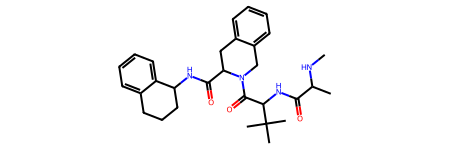

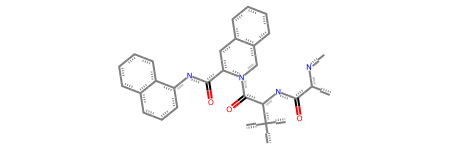

CNC(C)C(=O)NC(C(=O)N1Cc2ccccc2CC1C(=O)NC1CCCc2ccccc21)C(C)(C)C
--------------------------------------------------------------------------------
Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O


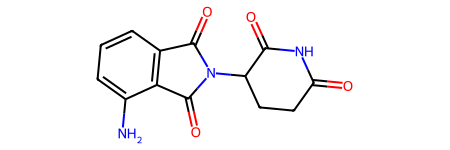

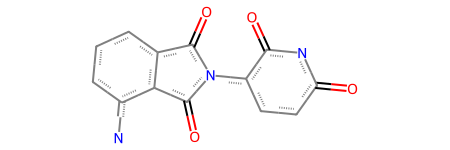

Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O


In [25]:
# List all unique E3 binders in PROTAC DB
smiles = protac_db_e3_df['E3 Binder SMILES'].unique()[0]
print(smiles)
display(Chem.MolFromSmiles(smiles))
display(Chem.MolFromSmarts(smiles))
print(Chem.MolToSmarts(Chem.MolFromSmarts(smiles)))
print('-' * 80)

smiles = protac_db_e3_df['E3 Binder SMILES'].unique()[1]
print(smiles)
display(Chem.MolFromSmiles(smiles))
display(Chem.MolFromSmarts(smiles))
print(Chem.MolToSmarts(Chem.MolFromSmarts(smiles)))

## PROTAC-Pedia

In [26]:
def get_substruct_match(
    row,
    substruct_names = ['POI Ligand SMILES', 'Linker SMILES', 'E3 Binder SMILES'],
):
    protac_mol = get_mol(row['PROTAC SMILES'])
    # Iterate over protac_pedia_df rows
    for substruct_name in substruct_names:
        substruct_match_name = f'{substruct_name.replace(" SMILES", "")} Matching'
        row[substruct_match_name] = float('nan')
        substruct_mol = get_mol(row[substruct_name])
        if substruct_mol is not None:
            if protac_mol.HasSubstructMatch(substruct_mol):
                row[substruct_match_name] = True
            else:
                row[substruct_match_name] = False
    return row

smiles_cols = ['PROTAC SMILES', 'E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
tmp = protac_pedia_df.dropna(subset=smiles_cols)

tqdm.pandas(desc="Adding substruct match columns", postfix=None)
tmp = tmp.progress_apply(get_substruct_match, axis=1)
# print(tmp['E3 Binder Matching'].value_counts())
# print(tmp['POI Ligand Matching'].value_counts())
# print(tmp['Linker Matching'].value_counts())
# Get matching combinations
all_matching = tmp[(tmp['E3 Binder Matching'] == True) & (tmp['POI Ligand Matching'] == True) & (tmp['Linker Matching'] == True)]
e3_poi_matching = tmp[(tmp['E3 Binder Matching'] == True) & (tmp['POI Ligand Matching'] == True)]
e3_linker_matching = tmp[(tmp['E3 Binder Matching'] == True) & (tmp['Linker Matching'] == True)]
poi_linker_matching = tmp[(tmp['POI Ligand Matching'] == True) & (tmp['Linker Matching'] == True)]

match_cols = [s.replace('SMILES', 'Matching') for s in smiles_cols[1:]]
print(f'{tmp[match_cols].value_counts()}', end='\n\n')
print(f'all_matching:\n{all_matching[match_cols].value_counts()}', end='\n\n')
print(f'e3_poi_matching:\n{e3_poi_matching[match_cols].value_counts()}', end='\n\n')
print(f'e3_linker_matching:\n{e3_linker_matching[match_cols].value_counts()}', end='\n\n')
print(f'poi_linker_matching:\n{poi_linker_matching[match_cols].value_counts()}', end='\n\n')

Adding substruct match columns:   0%|          | 0/1167 [00:00<?, ?it/s]

E3 Binder Matching  Linker Matching  POI Ligand Matching
True                True             True                   635
                                     False                  389
False               True             True                    99
                                     False                   44
dtype: int64

all_matching:
E3 Binder Matching  Linker Matching  POI Ligand Matching
True                True             True                   635
dtype: int64

e3_poi_matching:
E3 Binder Matching  Linker Matching  POI Ligand Matching
True                True             True                   635
dtype: int64

e3_linker_matching:
E3 Binder Matching  Linker Matching  POI Ligand Matching
True                True             True                   635
                                     False                  389
dtype: int64

poi_linker_matching:
E3 Binder Matching  Linker Matching  POI Ligand Matching
True                True             True                   635
False      

In [27]:
# Print len of matching combinations
print('at least one non-matching len:', len(tmp[(tmp['E3 Binder Matching'] == False) | (tmp['POI Ligand Matching'] == False) | (tmp['Linker Matching'] == False)]))
print('all-matching len:', len(all_matching))
print('E3+POI-matching len:', len(e3_poi_matching))
print('E3+Linker-matching len:', len(e3_linker_matching))
print('POI+Linker-matching len:', len(poi_linker_matching))

print((all_matching.index == e3_poi_matching.index).all())

at least one non-matching len: 532
all-matching len: 635
E3+POI-matching len: 635
E3+Linker-matching len: 1024
POI+Linker-matching len: 734
True


### Check if all atoms are the same

{'C': 0, 'N': 0, 'S': 0, 'O': 1, 'Cl': 0, 'F': 0}


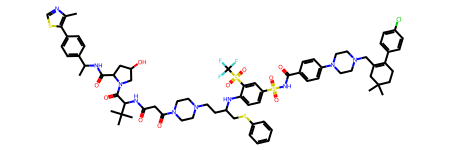

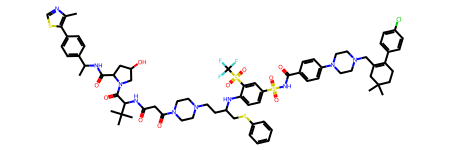

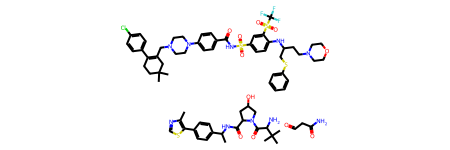

Checking same atoms counts:   0%|          | 0/635 [00:00<?, ?it/s]

540

In [28]:
def same_atom_counts_and_types(smiles1, smiles2, get_atoms_diff=False):
    """
    Check if two molecules have the same number and types of atoms.

    Args:
    smiles1 (str): SMILES notation for the first molecule.
    smiles2 (str): SMILES notation for the second molecule.

    Returns:
    bool: True if the molecules have the same atom counts and types, False otherwise.
    """
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 is None or mol2 is None:
        if get_atoms_diff:
            raise ValueError("Invalid SMILES notation provided for one or both molecules.")
        else:
            return False
    atom_counts1, atom_counts2 = {}, {}
    for atom in mol1.GetAtoms():
        if '*' not in atom.GetSmarts():
            atom_counts1[atom.GetSymbol()] = atom_counts1.get(atom.GetSymbol(), 0) + 1
    for atom in mol2.GetAtoms():
        if '*' not in atom.GetSmarts():
            atom_counts2[atom.GetSymbol()] = atom_counts2.get(atom.GetSymbol(), 0) + 1
    # atom_counts1 = {atom.GetSymbol(): atom.GetIdx() for atom in mol1.GetAtoms()}
    # atom_counts2 = {atom.GetSymbol(): atom.GetIdx() for atom in mol2.GetAtoms()}
    if get_atoms_diff:
        tmp = {}
        for atom in atom_counts1.keys():
            tmp[atom] = int(abs(atom_counts1.get(atom, 0) - atom_counts2.get(atom, 0)))
        for atom in atom_counts2.keys():
            tmp[atom] = int(abs(atom_counts1.get(atom, 0) - atom_counts2.get(atom, 0)))
        return tmp # abs(atom_counts1.get('O', 0) - atom_counts2.get('O', 0))
    else:
        return atom_counts1 == atom_counts2

x = protac_pedia_df.iloc[0]
oxygen_diff = same_atom_counts_and_types(x['PROTAC SMILES'], '.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']]), get_atoms_diff=True)
print(oxygen_diff)

display(Chem.MolFromSmiles(x['PROTAC SMILES']))
display(Chem.MolFromSmiles(x['PROTAC SMILES']))
display(Chem.MolFromSmiles('.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']])))

tqdm.pandas(desc="Checking same atoms counts", postfix=None)
same_atoms = all_matching.progress_apply(lambda x: same_atom_counts_and_types(x['PROTAC SMILES'], '.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']])), axis=1)
all_matching_same_atoms = all_matching[same_atoms == True]
len(all_matching_same_atoms)

Example of matching atoms counts:
Atoms difference: {'C': 0, 'N': 0, 'O': 0}


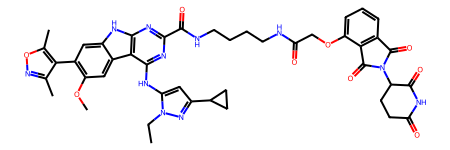

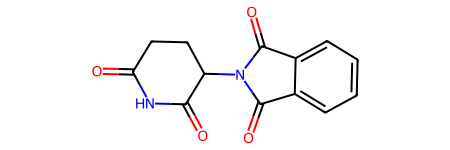

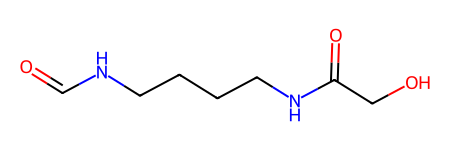

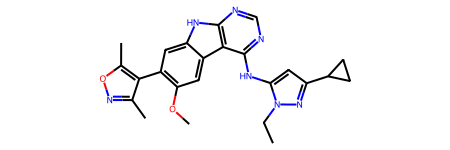

Example of non-matching atoms counts:
Atoms difference: {'C': 1, 'O': 0, 'N': 0, 'Cl': 0}


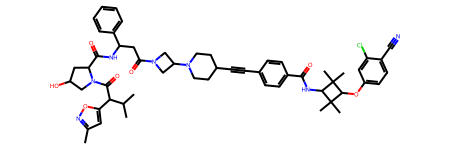

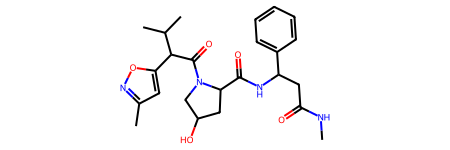

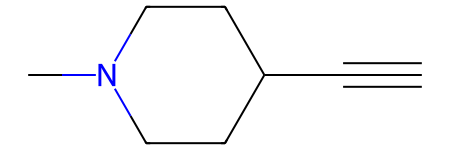

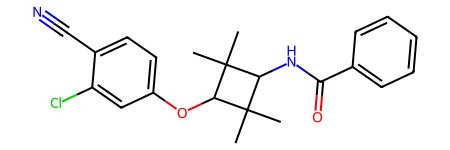

In [29]:
print('Example of matching atoms counts:')
row = all_matching_same_atoms.iloc[17]
substruct = '.'.join([row[s] for s in smiles_cols[1:]])
diff = same_atom_counts_and_types(row['PROTAC SMILES'], substruct, get_atoms_diff=True)
print(f'Atoms difference: {diff}')
display(Chem.MolFromSmiles(row['PROTAC SMILES']))
display(Chem.MolFromSmiles(row['E3 Binder SMILES']))
display(Chem.MolFromSmiles(row['Linker SMILES']))
display(Chem.MolFromSmiles(row['POI Ligand SMILES']))

print('Example of non-matching atoms counts:')
row = all_matching[same_atoms == False].iloc[17]
substruct = '.'.join([row[s] for s in smiles_cols[1:]])
diff = same_atom_counts_and_types(row['PROTAC SMILES'], substruct, get_atoms_diff=True)
print(f'Atoms difference: {diff}')
display(Chem.MolFromSmiles(row['PROTAC SMILES']))
display(Chem.MolFromSmiles(row['E3 Binder SMILES']))
display(Chem.MolFromSmiles(row['Linker SMILES']))
display(Chem.MolFromSmiles(row['POI Ligand SMILES']))

### Get Non-Matching Atoms

In [30]:
def get_atom_diff(row):
    smi_cols = ['E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
    substruct = '.'.join([row[s] for s in smi_cols])
    diff = same_atom_counts_and_types(x['PROTAC SMILES'], substruct, get_atoms_diff=True)
    for atom, diff in diff.items():
        row[f'Atom {atom}'] = diff
    return row

smiles_cols = ['PROTAC SMILES', 'E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
no_nans = protac_pedia_df.dropna(subset=smiles_cols)

tqdm.pandas(desc="Getting atoms difference", postfix=None)
atom_diff = no_nans.progress_apply(get_atom_diff, axis=1)
# display(atom_diff)

Getting atoms difference:   0%|          | 0/1167 [00:00<?, ?it/s]

In [31]:
# Get all entries where the atom difference is 1 for the Oxygen only, and the other differences are zero
tmp = atom_diff[atom_diff[f'Atom O'] == 1].replace(np.nan, 0) #.dropna(axis=0, how='all')
# Check that ALL other atoms, i.e., columns, difference is zero
tmp = tmp[(tmp[[c for c in tmp.columns if c != 'Atom O' and 'Atom' in c]] == 0).all(axis=1)]
tmp

,Atom Br,Atom C,Atom Cl,Atom F,Atom I,Atom N,Atom O,Atom P,Atom S,E3 Binder SMILES,Linker SMILES,Molecule,POI Ligand SMILES,PROTAC FP,PROTAC SMILES
0,0.0,0,0,0,0.0,0,1,0.0,0,Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(N)C(C)(C)C)cc1,NC(=O)CC=O,<rdkit.Chem.rdchem.Mol object at 0x00000171F90D68F0>,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(NC(CCN5CCOCC5)CSc5ccccc5)c(S(=O)(=O)...,"[1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,...",Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=O)CC(=O)N2CCN(CCC(CSc3ccccc3)Nc3ccc(S(=O)(=O)NC(=O...


In [32]:
for atom in [a.replace('Atom ', '') for a in atom_diff.columns if 'Atom' in a]:
    for num_diffs in atom_diff[f'Atom {atom}'].unique():
        if num_diffs == 0:
            continue
        tmp = no_nans[atom_diff[f'Atom {atom}'] == num_diffs]
        if len(tmp) > 0:
            print(f'Number of entries that have a {atom} atoms difference of {num_diffs}: {len(tmp)}')
            # for i in range(0, len(tmp), 10):
            #     row = tmp.iloc[i]
            #     for c in smiles_cols:
            #         print(c)
            #         display(Chem.MolFromSmiles(row[c]))
            #     print('-' * 80)
            #     if i > 3:
            #         break
# tqdm.pandas(desc="Adding substruct match columns", postfix=None)
# tmp = tmp.progress_apply(get_substruct_match, axis=1)

Number of entries that have a Br atoms difference of 1.0: 71
Number of entries that have a C atoms difference of 1: 8
Number of entries that have a C atoms difference of 2: 12
Number of entries that have a C atoms difference of 3: 10
Number of entries that have a C atoms difference of 4: 10
Number of entries that have a C atoms difference of 5: 11
Number of entries that have a C atoms difference of 9: 7
Number of entries that have a C atoms difference of 8: 12
Number of entries that have a C atoms difference of 7: 6
Number of entries that have a C atoms difference of 6: 12
Number of entries that have a C atoms difference of 10: 14
Number of entries that have a C atoms difference of 12: 22
Number of entries that have a C atoms difference of 11: 15
Number of entries that have a C atoms difference of 20: 49
Number of entries that have a C atoms difference of 17: 50
Number of entries that have a C atoms difference of 13: 30
Number of entries that have a C atoms difference of 15: 38
Number 

### Add Directionality

Before adding directionality, let's fix the POI warhead and E3 labels:

In [33]:
POI_ATTACHMENT_ID = 1
E3_ATTACHMENT_ID = 2

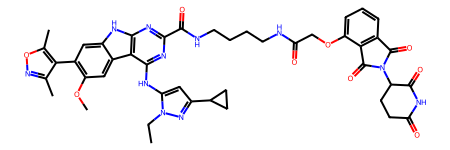

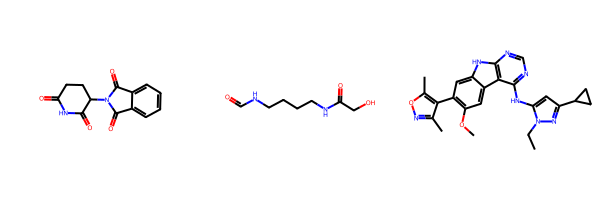

E3 Binder SMILES with direction: [*:2]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O


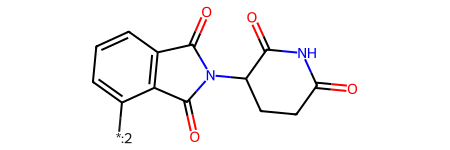

Linker SMILES with direction: [*:2]OCC(=O)NCCCCNC(=O)[*:1]


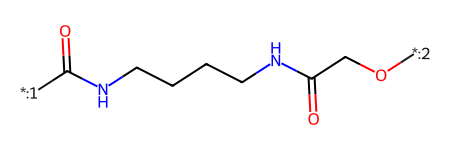

POI Ligand SMILES with direction: [*:1]c1nc(Nc2cc(C3CC3)nn2CC)c2c(n1)[nH]c1cc(-c3c(C)noc3C)c(OC)cc12


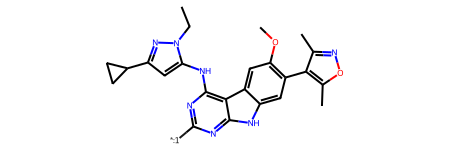

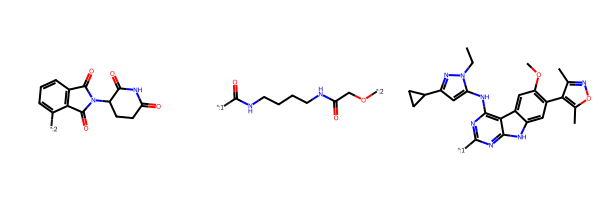

Adding directionality to PROTAC-Pedia linkers:   0%|          | 0/540 [00:00<?, ?it/s]

Adding directionality to PROTAC-Pedia POI and E3 ligands:   0%|          | 0/540 [00:00<?, ?it/s]

In [34]:
def add_linker_directionality(row):
    """Get linker with attachment points."""
    protac_mol = get_mol(row['PROTAC SMILES'])
    poi_mol = get_mol(row['POI Ligand SMILES'])
    row['Linker SMILES with direction'] = float('nan')
    if protac_mol.HasSubstructMatch(poi_mol):
        rgroups = Chem.ReplaceCore(protac_mol, poi_mol, labelByIndex=False)
        rgroups_smiles = Chem.MolToSmiles(rgroups, canonical=True)
        if len(rgroups_smiles.split("*")) == 2:
            linker_e3_smiles_mod = rgroups_smiles.replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]')
            e3_mol = get_mol(row['E3 Binder SMILES'])
            linker_e3_mol = Chem.MolFromSmiles(linker_e3_smiles_mod, sanitize=False)
            if linker_e3_mol.HasSubstructMatch(e3_mol):
                rgroups = Chem.ReplaceCore(linker_e3_mol, e3_mol, labelByIndex=False)
                rgroups_smiles = Chem.MolToSmiles(rgroups, canonical=True)
                linker_smiles_mod = rgroups_smiles.replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')
                row['Linker SMILES with direction'] = linker_smiles_mod
    return row

def add_e3_poi_directionality(row, use_linker_with_dir=True):
    """ This way you get both E3 and POI with attachment points (which you can change to something else if you like). """
    e3_smiles_mod = float('nan')
    poi_smiles_mod = float('nan')
    row['E3 Binder SMILES with direction'] = e3_smiles_mod
    row['POI Ligand SMILES with direction'] = poi_smiles_mod
    protac_mol = get_mol(row['PROTAC SMILES'])
    try:
        if use_linker_with_dir:
            linker_mol = Chem.MolFromSmarts(row['Linker SMILES with direction'])
        else:
            linker_mol = get_mol(row['Linker SMILES'])
    except TypeError:
        row['Linker SMILES'] = float('nan')
        return row
    poi_mol = get_mol(row['POI Ligand SMILES'])
    e3_mol = get_mol(row['E3 Binder SMILES'])
    if protac_mol.HasSubstructMatch(linker_mol):
        rgroups = Chem.ReplaceCore(protac_mol, linker_mol, labelByIndex=False, replaceDummies=False)
        rgroups_smiles = Chem.MolToSmiles(rgroups).split('.')
        for i, substruct_smiles in enumerate(rgroups_smiles):
            substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=False)
            if substruct_mol.HasSubstructMatch(poi_mol):
                poi_smiles_mod = substruct_smiles.replace(f'[{i+1}*]', f'[*:{POI_ATTACHMENT_ID}]')
            elif substruct_mol.HasSubstructMatch(e3_mol):
                e3_smiles_mod = substruct_smiles.replace(f'[{i+1}*]', f'[*:{E3_ATTACHMENT_ID}]')
    row['E3 Binder SMILES with direction'] = e3_smiles_mod
    row['POI Ligand SMILES with direction'] = poi_smiles_mod
    return row

row = all_matching_same_atoms.iloc[17].copy()
row = add_linker_directionality(row)
row = add_e3_poi_directionality(row)
display(Chem.MolFromSmiles(row['PROTAC SMILES']))
display(Draw.MolsToGridImage([Chem.MolFromSmiles(row['E3 Binder SMILES']), Chem.MolFromSmiles(row['Linker SMILES']), Chem.MolFromSmiles(row['POI Ligand SMILES'])]))
print('E3 Binder SMILES with direction:', row['E3 Binder SMILES with direction'])
display(Chem.MolFromSmiles(row['E3 Binder SMILES with direction']))
print('Linker SMILES with direction:', row['Linker SMILES with direction'])
display(Chem.MolFromSmiles(row['Linker SMILES with direction']))
print('POI Ligand SMILES with direction:', row['POI Ligand SMILES with direction'])
display(Chem.MolFromSmiles(row['POI Ligand SMILES with direction']))
display(Draw.MolsToGridImage([Chem.MolFromSmiles(row['E3 Binder SMILES with direction']), Chem.MolFromSmiles(row['Linker SMILES with direction']), Chem.MolFromSmiles(row['POI Ligand SMILES with direction'])]))

dir_cols = [s + ' with direction' for s in smiles_cols[1:]]
tqdm.pandas(desc='Adding directionality to PROTAC-Pedia linkers', postfix=None)
final_df = all_matching_same_atoms.progress_apply(add_linker_directionality, axis=1)
tqdm.pandas(desc='Adding directionality to PROTAC-Pedia POI and E3 ligands', postfix=None)
final_df = final_df.progress_apply(add_e3_poi_directionality, axis=1)
final_df = final_df.dropna(subset=dir_cols)

In [35]:
len(final_df)

464

In [36]:
l = len(protac_pedia_df[~protac_pedia_df.index.isin(final_df.index)])
# l = len(protac_pedia_df[~protac_pedia_df['PROTAC SMILES'].isin(final_df['PROTAC SMILES'])])
print(l)
print(l + len(final_df))

703
1167


## PROTAC-DB: Use Substructure Dictionaries

In [37]:
e3_dict = protac_db_e3_df
poi_dict = protac_db_poi_df
linker_dict = protac_db_linker_df

tmp = protac_pedia_e3_df[['Molecule', 'E3 Binder SMILES']].copy()
tmp['Compound ID'] = float('nan')
e3_dict = pd.concat([protac_db_e3_df, tmp], axis=0, ignore_index=True)
tmp = protac_pedia_poi_df[['Molecule', 'POI Ligand SMILES']].copy()
tmp['Compound ID'] = float('nan')
poi_dict = pd.concat([protac_db_poi_df, tmp], axis=0, ignore_index=True)
tmp = protac_pedia_linker_df[['Molecule', 'Linker SMILES']].copy()
tmp['Compound ID'] = float('nan')
linker_dict = pd.concat([protac_db_linker_df, tmp], axis=0, ignore_index=True)
e3_dict = e3_dict.drop_duplicates(subset=['E3 Binder SMILES'])
poi_dict = poi_dict.drop_duplicates(subset=['POI Ligand SMILES'])
linker_dict = linker_dict.drop_duplicates(subset=['Linker SMILES'])

In [38]:
def remove_attachment_points(smiles):
    """
    Remove attachment points labeled as "[*:1]" or "[*:2]" from a molecule represented by SMILES.

    Args:
    smiles (str): The SMILES notation of the molecule.

    Returns:
    str: SMILES notation of the molecule with attachment points removed.
    """
    # TODO: Barely removing the attachmnet points can result in
    # invalid SMILES... Why?
    return smiles.replace(f"[*:{POI_ATTACHMENT_ID}]", "").replace(f"[*:{E3_ATTACHMENT_ID}]", "")
    # # Create a new molecule without attachment points
    # mol = Chem.MolFromSmarts(smiles)
    # mol_smarts = Chem.MolToSmarts(mol)
    # mol_smarts = mol_smarts.replace(f"[*:{POI_ATTACHMENT_ID}]", "")
    # mol_smarts = mol_smarts.replace(f"[*:{E3_ATTACHMENT_ID}]", "")
    # new_mol = Chem.MolFromSmarts(mol_smarts)
    # if new_mol is not None:
    #     return Chem.MolToSmiles(new_mol, canonical=True)
    # else:
    #     return float("nan")

def get_substructures_from_dict(row, poi_dict, e3_dict):
    # Set default values
    row["POI Ligand Compound ID"] = float("nan")
    row["POI Ligand SMILES"] = float("nan")
    row["poi_exact_match"] = False
    row["e3_exact_match"] = False
    row["E3 Binder Compound ID"] = float("nan")
    row["E3 Binder SMILES"] = float("nan")
    row["Linker SMILES with direction"] = float("nan")
    row["Linker SMILES"] = float("nan")

    protac_smiles = row["PROTAC SMILES"]
    protac_mol = row["Molecule"]
    rgroups_smiles = ""
    # Extract the POI Ligands that are a substructure match in PROTAC molecule
    poi_matches = poi_dict["Molecule"].apply(lambda poi: protac_mol.HasSubstructMatch(poi))
    poi_matches = poi_dict[poi_matches]
    # Return if there are no matches, otherwise get the R-groups
    if poi_matches.empty:
        return row
    row["poi_exact_match"] = True
    both_matching = False
    for _, row_p in poi_matches.iterrows():
        # Get the R-groups, i.e., E3 and Linker
        poi_mol = row_p["Molecule"]
        rgroups_mol = Chem.ReplaceCore(protac_mol, poi_mol, protac_mol.GetSubstructMatch(poi_mol), labelByIndex=False)
        rgroups_smiles = Chem.MolToSmiles(rgroups_mol, canonical=True)
        rgroups_smiles = rgroups_smiles.replace("[1*]", f"[*:{POI_ATTACHMENT_ID}]")
        # If there are "floating" groups, go to the next match
        if len(rgroups_smiles.split("*")) != 2:
            continue
        # Extract the E3 Binders that are a substructure match in R-groups
        e3_matches = e3_dict["Molecule"].apply(lambda e3: protac_mol.HasSubstructMatch(e3))
        e3_matches = e3_dict[e3_matches]
        if e3_matches.empty:
            continue
        rgroups_mol = get_mol(rgroups_smiles)
        for _, row_e in e3_matches.iterrows():
            e3_mol = row_e["Molecule"]
            # if rgroups_mol.GetNumAtoms() > e3_mol.GetNumAtoms() - 1 and rgroups_mol.HasSubstructMatch(e3_mol):
            if rgroups_mol.HasSubstructMatch(e3_mol):
                linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, rgroups_mol.GetSubstructMatch(e3_mol), labelByIndex=False)
                if linker_mol is None:
                    linker_mol = Chem.ReplaceSidechains(rgroups_mol, e3_mol)
                    if linker_mol is None:
                        continue
                linker_smiles = Chem.MolToSmiles(linker_mol, canonical=True)
                linker_smiles = linker_smiles.replace("[1*]", f"[*:{E3_ATTACHMENT_ID}]")
                # If there are "floating" groups other than the linker, continue
                if "." in linker_smiles:
                    continue
                if not protac_mol.HasSubstructMatch(Chem.MolFromSmarts(linker_smiles)):
                    continue
                # If the atoms of the PROTAC and its substructures differ, continue
                substructs = [
                    linker_smiles,
                    row_p["POI Ligand SMILES"],
                    row_e["E3 Binder SMILES"],
                ]
                substructs = ".".join(substructs)
                if not same_atom_counts_and_types(protac_smiles, substructs):
                    continue
                # Set the POI based on the found one
                row["POI Ligand Compound ID"] = row_p["Compound ID"]
                row["POI Ligand SMILES"] = Chem.MolToSmiles(poi_mol, canonical=True) # row_p["POI Ligand SMILES"]
                # Set the E3 based on the found one
                row["e3_exact_match"] = True
                row["E3 Binder Compound ID"] = row_e["Compound ID"]
                row["E3 Binder SMILES"] = Chem.MolToSmiles(e3_mol, canonical=True) # row_e["E3 Binder SMILES"]
                row["Linker SMILES with direction"] = linker_smiles
                row["Linker SMILES"] = remove_attachment_points(linker_smiles)
                both_matching = True
                break
        if both_matching:
            break
    return row


smi_cols = ['E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
dir_cols = [f'{s} with direction' for s in smi_cols]

tqdm.pandas(desc="Get substructures for PROTAC-DB", postfix=None)
db = protac_db_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
db = db.dropna(subset=smi_cols)

tqdm.pandas(desc="Get substructures for PROTAC-Pedia", postfix=None)
non_matching_protac_pedia = protac_pedia_df[~protac_pedia_df.index.isin(final_df.index)]
pedia = non_matching_protac_pedia.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
pedia = pedia.dropna(subset=smi_cols)

searched_df = pd.concat([db, pedia], axis=0, ignore_index=True)
searched_df = searched_df.dropna(subset=smi_cols)
display(searched_df[['E3 Binder SMILES', 'Linker SMILES with direction', 'POI Ligand SMILES']].head())
print(len(searched_df))

Get substructures for PROTAC-DB:   0%|          | 0/3270 [00:00<?, ?it/s]

Get substructures for PROTAC-Pedia:   0%|          | 0/703 [00:00<?, ?it/s]

,E3 Binder SMILES,Linker SMILES with direction,POI Ligand SMILES
0,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]CCC[*:1],CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
1,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]CCOCCOC[*:1],CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
2,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]C[*:1],CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
3,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]CC[*:1],CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
4,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:2]CCCC[*:1],CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1


1789


In [39]:
print(len(searched_df))

1789


In [40]:
tqdm.pandas(desc="Adding substruct match columns", postfix=None)
# e3_matches = searched_df.progress_apply(lambda row: Chem.MolFromSmiles(row['PROTAC SMILES']).HasSubstructMatch(Chem.MolFromSmiles(row['E3 Binder SMILES'])), axis=1)
e3_matches = searched_df.progress_apply(lambda row: get_mol(row['PROTAC SMILES']).HasSubstructMatch(get_mol(row['E3 Binder SMILES'])), axis=1)

tqdm.pandas(desc="Adding substruct match columns", postfix=None)
# poi_matches = searched_df.progress_apply(lambda row: Chem.MolFromSmiles(row['PROTAC SMILES']).HasSubstructMatch(Chem.MolFromSmiles(row['POI Ligand SMILES'])), axis=1)
poi_matches = searched_df.progress_apply(lambda row: get_mol(row['PROTAC SMILES']).HasSubstructMatch(get_mol(row['POI Ligand SMILES'])), axis=1)

tqdm.pandas(desc="Adding substruct match columns", postfix=None)
# poi_matches = searched_df.progress_apply(lambda row: Chem.MolFromSmiles(row['PROTAC SMILES']).HasSubstructMatch(Chem.MolFromSmiles(row['POI Ligand SMILES'])), axis=1)
linker_matches = searched_df.progress_apply(lambda row: get_mol(row['PROTAC SMILES']).HasSubstructMatch(Chem.MolFromSmarts(row['Linker SMILES with direction'])), axis=1)

print(f'Length of original df:    {len(searched_df)}')
print(f'Length of E3 matches:     {len(searched_df[e3_matches])}')
print(f'Length of POI matches:    {len(searched_df[poi_matches])}')
print(f'Length of Linker matches: {len(searched_df[linker_matches])}')

Adding substruct match columns:   0%|          | 0/1789 [00:00<?, ?it/s]

Adding substruct match columns:   0%|          | 0/1789 [00:00<?, ?it/s]

Adding substruct match columns:   0%|          | 0/1789 [00:00<?, ?it/s]

Length of original df:    1789
Length of E3 matches:     1789
Length of POI matches:    1789
Length of Linker matches: 1789


### Add E3 and POI Directionality to Found Entries

In [41]:
from rdkit import Chem
from rdkit.Chem import AllChem

def remove_linker(rgroups_linker_poi_mol, linker, poi_label):
    # Convert SMILES to RDKit molecule objects
    rgroups_linker_poi_mol_mol = Chem.MolFromSmiles(rgroups_linker_poi_mol)
    linker_mol = Chem.MolFromSmiles(linker)
    
    # Generate all matches of the linker in the molecule
    matches = list(rgroups_linker_poi_mol_mol.GetSubstructMatches(linker_mol))
    
    if len(matches) > 0:
        # Get the first match (you can modify this logic if needed)
        match = matches[0]
        
        # Determine the atoms to label in R-group and POI
        rgroup_atoms = list(range(len(rgroups_linker_poi_mol_mol.GetAtoms())))
        poi_atoms = list(range(len(rgroups_linker_poi_mol_mol.GetAtoms())))
        
        # Remove atoms from the R-group that are in the linker match
        rgroup_atoms = [atom for atom in rgroup_atoms if atom not in match]
        
        # Remove atoms from the POI that are not in the linker match
        poi_atoms = [atom for atom in poi_atoms if atom in match]
        
        # Set the labels in R-group and POI
        for atom in rgroup_atoms:
            rgroups_linker_poi_mol_mol.GetAtomWithIdx(atom).SetProp('rgroup', "[*:1]")
        for atom in poi_atoms:
            rgroups_linker_poi_mol_mol.GetAtomWithIdx(atom).SetProp('poi', "[*:1]")
        
        # Convert back to SMILES
        modified_smiles = Chem.MolToSmiles(rgroups_linker_poi_mol_mol)
        
        # Print or return the modified SMILES
        print(modified_smiles)
    else:
        print("Linker not found in the molecule.")

# Example usage:
rgroups_linker_poi_mol = "O=C(NCCCC[*:1])c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1"
linker = "[*:2]CCC[*:1]"
poi_label = "[*:1]"

rgroups_linker_poi_mol = "O=C(NCCCC[*:2])c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1"
linker = "[*:2]CCC[*:1]"
poi = "CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1"
protac_mol = "O=C1CCC(N2C(=O)c3cccc(NCCCCNC(=O)c4ccc(NC(=O)C5NC6(CCCCC6)C6(C(=O)Nc7cc(Cl)ccc76)C5c5cccc(Cl)c5F)cc4)c3C2=O)C(=O)N1"

remove_linker(rgroups_linker_poi_mol, linker, poi_label)

Linker not found in the molecule.


Get E3 and POI directionality:   0%|          | 0/1789 [00:00<?, ?it/s]

ERROR: E3 has multiple attachment points: [1*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O.[2*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
ERROR: E3 has multiple attachment points: [1*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O.[2*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
ERROR: E3 has multiple attachment points: [1*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O.[2*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
ERROR: E3 has multiple attachment points: [1*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O.[2*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
ERROR: E3 has multiple attachment points: [1*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O.[2*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
ERROR: E3 has multiple attachment points: [1*]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O.[2*]c1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
ERROR: E3 has multiple attachment points: [1*]c1ccc2c(c1)C(=O)N(C1CCC(=O)NC1=O)C2=O.[2*]c1ccc2c(c1)C(=O)N(C1CCC(=O)NC1=O)C2=O
ERROR: E3 has multiple attachment points: [1*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C.[2*]CC(=O)NC(C(=O)N1CC(O)C

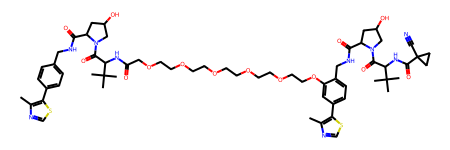

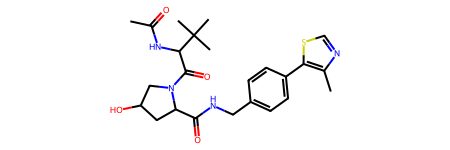

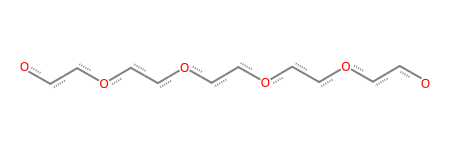

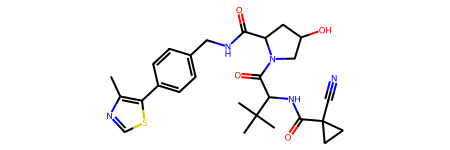

poi smiles:   CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
poi modified: [1*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c(:[4*])scn:[5*])cc1)C(C)(C)C
ERROR: E3 has multiple attachment points: [1*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C.[2*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
ERROR: E3 has multiple attachment points: [1*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C.[2*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
ERROR: E3 has multiple attachment points: [1*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C.[2*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
ERROR: E3 has multiple attachment points: [1*]c1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)C(NC(C)=O)C(C)(C)C.[2*]c1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)C(NC(C)=O)C(C)(C)C
ERROR: E3 has multiple attachment points: [1*]c1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)C(NC(C)=O)C(C)(C)C.[2*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1

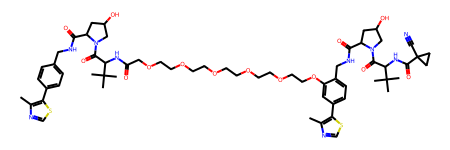

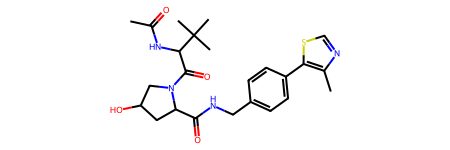

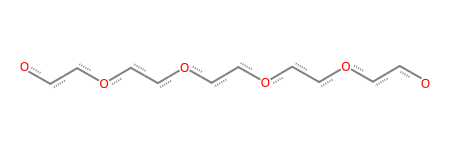

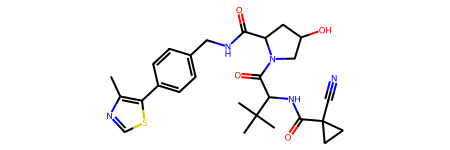

poi smiles:   CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
poi modified: [1*]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c(:[5*])scn:[4*])cc1)C(C)(C)C
ERROR: E3 has multiple attachment points: [1*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O.[2*]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O


Check for same atoms:   0%|          | 0/1789 [00:00<?, ?it/s]

len(searched_df_direction_same_atoms): 1751


In [42]:
from rdkit import RDLogger

# def get_substruct_with_dir(protac_mol, substruct_mol, linker_mol, attachment_id):
#     """Add directionality to the substructure. """
#     rgroups_linker_substruct_mol = Chem.ReplaceCore(
#         protac_mol,
#         substruct_mol,
#         protac_mol.GetSubstructMatch(substruct_mol),
#         labelByIndex=False,
#         replaceDummies=False,
#     )
#     # Remove the linker from the R-groups
#     substruct_mol_mod = Chem.ReplaceCore(
#         rgroups_linker_substruct_mol,
#         linker_mol,
#         rgroups_linker_substruct_mol.GetSubstructMatch(linker_mol),
#         labelByIndex=False,
#         replaceDummies=False,
#     )
#     # Add attachment points to the substructure
#     substruct_smiles_mod = Chem.MolToSmiles(substruct_mol_mod, canonical=True)
#     for i, substruct_smiles in enumerate(substruct_smiles_mod.split(".")):
#         substruct = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
#         if substruct.HasSubstructMatch(substruct_mol):
#             substruct_smiles_mod = substruct_smiles.replace(f'[{i+1}*]', f'[*:{attachment_id}]')
#             break
#     return substruct_smiles_mod

def split_molecule(molecule, poi_smiles, linker_smiles):
    # Create the POI and linker molecules
    poi = Chem.MolFromSmiles(poi_smiles)
    linker = Chem.MolFromSmiles(linker_smiles)

    # Get the molecule's SMARTS pattern
    molecule_smarts = Chem.MolToSmarts(molecule)

    # Create a modified SMARTS pattern to match the linker at the end
    modified_smarts = f"{molecule_smarts}>>{Chem.MolToSmarts(linker)}"

    # Create a molecule from the modified SMARTS pattern
    modified_molecule = Chem.MolFromSmarts(modified_smarts)

    # Find the match using SubstructMatch
    match = molecule.GetSubstructMatch(modified_molecule)

    # Extract the linker and POI
    if match:
        poi_start = molecule.GetSubstructMatch(poi)[0]
        linker_start = match[0]

        # Split the molecule into POI and linker
        split_poi = molecule.GetSubstructMatch(poi)
        split_linker = molecule.GetSubstructMatch(linker)

        return molecule.GetSubstructMatch(poi), molecule.GetSubstructMatch(linker)

    return None

def add_e3_poi_directionality(row):
    """ This way you get both E3 and POI with attachment points (which you can change to something else if you like). """
    e3_smiles_mod = float('nan')
    poi_smiles_mod = float('nan')
    row['E3 Binder SMILES with direction'] = e3_smiles_mod
    row['POI Ligand SMILES with direction'] = poi_smiles_mod
    protac_mol = get_mol(row['PROTAC SMILES'])
    poi_mol = get_mol(row['POI Ligand SMILES'])
    e3_mol = get_mol(row['E3 Binder SMILES'])
    linker_mol = Chem.MolFromSmarts(row['Linker SMILES'])

    # print(f'protac_mol.HasSubstructMatch(poi_mol): {protac_mol.HasSubstructMatch(poi_mol)}')
    # print(f'protac_mol.HasSubstructMatch(e3_mol): {protac_mol.HasSubstructMatch(e3_mol)}')
    # print(f'protac_mol.HasSubstructMatch(linker_mol): {protac_mol.HasSubstructMatch(linker_mol)}')

    # Remove the E3 and POI ligands from the PROTAC molecule to get the R-groups
    rgroups_linker_poi_mol = Chem.DeleteSubstructs(
        protac_mol,
        e3_mol,
        # protac_mol.GetSubstructMatch(e3_mol),
        # labelByIndex=False,
        # replaceDummies=False,
    )
    rgroups_linker_e3_mol = Chem.DeleteSubstructs(
        protac_mol,
        poi_mol,
        # protac_mol.GetSubstructMatch(poi_mol),
        # labelByIndex=False,
        # replaceDummies=False,
    )

    # rgroups_linker_poi_mol = Chem.MolFromSmiles(Chem.MolToSmiles(rgroups_linker_poi_mol).replace('[1*]', '')) # .replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]'))
    # rgroups_linker_e3_mol = Chem.MolFromSmiles(Chem.MolToSmiles(rgroups_linker_e3_mol).replace('[1*]', '')) # .replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]'))

    # if protac_mol.HasSubstructMatch(rgroups_linker_poi_mol):
    #     print(f'rgroups_linker_poi_mol IS in PROTAC')
    # else:
    #     print(f'rgroups_linker_poi_mol is NOT in PROTAC')
    #     display(rgroups_linker_poi_mol)
    # if protac_mol.HasSubstructMatch(rgroups_linker_e3_mol):
    #     print(f'rgroups_linker_e3_mol IS in PROTAC')
    # else:
    #     print(f'rgroups_linker_e3_mol is NOT in PROTAC')
    #     display(rgroups_linker_e3_mol)

    e3_mol_mod = Chem.ReplaceCore(protac_mol, rgroups_linker_poi_mol, labelByIndex=False, replaceDummies=False)
    poi_mol_mod = Chem.ReplaceCore(protac_mol, rgroups_linker_e3_mol, labelByIndex=False, replaceDummies=False)


    # Add attachment points to the E3 ligand
    e3_smiles_mod = Chem.MolToSmiles(e3_mol_mod, canonical=True)
    # Remove the linker from the R-groups instead
    if len(e3_smiles_mod.split(".")) > 2 or len(e3_smiles_mod.split("*")) > 2:
        e3_mol_mod = Chem.ReplaceCore(rgroups_linker_e3_mol, linker_mol, labelByIndex=False, replaceDummies=False)
        if len(e3_smiles_mod.split(".")) > 2:
            print(f'ERROR: E3 has multiple substructures: {e3_smiles_mod}')
        if len(e3_smiles_mod.split("*")) > 2:
            print(f'ERROR: E3 has multiple attachment points: {e3_smiles_mod}')
        
    for i, substruct_smiles in enumerate(e3_smiles_mod.split(".")):
        substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
        if substruct_mol.HasSubstructMatch(e3_mol):
            e3_smiles_mod = substruct_smiles.replace(f'[{i+1}*]', f'[*:{E3_ATTACHMENT_ID}]')
            break

    # Add attachment points to the POI ligand
    poi_smiles_mod = Chem.MolToSmiles(poi_mol_mod, canonical=True)
    # Remove the linker from the R-groups instead
    if len(e3_smiles_mod.split(".")) > 2 or len(e3_smiles_mod.split("*")) > 2:
        poi_mol_mod = Chem.ReplaceCore(rgroups_linker_poi_mol, linker_mol, labelByIndex=False, replaceDummies=False)
        if len(poi_smiles_mod.split(".")) > 2:
            print(f'ERROR: POI has multiple substructures: {poi_smiles_mod}')
        if len(poi_smiles_mod.split("*")) > 2:
            print(f'ERROR: POI has multiple attachment points: {poi_smiles_mod}')

    for i, substruct_smiles in enumerate(poi_smiles_mod.split(".")):
        substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
        if not substruct_mol:
            poi_smiles_mod = float('nan')
            display(protac_mol)
            display(poi_mol)
            display(linker_mol)
            display(e3_mol)
            print(f'poi smiles:   {row["POI Ligand SMILES"]}')
            print(f'poi modified: {substruct_smiles}')
            print('=' * 80)
        else:
            if substruct_mol.HasSubstructMatch(poi_mol):
                poi_smiles_mod = substruct_smiles.replace(f'[{i+1}*]', f'[*:{POI_ATTACHMENT_ID}]')
                break

    # Set the output fields
    row['E3 Binder SMILES with direction'] = e3_smiles_mod
    row['POI Ligand SMILES with direction'] = poi_smiles_mod

    # # Check if there are more than one '.' in e3_smiles_mod
    # if len(e3_smiles_mod.split('.')) > 1 or len(e3_smiles_mod.split('*')) > 2:
    #     print('e3_mol:')
    #     display(e3_mol)
    #     print('e3_smiles_mod:', e3_smiles_mod)
    #     print('e3_mol_mod:')
    #     display(e3_mol_mod)
    #     print('-' * 80)
    # if len(poi_smiles_mod.split('.')) > 1 or len(poi_smiles_mod.split('*')) > 2:
    #     print('poi_mol:')
    #     display(poi_mol)
    #     print('poi_smiles_mod:', poi_smiles_mod)
    #     print('poi_mol_mod:')
    #     display(poi_mol_mod)
    #     print('-' * 80)


    # linker_mol = Chem.MolFromSmarts(row['Linker SMILES with direction'])
    # row['E3 Binder SMILES with direction'] = get_substruct_with_dir(protac_mol, e3_mol, linker_mol, E3_ATTACHMENT_ID)
    # row['POI Ligand SMILES with direction'] = get_substruct_with_dir(protac_mol, poi_mol, linker_mol, POI_ATTACHMENT_ID)

    return row


# Disable the RDKit warnings that pop up when RDKit fails to create molecules
RDLogger.DisableLog("rdApp.*")

tqdm.pandas(desc="Get E3 and POI directionality", postfix=None)
searched_df_e3poi_direction = searched_df.progress_apply(add_e3_poi_directionality, axis=1)
searched_df_e3poi_direction = searched_df_e3poi_direction.dropna(subset=dir_cols)

tqdm.pandas(desc="Check for same atoms", postfix=None)
same_atoms = searched_df_e3poi_direction.progress_apply(lambda x: same_atom_counts_and_types(x['PROTAC SMILES'], '.'.join([x['E3 Binder SMILES with direction'], x['Linker SMILES with direction'], x['POI Ligand SMILES with direction']])), axis=1)
searched_df_direction_same_atoms = searched_df_e3poi_direction[same_atoms == True]
print('len(searched_df_direction_same_atoms):', len(searched_df_direction_same_atoms))

In [43]:
poi_idx = searched_df_direction_same_atoms['POI Ligand SMILES with direction'].str.contains(f"[*:{E3_ATTACHMENT_ID}]", regex=False)
e3_idx = searched_df_direction_same_atoms['E3 Binder SMILES with direction'].str.contains(f"[*:{POI_ATTACHMENT_ID}]", regex=False)
print('poi_idx:\n', poi_idx.all())
print('e3_idx:\n', e3_idx.all())

poi_idx = searched_df_direction_same_atoms['POI Ligand SMILES with direction'].str.contains(f"[*:{POI_ATTACHMENT_ID}]", regex=False)
e3_idx = searched_df_direction_same_atoms['E3 Binder SMILES with direction'].str.contains(f"[*:{E3_ATTACHMENT_ID}]", regex=False)
print('poi_idx:\n', poi_idx.all())
print('e3_idx:\n', e3_idx.all())

print('POI:')
print(searched_df_direction_same_atoms['POI Ligand SMILES with direction'])
print('E3:')
print(searched_df_direction_same_atoms['E3 Binder SMILES with direction'])
print('-' * 80)
tmp = searched_df_direction_same_atoms[~(poi_idx & e3_idx)]
searched_df_direction_same_atoms = searched_df_direction_same_atoms[poi_idx & e3_idx]
tmp

poi_idx:
 False
e3_idx:
 False
poi_idx:
 False
e3_idx:
 True
POI:
0                           [*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
1                           [*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
2                           [*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
3                           [*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
4                           [*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1
                                                       ...                                                 
1784                                            [*:1]CNC(=O)c1ccc(C)c(-n2c(C)cc(OCc3ccc(F)cc3F)c(Br)c2=O)c1
1785                                            [*:1]CNC(=O)c1ccc(C)c(-n2c(C)cc(OCc3ccc(F)cc3F)c(Br)c2=O)c1
1786                                                      [*:1]NC(=O)C

C:\Users\ste\AppData\Local\Temp\ipykernel_17484\204075263.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  searched_df_direction_same_atoms[~(poi_idx & e3_idx)]


,Compound ID,Uniprot,Target,E3 ligase,PDB,Name,PROTAC SMILES,DC50 (nM),Dmax (%),Assay (DC50/Dmax),Percent degradation (%),Assay (Percent degradation),"IC50 (nM, Protac to Target)","Assay (Protac to Target, IC50)","EC50 (nM, Protac to Target)","Assay (Protac to Target, EC50)","Kd (nM, Protac to Target)","Assay (Protac to Target, Kd)","Ki (nM, Protac to Target)","Assay (Protac to Target, Ki)","delta G (kcal/mol, Protac to Target)","delta H (kcal/mol, Protac to Target)","-T*delta S (kcal/mol, Protac to Target)","Assay (Protac to Target, G/H/-TS)","kon (1/Ms, Protac to Target)","koff (1/s, Protac to Target)","t1/2 (s, Protac to Target)","Assay (Protac to Target, kon/koff/t1/2)","IC50 (nM, Protac to E3)","Assay (Protac to E3, IC50)","EC50 (nM, Protac to E3)","Assay (Protac to E3, EC50)","Kd (nM, Protac to E3)","Assay (Protac to E3, Kd)","Ki (nM, Protac to E3)","Assay (Protac to E3, Ki)","delta G (kcal/mol, Protac to E3)","delta H (kcal/mol, Protac to E3)","-T*delta S (kcal/mol, Protac to E3)","Assay (Protac to E3, G/H/-TS)","kon (1/Ms, Protac to E3)","koff (1/s, Protac to E3)","t1/2 (s, Protac to E3)","Assay (Protac to E3, kon/koff/t1/2)","IC50 (nM, Ternary complex)","Assay (Ternary complex, IC50)","EC50 (nM, Ternary complex)","Assay (Ternary complex, EC50)","Kd (nM, Ternary complex)","Assay (Ternary complex, Kd)","Ki (nM, Ternary complex)","Assay (Ternary complex, Ki)","delta G (kcal/mol, Ternary complex)","delta H (kcal/mol, Ternary complex)","-T*delta S (kcal/mol, Ternary complex)","Assay (Ternary complex, G/H/-TS)","kon (1/Ms, Ternary complex)","koff (1/s, Ternary complex)","t1/2 (s, Ternary complex)","Assay (Ternary complex, kon/koff/t1/2)","IC50 (nM, Cellular activities)","Assay (Cellular activities, IC50)","EC50 (nM, Cellular activities)","Assay (Cellular activities, EC50)","GI50 (nM, Cellular activities)","Assay (Cellular activities, GI50)","ED50 (nM, Cellular activities)","Assay (Cellular activities, ED50)","GR50 (nM, Cellular activities)","Assay (Cellular activities, GR50)","PAMPA Papp (nm/s, Permeability)","Assay (Permeability, PAMPA Papp)","Caco-2 A2B Papp (nm/s, Permeability)","Assay (Permeability, Caco-2 A2B Papp)","Caco-2 B2A Papp (nm/s, Permeability)","Assay (Permeability, Caco-2 B2A Papp)",Article DOI,Molecular Weight,Exact Mass,XLogP3,Heavy Atom Count,Ring Count,Hydrogen Bond Acceptor Count,Hydrogen Bond Donor Count,Rotatable Bond Count,Topological Polar Surface Area,Molecular Formula,InChI,InChI Key,Molecule,PROTAC FP,POI Ligand Compound ID,POI Ligand SMILES,poi_exact_match,e3_exact_match,E3 Binder Compound ID,E3 Binder SMILES,Linker SMILES with direction,Linker SMILES,E3 Binder SMILES with direction,POI Ligand SMILES with direction


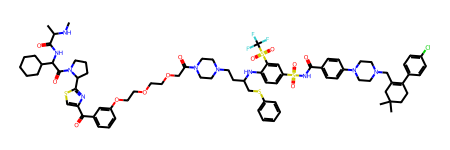

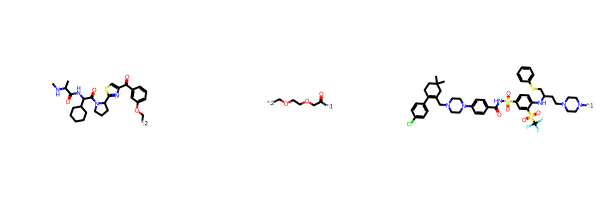

In [ ]:
row = searched_df_direction_same_atoms.iloc[-15]
display(Chem.MolFromSmiles(row['PROTAC SMILES']))
display(Draw.MolsToGridImage([Chem.MolFromSmiles(row['E3 Binder SMILES with direction']), Chem.MolFromSmiles(row['Linker SMILES with direction']), Chem.MolFromSmiles(row['POI Ligand SMILES with direction'])]))

## Save Entries to CSV

In [44]:
tmp = pd.concat([final_df, searched_df_direction_same_atoms], axis=0, ignore_index=True)[['PROTAC SMILES'] + dir_cols].drop_duplicates().dropna()
same_atoms = tmp.progress_apply(lambda x: same_atom_counts_and_types(x['PROTAC SMILES'], '.'.join([x['E3 Binder SMILES with direction'], x['Linker SMILES with direction'], x['POI Ligand SMILES with direction']])), axis=1)
print(len(tmp))
print(len(tmp[same_atoms == True]))
display(tmp)

Check for same atoms:   0%|          | 0/1840 [00:00<?, ?it/s]

1840
1840


,PROTAC SMILES,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction
0,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CCCCCCCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1
1,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CCCCCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1
2,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7sc...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CCCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1
3,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1
4,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1
...,...,...,...,...
2118,C=CC(=O)N1CCN(c2nc(NCCOCCOCCOCCc3cn(CCOCCOCCOCCC(=O)Nc4cccc5c4CN(C4CCC(=O)NC4=O)C5=O)nn3)nc3c(F)...,[*:2]Nc1cccc2c1CN(C1CCC(=O)NC1=O)C2=O,[*:2]C(=O)CCOCCOCCOCCn1cc(CCOCCOCCOCCN[*:1])nn1,[*:1]c1nc(N2CCN(C(=O)C=C)CC2)c2cc(Cl)c(-c3cc(O)cc4ccccc34)c(F)c2n1
2124,CCC(=C(c1ccc(O)cc1)c1ccc(OCCN(C)CCOCCOCCOCC(=O)NC(C(=O)N2CC(O)CC2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)...,[*:2]CC(=O)NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]OCCOCCOC[*:1],[*:1]CN(C)CCOc1ccc(C(=C(CC)c2ccccc2)c2ccc(O)cc2)cc1
2125,CCC(=C(c1ccc(O)cc1)c1ccc(OCCN(C)CCOCCOCCOCC(=O)NC(C(=O)N2CC(O)CC2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)C,[*:2]C(=O)COCCOCCOC[*:1],[*:1]CN(C)CCOc1ccc(C(=C(CC)c2ccccc2)c2ccc(O)cc2)cc1
2181,CNC(C)C(=O)NC1CCOC2CC(C)(C)C(C(=O)NC3CCCc4cc(OCCCOCCOCCOCCOCC(=O)N5CCN(CCC(CSc6ccccc6)Nc6ccc(S(=...,[*:2]c1ccc2c(c1)CCCC2NC(=O)C1N2C(=O)C(NC(=O)C(C)NC)CCOC2CC1(C)C,[*:2]OCCCOCCOCCOCCOCC(=O)[*:1],[*:1]N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)NC(=O)c3ccc(N4CCN(CC5=C(c6ccc(Cl)cc6)CCC(C)(C)C5)CC4)c...


In [45]:
final_df = tmp
final_df.to_csv(os.path.join(data_dir, 'processed', 'final_with_directionality.csv'), index=False, encoding='utf8')

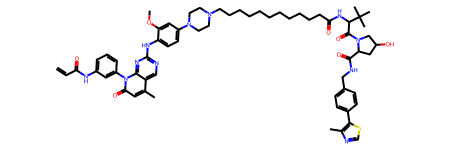

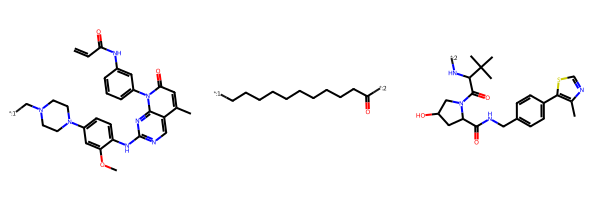

--------------------------------------------------------------------------------


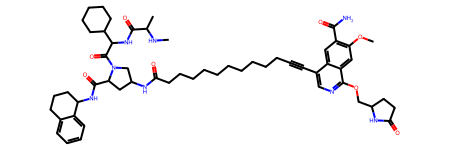

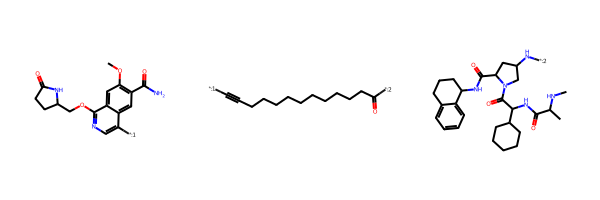

--------------------------------------------------------------------------------


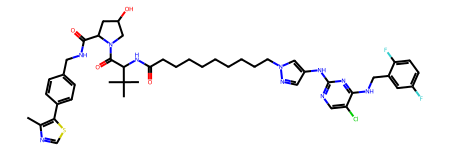

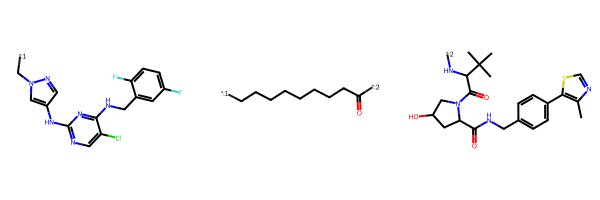

--------------------------------------------------------------------------------


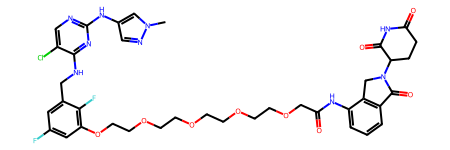

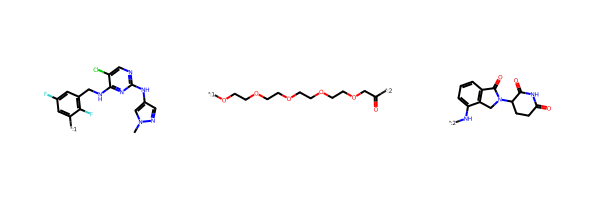

--------------------------------------------------------------------------------


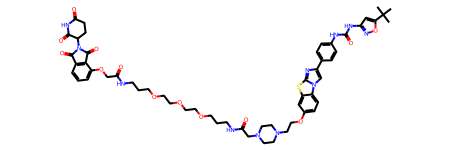

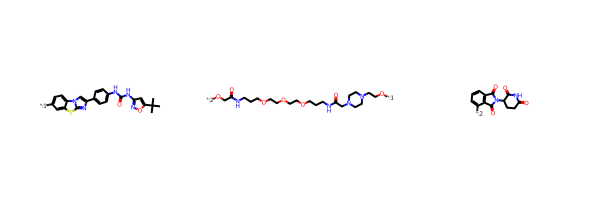

--------------------------------------------------------------------------------


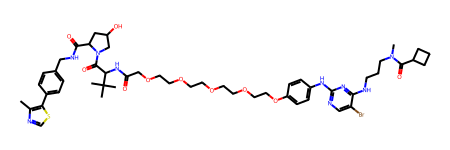

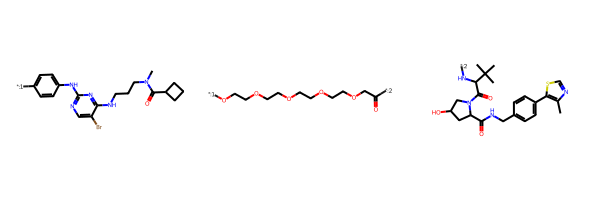

--------------------------------------------------------------------------------


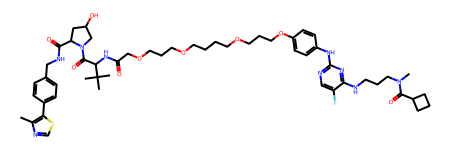

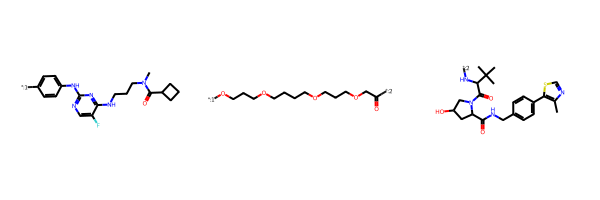

--------------------------------------------------------------------------------


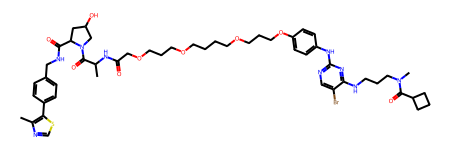

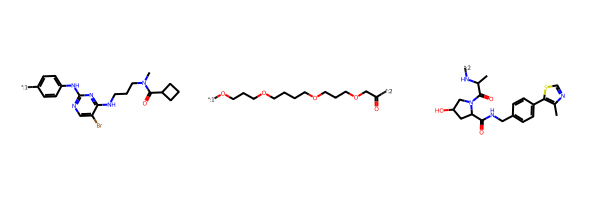

--------------------------------------------------------------------------------


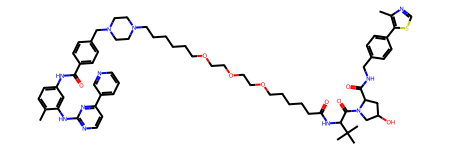

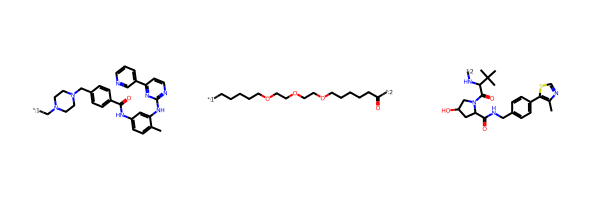

--------------------------------------------------------------------------------


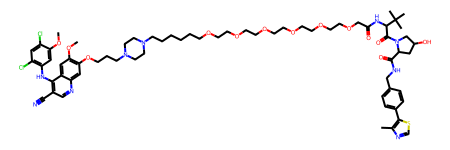

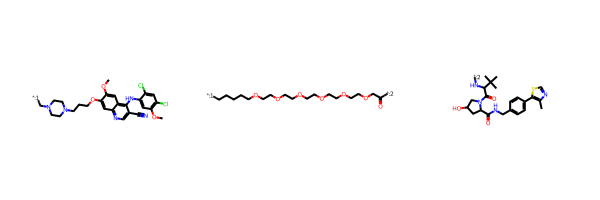

--------------------------------------------------------------------------------


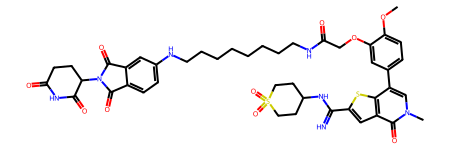

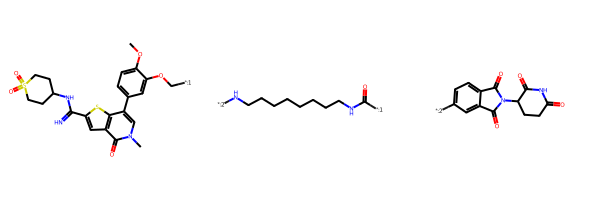

--------------------------------------------------------------------------------


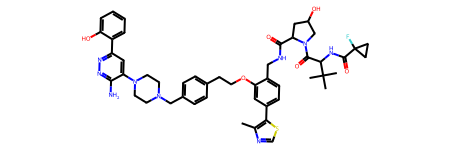

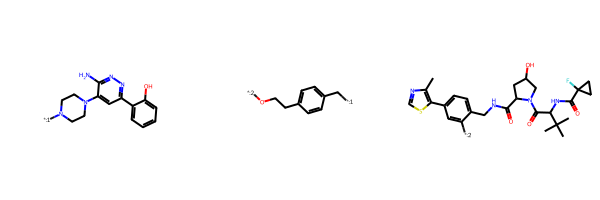

--------------------------------------------------------------------------------


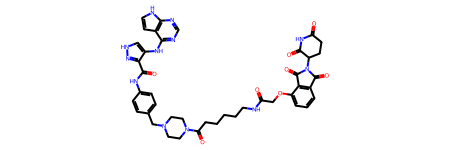

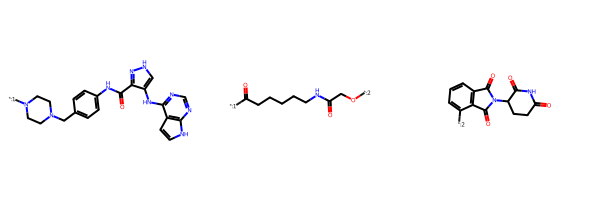

--------------------------------------------------------------------------------


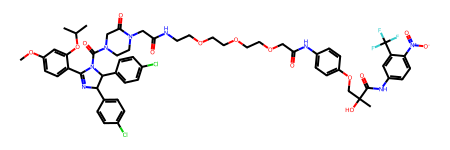

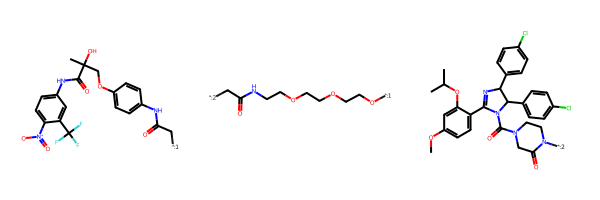

--------------------------------------------------------------------------------


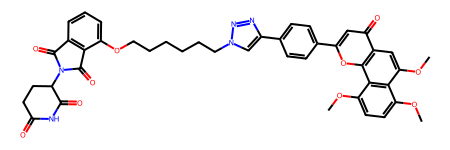

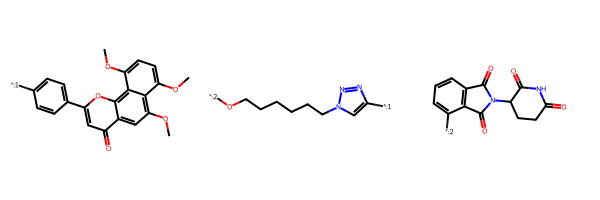

--------------------------------------------------------------------------------


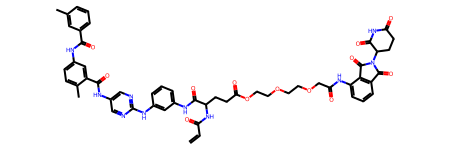

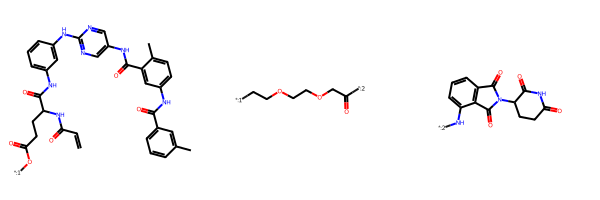

--------------------------------------------------------------------------------


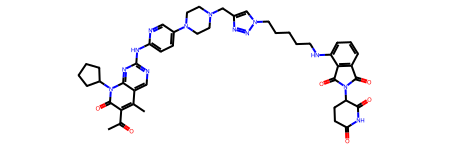

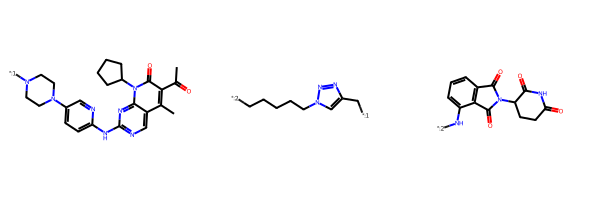

--------------------------------------------------------------------------------


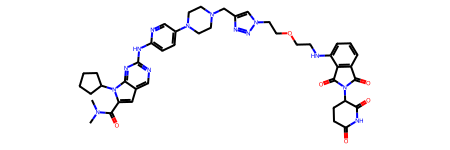

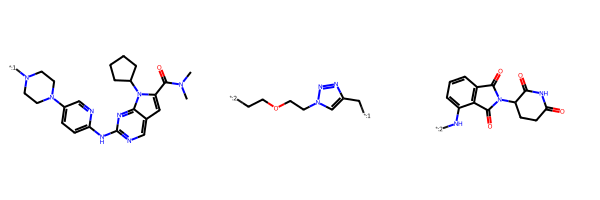

--------------------------------------------------------------------------------


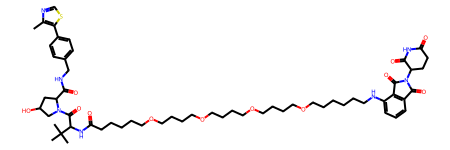

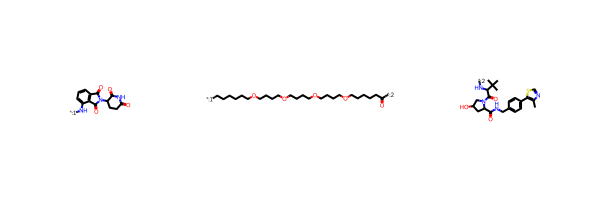

--------------------------------------------------------------------------------


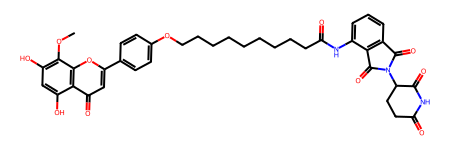

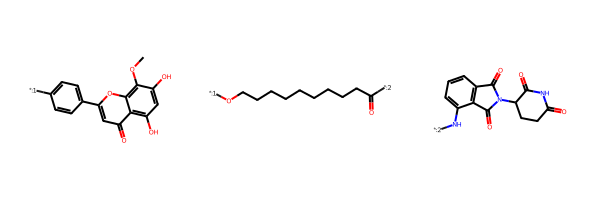

--------------------------------------------------------------------------------


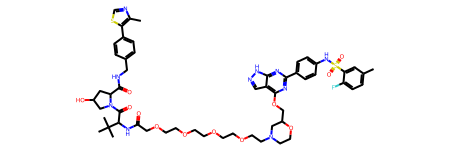

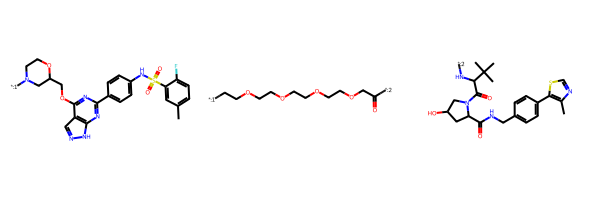

--------------------------------------------------------------------------------


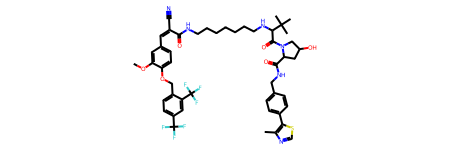

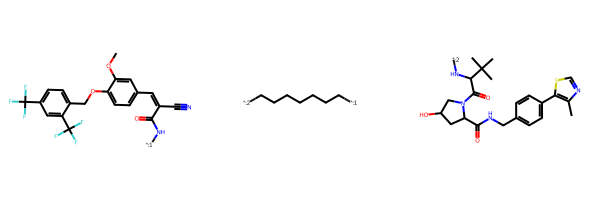

--------------------------------------------------------------------------------


In [46]:
# Display the final PROTACs and their substructures with directionality
for i in range(0, len(final_df), 10):
    row = final_df.iloc[i]
    display(Chem.MolFromSmiles(row['PROTAC SMILES']))
    display(Draw.MolsToGridImage([Chem.MolFromSmiles(row['POI Ligand SMILES with direction']), Chem.MolFromSmiles(row['Linker SMILES with direction']), Chem.MolFromSmiles(row['E3 Binder SMILES with direction'])]))
    print('-' * 80)
    if i > 200:
        break

## Cluster the Data

In order to check that the substructures are assigned correctly, we cluster the data using UMAP and apply it to their Morgan fingerprints.

In particular, we want to visually prove that, for example, linkers labeled as such cluster together.

In [47]:
import umap
from sklearn.preprocessing import StandardScaler

# fpgen = AllChem.GetRDKitFPGenerator()
fpgen = AllChem.GetMorganGenerator()

# For each column in final_df, get its fingerprint and then get the UMAP embedding
# of the fingerprints
for c in ['PROTAC SMILES', 'E3 Binder SMILES with direction', 'Linker SMILES with direction', 'POI Ligand SMILES with direction']:
    tqdm.pandas(desc=f"Getting FP for {c}", postfix=None)
    final_df[f'{c} FP'] = final_df[c].progress_apply(lambda x: fpgen.GetFingerprint(get_mol(x)))

c:\Users\ste\Anaconda2\envs\env-thesis\Lib\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
c:\Users\ste\Anaconda2\envs\env-thesis\Lib\site-packages\umap\distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
c:\Users\ste\Anaconda2\envs\env-thesis\Lib\site-packages\umap\distances.py:1086: Num

Getting FP for PROTAC SMILES:   0%|          | 0/1840 [00:00<?, ?it/s]

Getting FP for E3 Binder SMILES with direction:   0%|          | 0/1840 [00:00<?, ?it/s]

Getting FP for Linker SMILES with direction:   0%|          | 0/1840 [00:00<?, ?it/s]

Getting FP for POI Ligand SMILES with direction:   0%|          | 0/1840 [00:00<?, ?it/s]

In [52]:
# Normalize the fingerprints via a StandardScaler
umap_embeddings = {
    'UMAP 1': [],
    'UMAP 2': [],
    'Substructure:': [],
}
umap_labels = {}
for c in tqdm(['PROTAC SMILES FP', 'E3 Binder SMILES with direction FP', 'Linker SMILES with direction FP', 'POI Ligand SMILES with direction FP']):
    scaler = StandardScaler()
    umap_reducer = umap.UMAP(
        n_neighbors=20, # Good value: 50
        min_dist=0.5, # Good value: 0.5
        # spread=1.0, # Good value: (not set, default)
        metric='euclidean',
        random_state=42,
        unique=True,
        # n_epochs=100,
        init='spectral', # Default: 'spectral'
        verbose=False,
    )
    data = scaler.fit_transform(final_df[c].tolist())
    data = umap_reducer.fit_transform(data)
    # Get the UMAP embedding of the fingerprints
    umap_embeddings['UMAP 1'] += data[:, 0].tolist()
    umap_embeddings['UMAP 2'] += data[:, 1].tolist()
    umap_embeddings['Substructure:'] += [c.replace(' with direction', '').replace(' FP', '')] * len(data)
    # umap_labels[c] = [c.replace(' with direction FP', '')] * len(data)
    # umap_embeddings[c] = umap_reducer.fit_transform(data)
tmp = pd.DataFrame(umap_embeddings).drop_duplicates()
tmp

  0%|          | 0/4 [00:00<?, ?it/s]

,UMAP 1,UMAP 2,Substructure:
0,2.396119,3.276771,PROTAC SMILES
3,2.322943,3.227730,PROTAC SMILES
4,2.603256,3.322324,PROTAC SMILES
5,1.586173,4.006008,PROTAC SMILES
6,1.472149,3.920365,PROTAC SMILES
...,...,...,...
7321,-1.596284,1.397357,POI Ligand SMILES
7326,-0.998934,0.231671,POI Ligand SMILES
7329,-1.334236,2.311390,POI Ligand SMILES
7356,-1.596147,1.652804,POI Ligand SMILES


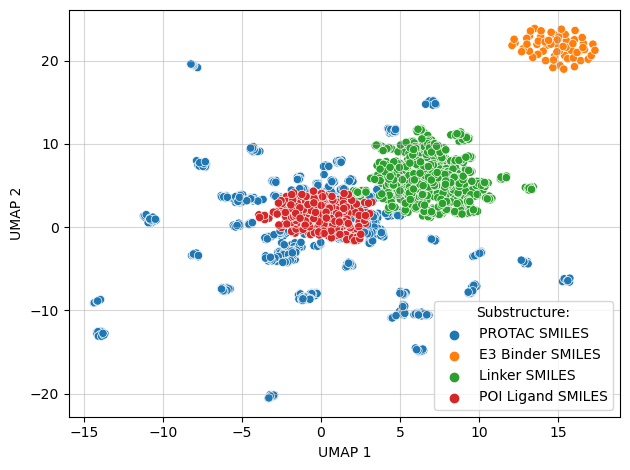

In [53]:
import seaborn as sns

ax = sns.scatterplot(data=tmp, x='UMAP 1', y='UMAP 2', hue='Substructure:', palette='tab10')
ax.grid(axis='both', alpha=0.5)
plt.tight_layout()
plt.show()

## Generate Text Dataset

In [54]:
try:
    display(final_df.head())
except:
    final_df = pd.read_csv(os.path.join(data_dir, 'processed', 'final_with_directionality.csv'))
    display(final_df.head())

,PROTAC SMILES,E3 Binder SMILES with direction,Linker SMILES with direction,POI Ligand SMILES with direction,PROTAC SMILES FP,E3 Binder SMILES with direction FP,Linker SMILES with direction FP,POI Ligand SMILES with direction FP
0,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CCCCCCCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CCCCCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7sc...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CCCCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CCCC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-c7scnc7C...,[*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:2]C(=O)CC[*:1],[*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [62]:
tmp = final_df.drop_duplicates(subset=['PROTAC SMILES'])
duplicates = final_df[~final_df.index.isin(tmp.index)]
print(len(final_df))
print(len(tmp))
print(len(duplicates))
print(len(tmp) + len(duplicates))
final_df = tmp

1840
1682
158
1840


In [64]:
len(final_df)

1682

### Get Substructures Order

In [65]:
def count_different_letters(string1, string2):
    count = 0
    for char1, char2 in zip(string1, string2):
        if char1 != char2:
            count += 1
    return count / (min(len(string1), len(string2)) + 1)

def get_order(protac_smiles, e3_smiles, linker_smiles, poi_smiles):
    """
    Returns the guessed order of the sub-molecules within a PROTAC SMILES.
    """
    half_protac = protac_smiles[:len(protac_smiles) // 2]
    e3_diff = count_different_letters(half_protac, e3_smiles)
    linker_diff = count_different_letters(half_protac, linker_smiles)
    poi_diff = count_different_letters(half_protac, poi_smiles)
    min_diff = min(e3_diff, linker_diff, poi_diff)
    if min_diff == e3_diff:
        return ['E3 Binder', 'Linker', 'POI Ligand']
    elif min_diff == linker_diff:
        # NOTE: This is a guess, as the linker is never the first sub-molecule.
        # return ['Linker', 'E3 Binder', 'POI ligand']
        return ['POI Ligand', 'E3 Binder', 'Linker']
    elif min_diff == poi_diff:
        return ['POI Ligand', 'E3 Binder', 'Linker']
    else:
        return ['POI Ligand', 'E3 Binder', 'Linker']

def print_stats(protac_smiles, e3_smiles, linker_smiles, poi_smiles):
    print('       ', protac_smiles)
    print('')
    print('POI:   ', poi_smiles)
    print('Linker:', linker_smiles)
    print('E3:    ', e3_smiles)
    print('')
    print(f'Order: {get_order(protac_smiles, e3_smiles, linker_smiles, poi_smiles)}')


cnt = Counter()
# Iterate over protac_pedia_df rows
for i, row in enumerate(final_df.iterrows()):
    # Get the row as a dict
    row_dict = row[1].to_dict()
    protac_smiles = row_dict['PROTAC SMILES']
    poi_smiles = row_dict['POI Ligand SMILES with direction'].replace('[*:1]', '').replace('[*:2]', '')
    linker_smiles = row_dict['Linker SMILES with direction'].replace('[*:1]', '').replace('[*:2]', '')
    e3_smiles = row_dict['E3 Binder SMILES with direction'].replace('[*:1]', '').replace('[*:2]', '')
    order = get_order(protac_smiles, e3_smiles, linker_smiles, poi_smiles)
    cnt[' - '.join(order)] += 1
    for order, count in cnt.items():
        if count < 1:
            print_stats(protac_smiles, e3_smiles, linker_smiles, poi_smiles)
            print('-' * 80)

for k, v in cnt.items():
    print(f'[{k}] count: {v}')

[E3 Binder - Linker - POI Ligand] count: 310
[POI Ligand - E3 Binder - Linker] count: 1372


### Set Text and Label Function

In [66]:
def set_text_and_labels(row, stype_in='SMILES', stype_out='SMILES', use_dir_cols=True):
    protac_smiles = row[f'PROTAC {stype_in}']
    stype_out = f'{stype_out} with direction' if use_dir_cols else stype_out
    poi_smiles = row[f'POI Ligand {stype_out}'].replace('[*:1]', '').replace('[*:2]', '')
    linker_smiles = row[f'Linker {stype_out}'].replace('[*:1]', '').replace('[*:2]', '')
    e3_smiles = row[f'E3 Binder {stype_out}'].replace('[*:1]', '').replace('[*:2]', '')
    order = get_order(protac_smiles, e3_smiles, linker_smiles, poi_smiles)
    row['text'] = protac_smiles
    row['labels'] = '.'.join([row[f'{s} SMILES with direction'] for s in order])
    return row

### Augmentation Functions

Function to shuffle the sub-structures order in the labels. For instance: PROTAC with POI-Linker-E3 associated to PROTAC with E3-Linker-POI.

In [67]:
from functools import partial
import random
from typing import Literal

def randomize_labels_order(row, stype: Literal['SMILES', 'SELFIES'] = 'SMILES', use_dir_cols=True):
    cols = [f'E3 Binder {stype}', f'Linker {stype}', f'POI Ligand {stype}']
    if use_dir_cols:
        cols = [f'{s} with direction' for s in cols]
    random.shuffle(cols)
    row['labels'] = '.'.join(row[cols])
    return row

row = set_text_and_labels(final_df.iloc[0], stype_in='SMILES', stype_out='SMILES')
randomize_labels_order(row, stype='SMILES')

PROTAC SMILES                          C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCC(=O)NC(C(=O)N6CC(O)CC6C(=O)NCc6ccc(-...
E3 Binder SMILES with direction                                                 [*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker SMILES with direction                                                                                     [*:2]C(=O)CCCCCCCCCC[*:1]
POI Ligand SMILES with direction                                [*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1
PROTAC SMILES FP                       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,...
E3 Binder SMILES with direction FP     [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
Linker SMILES with direction FP        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
POI Ligand SMILES with dire

Function for augmenting training data by randomizing SMILES strings (and their SELFIES):

In [68]:
import random

random.seed(42)

def randomize_smiles(smiles, num_smiles=5):
    mol = Chem.MolFromSmiles(smiles)
    try:
        rand_smiles = Chem.rdmolfiles.MolToRandomSmilesVect(
            mol,
            num_smiles,
            randomSeed=42,
            isomericSmiles=True,
            kekuleSmiles=False,
            allBondsExplicit=False,
            allHsExplicit=False,
        )
    except:
        return smiles
    return random.choice(rand_smiles)

def randomize_selfies(smiles, num_smiles=5):
    random_smiles = randomize_smiles(smiles, num_smiles)
    try:
        selfies = sf.encoder(random_smiles)
    except:
        selfies = sf.encoder(smiles)
    return selfies

def randomize_mol_str(mol_str, stype: Literal['SMILES', 'SELFIES'] = 'SMILES', num_smiles=5):
    if stype == 'SELFIES':
        return randomize_selfies(mol_str, num_smiles)
    elif stype == 'SMILES':
        return randomize_smiles(mol_str, num_smiles)
    else:
        raise ValueError(f'Unknown stype: {stype}. Allowed: "SELFIES", "SMILES".')

def randomize_labels_smiles(row, stype: Literal['SMILES', 'SELFIES'] = 'SMILES', use_dir_cols=True):
    cols = [f'E3 Binder {stype}', f'Linker {stype}', f'POI Ligand {stype}']
    if use_dir_cols:
        cols = [f'{s} with direction' for s in cols]
    for col in cols:
        row[col] = randomize_mol_str(row[col], stype, num_smiles=1)
    row['labels'] = '.'.join(row[cols])
    return row

def randomize_text_smiles(row, stype: Literal['SMILES', 'SELFIES'] = 'SMILES'):
    rand_mol = randomize_mol_str(row[f'PROTAC {stype}'], stype, num_smiles=1)
    row[f'PROTAC {stype}'] = rand_mol
    return row

row = set_text_and_labels(final_df.iloc[0], stype_in='SMILES', stype_out='SMILES')
print('randomize_text_smiles:\n', randomize_text_smiles(row, stype='SMILES'), '\n')
print('randomize_labels_smiles:\n', randomize_labels_smiles(row, stype='SMILES'), '\n')

randomize_text_smiles:
 PROTAC SMILES                          C(CCCCN1CCN(c2cc(OC)c(Nc3nc4c(cn3)c(cc(n4-c3cc(ccc3)NC(=O)C=C)=O)C)cc2)CC1)CCCCCCC(=O)NC(C(=O)N1...
E3 Binder SMILES with direction                                                 [*:2]NC(C(=O)N1CC(O)CC1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C
Linker SMILES with direction                                                                                     [*:2]C(=O)CCCCCCCCCC[*:1]
POI Ligand SMILES with direction                                [*:1]CN1CCN(c2ccc(Nc3ncc4c(C)cc(=O)n(-c5cccc(NC(=O)C=C)c5)c4n3)c(OC)c2)CC1
PROTAC SMILES FP                       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,...
E3 Binder SMILES with direction FP     [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
Linker SMILES with direction FP        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
POI

### Generate Different Datasets

Apply augmentations and save dataframes accordingly:

In [70]:
from sklearn.model_selection import GroupShuffleSplit
import random
from math import ceil

random.seed(42)

duplicates_tmp = duplicates.apply(lambda x: set_text_and_labels(x, stype_in='SMILES', stype_out='SMILES'), axis=1)

def save_df(df, phase, stype_in='SMILES', stype_out='SMILES', random_smiles_frac=0.5, random_order_frac=0.5, base_dir=data_dir):
    df_w_txt_n_labels = df.apply(lambda x: set_text_and_labels(x, stype_in=stype_in, stype_out=stype_out), axis=1)
    # Augment data accordingly
    if phase == 'train':
        original_len = len(df)
        df_w_augmentations = df_w_txt_n_labels.copy()
        df_w_augmentations = pd.concat([
            df_w_augmentations[['text', 'labels']],
            duplicates_tmp[['text', 'labels']],
        ], axis=0)
        if random_order_frac > 0:
            augmented = df_w_txt_n_labels.sample(frac=random_order_frac, random_state=42)
            augmented = augmented.apply(partial(randomize_labels_order, stype=stype_out), axis=1)
            df_w_augmentations = pd.concat([
                df_w_augmentations[['text', 'labels']],
                augmented[['text', 'labels']],
            ], axis=0)
        if random_smiles_frac > 0:
            augmented = df_w_txt_n_labels.sample(frac=random_smiles_frac, random_state=42)
            augmented = augmented.apply(partial(randomize_text_smiles, stype=stype_in), axis=1)
            augmented = augmented.apply(partial(randomize_labels_smiles, stype=stype_out), axis=1)
            df_w_augmentations = pd.concat([
                df_w_augmentations[['text', 'labels']],
                augmented[['text', 'labels']],
            ], axis=0)
        outfile = os.path.join(base_dir, f'train.csv')
        df_w_augmentations[['text', 'labels']].to_csv(outfile, index=False)
        print(f'Original vs. augmented train size: {original_len} / {len(df_w_augmentations)}')
    else:
        outfile = os.path.join(base_dir, f'val.csv')
        df_w_txt_n_labels[['text', 'labels']].to_csv(outfile, index=False)
        print(f'Val size: {len(df_w_txt_n_labels)}')


# Split train and validation sets:
X = final_df.drop(columns=['PROTAC SMILES'])
y = final_df['PROTAC SMILES']
groups = final_df['PROTAC SMILES']

for split_ratio in [0.8]:
    gss = GroupShuffleSplit(n_splits=1, train_size=split_ratio, random_state=42)
    train_idx, val_idx = next(gss.split(X, y, groups))

    train_df = final_df.iloc[train_idx]
    val_df = final_df.iloc[val_idx]
    
    for random_smiles_frac in [0, 0.5]:
        for random_order_frac in [0, 0.5]:
            print(f'split ratio: {split_ratio}')
            print(f'random_smiles_frac: {random_smiles_frac}')
            print(f'random_order_frac: {random_order_frac}')
            print('len(train_df):', len(train_df))
            print('len(val_df):', len(val_df))
            # print('train_df:', train_df.head())
            # print('val_df:', val_df.head())
            print('num conflicts:', len(train_df[train_df['PROTAC SMILES'].isin(val_df['PROTAC SMILES'])]))
            print(f'-' * 80)
            for df, phase in [(train_df, 'train'), (val_df, 'val')]:
                # Setup directory name
                split_ratio_str = f'{int(split_ratio * 100)}-{100 - int(split_ratio * 100)}-split'
                dir_name = f'protac_splitter_{split_ratio_str}'
                # dir_name = f'protac_splitter_{split_ratio_str}_smiles_in_smiles_out'
                augmented_id = ''
                if random_order_frac > 0:
                    dir_name += f'_shuffled-labels-order-{random_order_frac:.0%}'
                if random_smiles_frac > 0:
                    dir_name += f'_random-labels-smiles-{random_smiles_frac:.0%}'
                if not os.path.exists(os.path.join(data_dir, 'final', dir_name)):
                    os.makedirs(os.path.join(data_dir, 'final', dir_name))
                save_df(
                    df,
                    phase,
                    stype_in='SMILES',
                    stype_out='SMILES',
                    random_smiles_frac=random_smiles_frac,
                    random_order_frac=random_order_frac,
                    base_dir=os.path.join(data_dir, 'final', dir_name),
                )
                # TODO: The SELFIES are breaking when trying to convert randomized SMILES...
                # save_df(
                #     df,
                #     phase,
                #     stype_in='SMILES',
                #     stype_out='SELFIES',
                #     random_smiles_frac=random_smiles_frac,
                #     random_order_frac=random_order_frac,
                #     base_dir=os.path.join(data_dir, 'protac_splitter'),
                # )
                # save_df(
                #     df,
                #     phase,
                #     stype_in='SELFIES',
                #     stype_out='SELFIES',
                #     random_smiles_frac=random_smiles_frac,
                #     random_order_frac=random_order_frac,
                #     base_dir=os.path.join(data_dir, 'protac_splitter'),
                # )

split ratio: 0.8
random_smiles_frac: 0
random_order_frac: 0
len(train_df): 1345
len(val_df): 337
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train size: 1345 / 1503
Val size: 337
split ratio: 0.8
random_smiles_frac: 0
random_order_frac: 0.5
len(train_df): 1345
len(val_df): 337
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train size: 1345 / 2175
Val size: 337
split ratio: 0.8
random_smiles_frac: 0.5
random_order_frac: 0
len(train_df): 1345
len(val_df): 337
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train size: 1345 / 2175
Val size: 337
split ratio: 0.8
random_smiles_frac: 0.5
random_order_frac: 0.5
len(train_df): 1345
len(val_df): 337
num conflicts: 0
--------------------------------------------------------------------------------
Original vs. augmented train 

### Save to HuggingFace Hub

In [74]:
from huggingface_hub import notebook_login

notebook_login()

More information on `push_to_hub` can be found [here](https://huggingface.co/docs/datasets/main/en/package_reference/main_classes#datasets.DatasetDict.push_to_hub).

More information on loading from Pandas DataFrame can be found [here](https://huggingface.co/docs/datasets/v2.14.5/loading#pandas-dataframe).

In [89]:
from datasets import Dataset, DatasetDict

tqdm.pandas(desc="Get text and labels columns", postfix=None)
tmp = final_df.progress_apply(lambda x: set_text_and_labels(x, stype_in='SMILES', stype_out='SMILES'), axis=1)
dataset = Dataset.from_pandas(tmp[['text', 'labels']])
dataset = dataset.remove_columns(['__index_level_0__'])

datasets = DatasetDict({
    "train": dataset,
})
dataset_name = 'ailab-bio/PROTAC-Substructures'
config_name = 'raw'
datasets.push_to_hub(dataset_name, config_name, private=True)

Get text and labels columns:   0%|          | 0/1682 [00:00<?, ?it/s]

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

In [86]:
from datasets import load_dataset, disable_caching

disable_caching()

for f in os.listdir(os.fsencode(os.path.join(data_dir, 'final'))):
    ds_name = os.fsdecode(f)
    dataset = load_dataset(os.path.join(data_dir, 'final', ds_name))
    config_name = ds_name.replace('protac_splitter_', '')
    dataset.push_to_hub(dataset_name, config_name, private=True)
    # print(dataset)

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

Pushing dataset shards to the dataset hub:   0%|          | 0/1 [00:00<?, ?it/s]

## Using Pre-Trained Models to Generate New Data

## DEPRECATED: "Subtract" Substructures

In [ ]:
# def subtract_substructure(row, sbstruct_name_1, sbstruct_name_2, substruct_name_res):
#     protac_mol = get_mol(row['PROTAC SMILES'])
#     mol_1 = get_mol(row[sbstruct_name_1])
#     mol_2 = get_mol(row[sbstruct_name_2])
#     substruct_name_res = f'{substruct_name_res.replace("SMILES", "subtracted SMILES")}'
#     row[substruct_name_res] = float('nan')
#     if mol_1 is not None and mol_2 is not None:
#         try:
#             res = Chem.DeleteSubstructs(protac_mol, mol_1)
#             res = Chem.DeleteSubstructs(res, mol_2)
#             row[substruct_name_res] = Chem.MolToSmiles(res, canonical=True)
#         except:
#             pass
#     return row

# e3_linker_matching = tmp[(tmp['POI Ligand Matching'] == True) & (tmp['Linker Matching'] == True)]
# e3_linker_matching = e3_linker_matching.progress_apply(lambda x: subtract_substructure(x, 'POI Ligand SMILES', 'Linker SMILES', 'E3 Binder SMILES'), axis=1)

In [ ]:
# sub_names = ['POI Ligand SMILES', 'Linker SMILES', 'E3 Binder subtracted SMILES']
# e3_linker_matching = e3_linker_matching.progress_apply(lambda x: get_substruct_match(x, substruct_names=sub_names), axis=1)
# e3_linker_matching.head() #value_counts('POI Ligand Matching')

## DEPRECATED: Label Directionality

TODO: Why does the new linker get two molecules?

In [41]:
def add_linker_directionality(row):
    """Get linker with attachment points."""
    protac_mol = get_mol(row['PROTAC SMILES'])
    poi_mol = get_mol(row['POI Ligand SMILES'])
    row['Linker SMILES with direction'] = float('nan')
    if protac_mol.HasSubstructMatch(poi_mol):
        rgroups = Chem.ReplaceCore(protac_mol, poi_mol, labelByIndex=False)
        rgroups_smiles = Chem.MolToSmiles(rgroups, canonical=True)
        linker_e3_smiles_mod = rgroups_smiles.replace("[1*]", f"[*:1]")
        e3_mol = get_mol(row['E3 Binder SMILES'])
        linker_e3_mol = Chem.MolFromSmiles(linker_e3_smiles_mod, sanitize=False)
        if linker_e3_mol.HasSubstructMatch(e3_mol):
            rgroups = Chem.ReplaceCore(linker_e3_mol, e3_mol, labelByIndex=False)
            rgroups_smiles = Chem.MolToSmiles(rgroups, canonical=True)
            linker_smiles_mod = rgroups_smiles.replace("[1*]", f"[*:2]")
            row['Linker SMILES with direction'] = linker_smiles_mod
    return row

tmp = all_matching.progress_apply(add_linker_directionality, axis=1)
tmp = tmp.dropna(subset='Linker SMILES with direction')
print(len(tmp))

  0%|          | 0/635 [00:00<?, ?it/s]

635


Check if multiple molecules are generated in the Linker:

In [42]:
len(tmp[tmp['Linker SMILES with direction'].str.contains('.') == True])

0

In [44]:
def add_e3_poi_directionality(row):
    """ This way you get both E3 and POI with attachment points (which you can change to something else if you like). """
    protac_mol = get_mol(row['PROTAC SMILES'])
    poi_mol = get_mol(row['POI Ligand SMILES'])
    linker_mol = get_mol(row['Linker SMILES'])
    e3_mol = get_mol(row['E3 Binder SMILES'])
    e3_smiles_mod = float('nan')
    poi_smiles_mod = float('nan')
    if protac_mol.HasSubstructMatch(linker_mol):
        rgroups = Chem.ReplaceCore(protac_mol, linker_mol, labelByIndex=False)
        rgroups_smiles = Chem.MolToSmiles(rgroups).split('.')
        for i, substruct_smiles in enumerate(rgroups_smiles):
            substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=False)
            if substruct_mol.HasSubstructMatch(poi_mol):
                poi_smiles_mod = substruct_smiles.replace(f"[{i+1}*]", "[*:1]")
            elif substruct_mol.HasSubstructMatch(e3_mol):
                e3_smiles_mod = substruct_smiles.replace(f"[{i+1}*]", "[*:2]")
    row['E3 Binder SMILES with direction'] = e3_smiles_mod
    row['POI Ligand SMILES with direction'] = poi_smiles_mod
    return row

tmp = all_matching.progress_apply(add_e3_poi_directionality, axis=1)
tmp = tmp.dropna(subset=['E3 Binder SMILES with direction', 'POI Ligand SMILES with direction'])
print(len(tmp))

  0%|          | 0/635 [00:00<?, ?it/s]

567


In [55]:
print(len(tmp[tmp['POI Ligand SMILES with direction'].str.contains('.') == True]))
print(tmp['E3 Binder SMILES with direction'].str.contains('.').sum())

567
567


In [54]:
tmp['E3 Binder SMILES with direction'].iloc[0]

'[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O'

## Mark and Label Directionality

In [225]:
matching_substructs_dict = {
    'POI Ligand SMILES': {},
    'Linker SMILES': {},
    'E3 Binder SMILES': {}
}
cnt = Counter()
all_matching_df = []
non_matching_df = []
# Iterate over protac_pedia_df rows
for i, row in tqdm(enumerate(protac_pedia_df.iterrows()), total=len(protac_pedia_df)):
    # Get the row as a dict
    row_dict = row[1].to_dict()
    protac_mol = get_mol(row_dict['PROTAC SMILES'])
    all_matching = True
    for substruct_name in matching_substructs_dict.keys():
        substruct_mol = get_mol(row_dict[substruct_name])
        if substruct_mol is not None and protac_mol.HasSubstructMatch(substruct_mol):
            cnt[f'matching {substruct_name}'] += 1
            matching_substructs_dict[substruct_name][Chem.MolToSmiles(substruct_mol)] = substruct_mol
        elif substruct_name is not None:
            all_matching = False
            cnt[f'non-matching {substruct_name}'] += 1
            # tanimoto = get_tanimoto(protac_smiles, substruct_smiles)
            # print(f'non-matching {substruct_name}. Tanimoto: {tanimoto}')
            # if tanimoto < 0.5:
            #     display(protac_mol)
            #     display(substruct_mol)
        else:
            cnt[f'none {substruct_name}'] += 1
            all_matching = False
    if not all_matching:
        non_matching_df.append(i)
        # print('-' * 80)
    else:
        all_matching_df.append(i)
        cnt[f'all matching'] += 1
for k, v in cnt.items():
    print(f'{k}: {v}')
all_matching_df = protac_pedia_df.iloc[all_matching_df]
non_matching_df = protac_pedia_df.iloc[non_matching_df]
print('len all_matching_df:', len(all_matching_df))
print('len non_matching_df:', len(non_matching_df))

  0%|          | 0/1167 [00:00<?, ?it/s]

non-matching POI Ligand SMILES: 433
matching Linker SMILES: 1167
matching E3 Binder SMILES: 1024
matching POI Ligand SMILES: 734
all matching: 635
non-matching E3 Binder SMILES: 143
len all_matching_df: 635
len non_matching_df: 532


In [226]:
for k, v in matching_substructs_dict.items():
    print(k, len(v))

POI Ligand SMILES 117
Linker SMILES 641
E3 Binder SMILES 48


In [227]:
non_matching_df.head()

,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...


Let's check if the labeled Linker corresponds to the PROTAC molecule with both the labeled E3 and labeled POI removed:

In [264]:
def view_difference(mol1, mol2):
    mcs = rdFMCS.FindMCS([mol1,mol2])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    match1 = mol1.GetSubstructMatch(mcs_mol)
    target_atm1 = []
    for atom in mol1.GetAtoms():
        if atom.GetIdx() not in match1:
            target_atm1.append(atom.GetIdx())
    match2 = mol2.GetSubstructMatch(mcs_mol)
    target_atm2 = []
    for atom in mol2.GetAtoms():
        if atom.GetIdx() not in match2:
            target_atm2.append(atom.GetIdx())
    return Draw.MolsToGridImage([mol1, mol2], highlightAtomLists=[target_atm1, target_atm2])

# Define a function to check if the Linker corresponds to removing E3 Binder and POI Ligand
def check_linker_correspondence(row):
    protac_smiles = row['PROTAC SMILES']
    e3_binder_smiles = row['E3 Binder SMILES']
    poi_ligand_smiles = row['POI Ligand SMILES']
    linker_smiles = row['Linker SMILES']
    # Create RDKit Mol objects from SMILES
    protac_mol = Chem.MolFromSmiles(protac_smiles)
    e3_binder_mol = Chem.MolFromSmiles(e3_binder_smiles)
    poi_ligand_mol = Chem.MolFromSmiles(poi_ligand_smiles)
    # Remove E3 Binder and POI Ligand from PROTAC
    protac_without_e3_poi = AllChem.DeleteSubstructs(protac_mol, e3_binder_mol)
    protac_without_e3_poi = AllChem.DeleteSubstructs(protac_without_e3_poi, poi_ligand_mol)
    # Convert the result back to SMILES
    result_smiles = Chem.MolToSmiles(protac_without_e3_poi)
    # Check if the Linker corresponds to the result or is a combination of the result
    return result_smiles == linker_smiles or (linker_smiles in result_smiles)

# Add a new column to your DataFrame to store the check results
non_matching_linkers = all_matching_df.progress_apply(check_linker_correspondence, axis=1)
non_matching_linkers = non_matching_linkers[non_matching_linkers == False]
# Display difference between labeled Linker and the Linker that corresponds to removing E3 Binder and POI Ligand
for i in non_matching_linkers.index:
    row = all_matching_df.loc[i]
    protac_smiles = row['PROTAC SMILES']
    e3_binder_smiles = row['E3 Binder SMILES']
    poi_ligand_smiles = row['POI Ligand SMILES']
    linker_smiles = row['Linker SMILES']
    # Create RDKit Mol objects from SMILES
    protac_mol = Chem.MolFromSmiles(protac_smiles)
    e3_binder_mol = Chem.MolFromSmiles(e3_binder_smiles)
    poi_ligand_mol = Chem.MolFromSmiles(poi_ligand_smiles)
    linker_mol = Chem.MolFromSmiles(linker_smiles)
    # Remove E3 Binder and POI Ligand from PROTAC
    protac_without_e3_poi = AllChem.DeleteSubstructs(protac_mol, e3_binder_mol)
    protac_without_e3_poi = AllChem.DeleteSubstructs(protac_without_e3_poi, poi_ligand_mol)
    # Display difference between labeled Linker and the Linker that corresponds to removing E3 Binder and POI Ligand
    display(view_difference(linker_mol, protac_without_e3_poi))

  0%|          | 0/635 [00:00<?, ?it/s]

In [267]:
non_matching_linkers = non_matching_df.progress_apply(check_linker_correspondence, axis=1)
non_matching_linkers = non_matching_df[non_matching_linkers == False]
non_matching_linkers

  0%|          | 0/532 [00:00<?, ?it/s]

,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...
...,...,...,...,...
1191,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)NCCNC(=O)CCCC(=O)Nc3ccc4c(c3)C(=O)N(C3CCC(=O)NC3=O)C...,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,NCCNC(=O)CCCC=O,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)O)cc2Cl)cccc1-c1ccc2c(c1)OCCO2
1194,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)N3CCN(C(=O)CCCC(=O)Nc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C...,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,O=CCCCC(=O)N1CCNCC1,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)O)cc2Cl)cccc1-c1ccc2c(c1)OCCO2
1195,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)N3CCN(C(=O)CCC(=O)Nc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5...,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,O=CCCC(=O)N1CCNCC1,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)O)cc2Cl)cccc1-c1ccc2c(c1)OCCO2
1201,O=C1CCC(N2C(=O)c3cccc(NCCCCCCCC(=O)Nc4ccc(N5Cc6ccc(O)cc6OC5=O)cc4)c3C2=O)C(=O)N1,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CCCCCCCC(N)=O,COc1ccc(N2Cc3ccc(O)cc3OC2=O)cc1OC


In [269]:
# Define a function to check if the E3 Binder corresponds to the PROTAC
def check_e3_binder_correspondence(row):
    protac_smiles = row['PROTAC SMILES']
    e3_binder_smarts = row['E3 Binder SMILES']
    # Create RDKit Mol object from PROTAC SMILES
    protac_mol = Chem.MolFromSmiles(protac_smiles)
    # Convert E3 Binder SMARTS to Mol object
    e3_binder_mol = Chem.MolFromSmarts(e3_binder_smarts)
    if e3_binder_mol is None:
        raise ValueError("Invalid SMARTS notation for E3 Binder")
    # Check if E3 Binder is a substructure of PROTAC with flexibility
    e3_match = protac_mol.HasSubstructMatch(e3_binder_mol)
    return e3_match

non_matching_e3 = all_matching_df.progress_apply(check_e3_binder_correspondence, axis=1)
non_matching_e3 = all_matching_df[non_matching_e3 == False]
display(non_matching_e3)

non_matching_e3 = non_matching_df.progress_apply(check_e3_binder_correspondence, axis=1)
non_matching_e3 = non_matching_df[non_matching_e3 == False]
display(non_matching_e3)

  0%|          | 0/635 [00:00<?, ?it/s]

,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES


  0%|          | 0/532 [00:00<?, ?it/s]

,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES
56,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCCCCCNC(=O)[C@H](CC(C)C)NC(=O)[C@@H](...,CC(C)C[C@H](NC(=O)[C@@H](O)[C@H](N)Cc1ccccc1)C(=O)O,CCCCCCCCCCCN,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1
57,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCCCCCNC(=O)c6ccc(NC(=O)[C@@H]7N[C@@H]...,COc1cc(C(=O)O)ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@](C#N)(c2ccc(Cl)cc2F)[C@H]1c1cccc(Cl)c1F,CCCCCCCCCCCN,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1
58,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(CCCCCCCCCCCCNC(=O)c6ccc(NC(=O)[C@@H]7N[C@@H](CC(...,COc1cc(C(=O)O)ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@](C#N)(c2ccc(Cl)cc2F)[C@H]1c1cccc(Cl)c1F,CCCCCCCCCCCN,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1
61,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCCCNC(=O)c6ccc(NC(=O)[C@@H]7N[C@@H](C...,COc1cc(C(=O)O)ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@](C#N)(c2ccc(Cl)cc2F)[C@H]1c1cccc(Cl)c1F,CCCCCCCCCN,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1
62,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C(=O)CCCCCCCNC(=O)c6ccc(NC(=O)[C@@H]7N[C@@H](CC(...,COc1cc(C(=O)O)ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@](C#N)(c2ccc(Cl)cc2F)[C@H]1c1cccc(Cl)c1F,CCCCCCCN,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CCN(C)CC5)cc4OC)nc32)c1
...,...,...,...,...
1154,Cc1ccc(C(=O)NCCCCc2cn(CCCC(=O)NCCCCCCc3cccc4c3CN(C3CCC(=O)NC3=O)C4=O)nn2)cc1-n1c(C)cc(OCc2ccc(F)...,Nc1cccc2c1CN(C1CCC(=O)NC1=O)C2=O,CCCCCCNC(=O)CCCn1cc(CCC)nn1,CNC(=O)c1ccc(C)c(-n2c(C)cc(OCc3ccc(F)cc3F)c(Br)c2=O)c1
1155,Cc1ccc(C(=O)NCCCCc2cn(CCCC(=O)NCCCCCc3cccc4c3CN(C3CCC(=O)NC3=O)C4=O)nn2)cc1-n1c(C)cc(OCc2ccc(F)c...,Nc1cccc2c1CN(C1CCC(=O)NC1=O)C2=O,CCCCCNC(=O)CCCn1cc(CCC)nn1,CNC(=O)c1ccc(C)c(-n2c(C)cc(OCc3ccc(F)cc3F)c(Br)c2=O)c1
1180,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)NCCNC(=O)CCCC(=O)Nc3ccc4c(c3)C(=O)N(C3CCC(=O)NC3=O)C...,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,NCCNC(=O)CCCC=O,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)O)cc2Cl)cccc1-c1ccccc1
1191,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)NCCNC(=O)CCCC(=O)Nc3ccc4c(c3)C(=O)N(C3CCC(=O)NC3=O)C...,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,NCCNC(=O)CCCC=O,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)O)cc2Cl)cccc1-c1ccc2c(c1)OCCO2


In [491]:
e3_dict = protac_db_e3_df
poi_dict = protac_db_poi_df
linker_dict = protac_db_linker_df

tmp = protac_pedia_e3_df[['Molecule', 'E3 Binder SMILES']]
tmp['Compound ID'] = float('nan')
e3_dict = pd.concat([protac_db_e3_df, tmp], axis=0, ignore_index=True)
tmp = protac_pedia_poi_df[['Molecule', 'POI Ligand SMILES']]
tmp['Compound ID'] = float('nan')
poi_dict = pd.concat([protac_db_poi_df, tmp], axis=0, ignore_index=True)
tmp = protac_pedia_linker_df[['Molecule', 'Linker SMILES']]
tmp['Compound ID'] = float('nan')
linker_dict = pd.concat([protac_db_linker_df, tmp], axis=0, ignore_index=True)
e3_dict = e3_dict.drop_duplicates(subset=['E3 Binder SMILES'])
poi_dict = poi_dict.drop_duplicates(subset=['POI Ligand SMILES'])
linker_dict = linker_dict.drop_duplicates(subset=['Linker SMILES'])

C:\Users\ste\AppData\Local\Temp\ipykernel_4040\2583572171.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['Compound ID'] = float('nan')
C:\Users\ste\AppData\Local\Temp\ipykernel_4040\2583572171.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['Compound ID'] = float('nan')
C:\Users\ste\AppData\Local\Temp\ipykernel_4040\2583572171.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the ca

In [492]:
protacs_df = []
linker_idx = 0

def get_substructures(row, poi_dict, e3_dict, linker_dict):
    protac_mol = row["Molecule"]
    rgroups_smiles = ''
    # Extract the common substructure with POI
    common_substructure = poi_dict["Molecule"].apply(lambda poi: protac_mol.HasSubstructMatch(poi))
    poi_match = poi_dict[common_substructure]
    if not poi_match.empty:
        rgroups_mol = Chem.ReplaceCore(protac_mol, poi_match.iloc[0]["Molecule"], labelByIndex=False)
        rgroups_smiles = Chem.MolToSmiles(rgroups_mol)
        if len(rgroups_smiles.split('*')) == 2:
            row["POI Ligand Compound ID"] = poi_match.iloc[0]["Compound ID"]
            row["POI Ligand SMILES"] = poi_match.iloc[0]["POI Ligand SMILES"]
            row["poi_exact_match"] = True
            rgroups_mol = get_mol(rgroups_smiles.replace("[1*]", "[*:2]"))
    # Extract the common substructure with E3
    common_substructure = e3_dict["Molecule"].apply(lambda e3: protac_mol.HasSubstructMatch(e3))
    e3_match = e3_dict[common_substructure]
    if not e3_match.empty:
        linker_smiles = ''
        if rgroups_smiles == '':
            rgroups_mol = protac_mol


        # for _, row_e in e3_match.iterrows():
        #     DataStructs.TanimotoSimilarity(row['PROTAC FP'], row_e['E3 Binder FP'])

        for _, row_e in e3_match.iterrows():
            # TODO: Why do we get the E3 SMARTS in the original code? Using
            # SMARTS seems to get fewer matches...
            # e3_smarts = Chem.MolFromSmarts(row_e['E3 Binder SMILES'])
            e3_smarts = get_mol(row_e['E3 Binder SMILES'])
            e3_smarts = Chem.MolToSmiles(e3_smarts, canonical=True)
            e3_smarts = Chem.MolFromSmarts(e3_smarts)

            # if rgroups_mol.HasSubstructMatch(e3_smarts):
            if rgroups_mol.GetNumAtoms() > e3_smarts.GetNumAtoms() - 1 and rgroups_mol.HasSubstructMatch(e3_smarts):
                linker_mol = Chem.ReplaceCore(rgroups_mol, e3_smarts, labelByIndex=False)
                linker_smiles = Chem.MolToSmiles(linker_mol, canonical=True)
                if not linker_smiles.__contains__('.'):
                    # E3 has exact match, i.e., no slight modification on E3
                    row["e3_exact_match"] = True
                    row["E3 Binder Compound ID"] = row_e["Compound ID"]
                    row["E3 Binder SMILES"] = row_e['E3 Binder SMILES']
                    linker_smiles = Chem.MolToSmiles(linker_mol, canonical=True).replace('[1*]', '[*:1]')
                    row["Linker SMILES"] = linker_smiles
                else:
                    row["e3_exact_match"] = 'partial'
        # TODO
        # if linker_smiles:
        #     if linker_smiles not in protac_db_linkers_df["Linker SMILES"].values:
        #         protac_db_linkers_df = protac_db_linkers_df.append({"Linker SMILES": linker_smiles, "Compound ID": 'l_' + str(linker_idx)},
        #                                      ignore_index=True)
        #         linker_idx += 1
        #     protac_dict["Linker Compound ID"] = protac_db_linkers_df.loc[protac_db_linkers_df["Linker SMILES"] == linker_smiles, "Compound ID"].values[0]
    return row

final_df = pd.concat([
    protac_db_df.progress_apply(lambda x: get_substructures(x, poi_dict, e3_dict, linker_dict), axis=1).dropna(subset=['PROTAC SMILES', 'POI Ligand SMILES', 'E3 Binder SMILES', 'Linker SMILES']),
    protac_pedia_df.progress_apply(lambda x: get_substructures(x, poi_dict, e3_dict, linker_dict), axis=1).dropna(subset=['PROTAC SMILES', 'POI Ligand SMILES', 'E3 Binder SMILES', 'Linker SMILES']),
], axis=0, ignore_index=True)
final_df[['PROTAC SMILES', 'POI Ligand SMILES', 'E3 Binder SMILES', 'Linker SMILES']]

  0%|          | 0/3270 [00:00<?, ?it/s]

  0%|          | 0/1167 [00:00<?, ?it/s]

,PROTAC SMILES,POI Ligand SMILES,E3 Binder SMILES,Linker SMILES
0,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=...,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C,[*:1]CN(C[2*])CCOCCO[*:1]
1,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@...,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:1]CN(C[2*])CCOCCOCCOCCO[*:1]
2,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCC(=O)NCCNC2=CC=CC3=C2C(=O)N(C2CCC(=O)N...,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN(C)C,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:1]CCNC(=O)COCCOCCN(C[*:1])C[2*]
3,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCCOCCOCC(=O)NCCNC2=CC=CC3=C2C(=O)N(C2CC...,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN(C)C,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,[*:1]CCNC(=O)COCCOCCOCCOCCN(C[*:1])C[2*]
4,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCCOCCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C...,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C,[*:1]CN(C[2*])CCOCCOCCOCCOCCO[*:1]
...,...,...,...,...
1687,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)NCCCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)cc2Cl)cccc...,CC(C)(C)c1ccc(C(=O)NCCN2C(=O)c3cccc4c(Sc5ccc(Br)cc5)ccc(c34)C2=O)cc1,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CCCCN
1688,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)NCCCCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)cc2Cl)ccc...,CC(C)(C)c1ccc(C(=O)NCCN2C(=O)c3cccc4c(Sc5ccc(Br)cc5)ccc(c34)C2=O)cc1,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CCCCCN
1689,Cc1c(COc2cc(OCc3cccc(C#N)c3)c(CN3CCCCC3C(=O)NCCCCCCNc3cccc4c3C(=O)N(C3CCC(=O)NC3=O)C4=O)cc2Cl)cc...,CC(C)(C)c1ccc(C(=O)NCCN2C(=O)c3cccc4c(Sc5ccc(Br)cc5)ccc(c34)C2=O)cc1,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CCCCCCN
1690,O=C1CCC(N2C(=O)c3cccc(NCCCCCCCC(=O)Nc4ccc(N5Cc6ccc(O)cc6OC5=O)cc4)c3C2=O)C(=O)N1,COc1ccc(N2Cc3ccc(O)cc3OC2=O)cc1OC,Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O,CCCCCCCC(N)=O


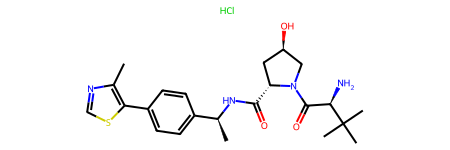

In [40]:
Chem.MolFromSmiles('Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1.Cl')

In [382]:
tanimotos = {}

In [391]:
def match_substructure(row, substruct_name='E3 Binder'):
    protac_mol = get_mol(row['PROTAC SMILES'])
    protac_fp = row['PROTAC FP']
    matched_smiles = float('nan')
    matched_id = float('nan')
    best_tanimoto = 0
    # Iterate through E3 Binders
    if substruct_name == 'E3 Binder':
        tmp = protac_db_e3_df
    elif substruct_name == 'POI Ligand':
        tmp = protac_db_poi_df
    elif substruct_name == 'Linker':
        tmp = protac_db_linkers_df
    for _, substruct_row in tmp.iterrows():
        substruct_smiles = substruct_row[f'{substruct_name} SMILES']
        # mol = substruct_row[f'{substruct_name} Mol']
        mol = get_mol(substruct_smiles)
        fp = substruct_row[f'{substruct_name} FP']
        if protac_mol.HasSubstructMatch(mol):
            tanimoto = tanimotos.get(f'{protac_smiles}, {substruct_smiles}', DataStructs.TanimotoSimilarity(protac_fp, fp))
            tanimotos[f'{protac_smiles}, {substruct_smiles}'] = tanimoto
            # tanimoto = DataStructs.TanimotoSimilarity(protac_fp, fp)
            if tanimoto > best_tanimoto:
                best_tanimoto = tanimoto
                matched_id = substruct_row['Compound ID']
                matched_smiles = substruct_smiles
    row[f'{substruct_name} SMILES'] = matched_smiles
    row[f'Compound ID {substruct_name}'] = matched_id
    return row

protac_db_df = protac_db_df.progress_apply(lambda x: match_substructure(x, substruct_name='E3 Binder'), axis=1)
protac_db_df = protac_db_df.progress_apply(lambda x: match_substructure(x, substruct_name='POI Ligand'), axis=1)
print(len(protac_db_df))
print(len(protac_db_df.dropna()))

  0%|          | 0/3270 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [394]:
protac_db_df = protac_db_df.progress_apply(lambda x: match_substructure(x, substruct_name='Linker'), axis=1)

  0%|          | 0/3270 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [389]:
protac_db_df[['PROTAC SMILES', 'E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']].dropna()

,PROTAC SMILES,E3 Binder SMILES,POI Ligand SMILES
0,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=...,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C
2,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@...,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C
4,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCC(=O)NCCNC2=CC=CC3=C2C(=O)N(C2CCC(=O)N...,NC1=CC=CC2=C1C(=O)N(C1CCC(=O)NC1=O)C2=O,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN(C)C
5,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCCOCCOCC(=O)NCCNC2=CC=CC3=C2C(=O)N(C2CC...,NC1=CC=CC2=C1C(=O)N(C1CCC(=O)NC1=O)C2=O,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN(C)C
10,COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCCOCCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C...,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C
...,...,...,...
5372,CC1=C(C2=CC=C([C@H](C)NC(=O)[C@@H]3C[C@@H](O)CN3C(=O)[C@@H](NC(=O)CN3CCN(C4=CC(C5=CC=CC=C5O)=NN=...,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C,CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCC1=CC=C(C2=C(C)N=CS2)C=C1)C(C)(C)C
5374,C[C@H]1CCCN1CC1=NC2=CC=C(NC(=O)C3=CC=C4C(=C3)C=NN4CCCCCCCCNC3=CC=CC4=C3C(=O)N(C3CCC(=O)NC3=O)C4=...,NC1=CC=CC2=C1C(=O)N(C1CCC(=O)NC1=O)C2=O,C[C@H]1CCCN1CC1=NC2=CC=C(NC(=O)C3=CC=C4C(=C3)C=NN4C)C=C2[NH]1
5375,C[C@H]1CCCN1CC1=NC2=CC=C(NC(=O)C3=CC=C4C(=C3)C=NN4CCCCCCNC3=CC=CC4=C3C(=O)N(C3CCC(=O)NC3=O)C4=O)...,NC1=CC=CC2=C1C(=O)N(C1CCC(=O)NC1=O)C2=O,C[C@H]1CCCN1CC1=NC2=CC=C(NC(=O)C3=CC=C4C(=C3)C=NN4C)C=C2[NH]1
5376,C[C@H]1CCCN1CC1=NC2=CC=C(NC(=O)C3=CC=C4C(=C3)C=NN4CCCCNC3=CC=CC4=C3C(=O)N(C3CCC(=O)NC3=O)C4=O)C=...,NC1=CC=CC2=C1C(=O)N(C1CCC(=O)NC1=O)C2=O,C[C@H]1CCCN1CC1=NC2=CC=C(NC(=O)C3=CC=C4C(=C3)C=NN4C)C=C2[NH]1


In [387]:
def extract_linker_smiles(protac_mol, poi_mol, e3_mol):
    """Get linker with attachment points."""
    if isinstance(protac_mol, str):
        protac_mol = Chem.MolFromSmiles(protac_mol)
    if isinstance(poi_mol, str):
        poi_mol = Chem.MolFromSmiles(poi_mol)
    if isinstance(e3_mol, str):
        e3_mol = Chem.MolFromSmiles(e3_mol)
    linker_smiles = float('nan')
    if protac_mol.HasSubstructMatch(poi_mol):
        rgroups = Chem.ReplaceCore(protac_mol, poi_mol, labelByIndex=False)
        rgroups_smiles = Chem.MolToSmiles(rgroups)
        linker_e3_smiles_mod = rgroups_smiles.replace("[1*]", "[*:1]")
        linker_e3_mol = Chem.MolFromSmiles(linker_e3_smiles_mod, sanitize=False)
        if linker_e3_mol:
            if linker_e3_mol.HasSubstructMatch(e3_mol):
                rgroups = Chem.ReplaceCore(linker_e3_mol, e3_mol, labelByIndex=False)
                rgroups_smiles = Chem.MolToSmiles(rgroups)
                linker_smiles = rgroups_smiles.replace("[1*]", "[*:2]")
    #         else:
    #             print('E3 non matching')
    # else:
    #     print('POI non matching')
    return linker_smiles

tmp = protac_db_df[['PROTAC SMILES', 'E3 Binder SMILES', 'POI Ligand SMILES']].dropna()
tmp.progress_apply(lambda x: extract_linker_smiles(x['PROTAC SMILES'], x['POI Ligand SMILES'], x['E3 Binder SMILES']), axis=1).dropna()

  0%|          | 0/2776 [00:00<?, ?it/s]

4             [*:2]CCNC(=O)COCCOCCN(C[2*])C[*:1]
5       [*:2]CCNC(=O)COCCOCCOCCOCCN(C[2*])C[*:1]
72                                 [*:2]CCC[*:1]
73                             [*:2]CCOCCOC[*:1]
75                                   [*:2]C[*:1]
                          ...                   
5330                    [*:2]C(=O)NCCCCCCCC[*:1]
5370                            [*:2]CC(=O)[*:1]
5374                           [*:2]CCCCCCC[*:1]
5375                             [*:2]CCCCC[*:1]
5376                               [*:2]CCC[*:1]
Length: 1171, dtype: object

In [ ]:



# Initialize empty lists to store the matched results
protac_smiles = []
e3_binder_smiles = []
poi_ligand_smiles = []
linker_smiles = []
linker_smarts = []

# Iterate through each PROTAC SMILES
for protac_smiles_row in tqdm(protac_db_df, total=len(protac_db_df)):
    protac_mol = get_mol(protac_smiles_row)
    # Initialize placeholders for matches
    matched_e3_binder = None
    matched_poi_ligand = None
    matched_linker = None
    matched_linker_smarts = None
    # Iterate through E3 Binders
    for e3_binder_smiles_row in protac_db_e3_df:
        e3_binder_mol = get_mol(e3_binder_smiles_row)
        if protac_mol.HasSubstructMatch(e3_binder_mol):
            matched_e3_binder = e3_binder_smiles_row
            break
    if not matched_e3_binder:
        continue
    # Iterate through POI Ligands
    for poi_ligand_smiles_row in protac_db_poi_df:
        poi_ligand_mol = get_mol(poi_ligand_smiles_row)
        if protac_mol.HasSubstructMatch(poi_ligand_mol):
            matched_poi_ligand = poi_ligand_smiles_row
            break
    if not matched_poi_ligand:
        continue
    # Get Linker by removing E3 Binder and POI Ligand from PROTAC
    linker_mol_subtracted = AllChem.DeleteSubstructs(protac_mol, get_mol(matched_poi_ligand))
    linker_mol_subtracted = AllChem.DeleteSubstructs(linker_mol_subtracted, get_mol(matched_e3_binder))

    # Iterate through Linkers SMILES and Linkers SMARTS
    for i in range(len(protac_db_linkers_df)):
        linker_smiles_row = protac_db_linkers_df.iloc[i]['Linker SMILES']
        linker_smarts_row = protac_db_linkers_df.iloc[i]['Linker SMARTS']
        
        linker_mol = Chem.MolFromSmiles(linker_smiles_row)
        linker_smart = Chem.MolFromSmarts(linker_smarts_row)
        
        if protac_mol.HasSubstructMatch(linker_mol) or protac_mol.HasSubstructMatch(linker_smart):
            if get_tanimoto(linker_mol, linker_mol_subtracted) > 0.9:
                matched_linker = linker_smiles_row
                matched_linker_smarts = linker_smarts_row
                break
    if not matched_linker:
        continue

    # Append the matched results to the lists
    protac_smiles.append(protac_smiles_row)
    e3_binder_smiles.append(matched_e3_binder)
    poi_ligand_smiles.append(matched_poi_ligand)
    linker_smiles.append(matched_linker)
    # linker_smarts.append(matched_linker_smarts)

# Create a new DataFrame with the matched results
result_df = pd.DataFrame({
    'PROTAC SMILES': protac_smiles,
    'E3 Binder SMILES': e3_binder_smiles,
    'POI Ligand SMILES': poi_ligand_smiles,
    'Linker SMILES': linker_smiles,
    'Linker SMARTS': linker_smarts
})
result_df

In [ ]:
print(len(result_df)) # 3270
print(len(result_df.dropna())) # 2776

3270
2776


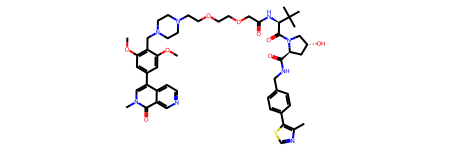

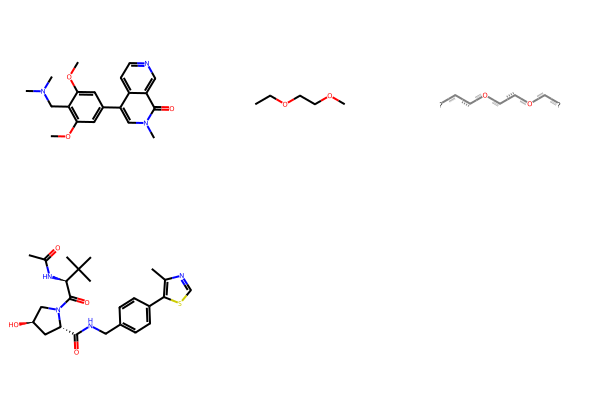

--------------------------------------------------------------------------------


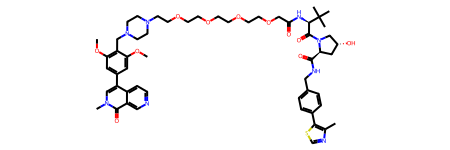

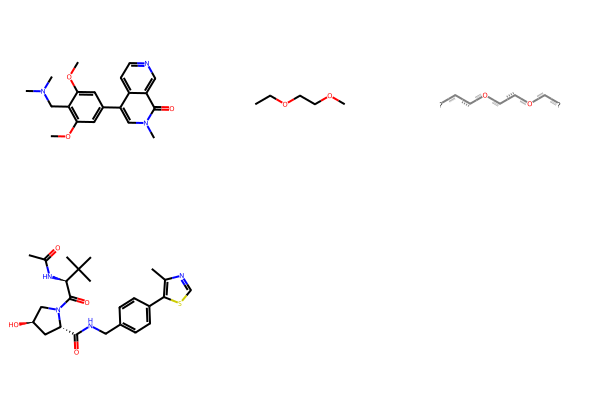

--------------------------------------------------------------------------------


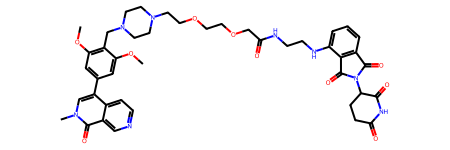

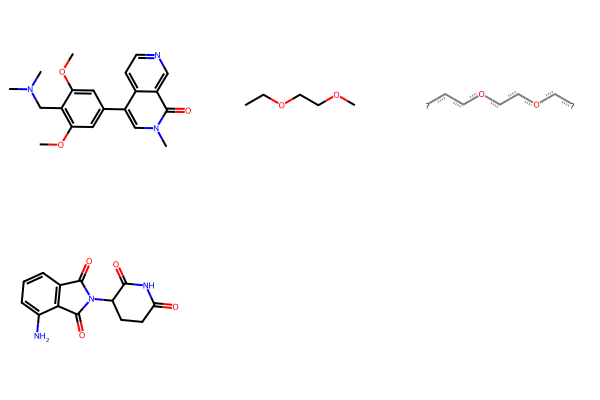

--------------------------------------------------------------------------------


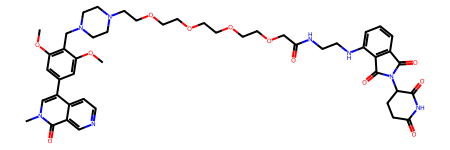

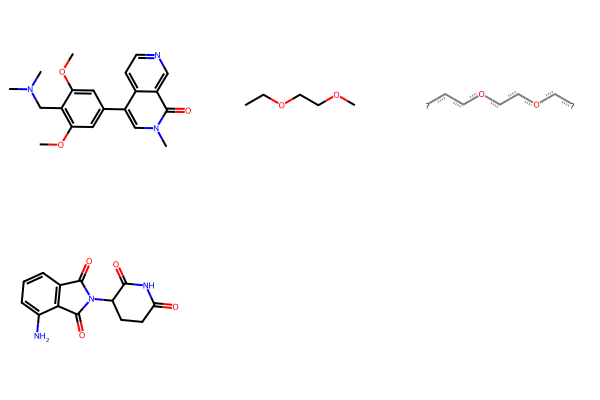

--------------------------------------------------------------------------------


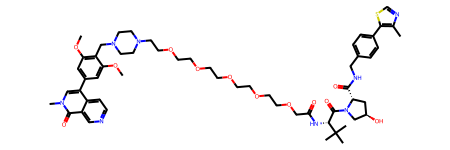

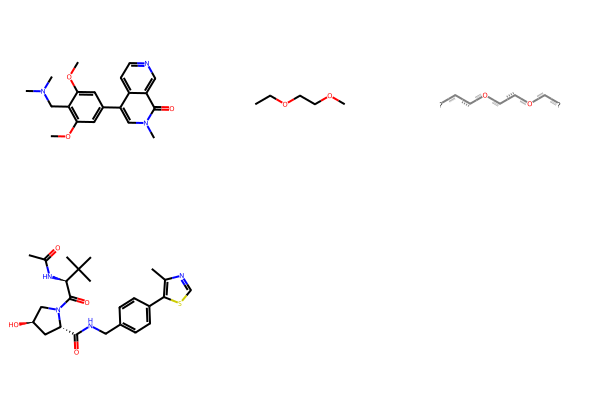

--------------------------------------------------------------------------------


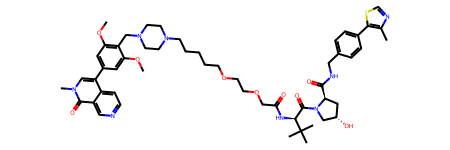

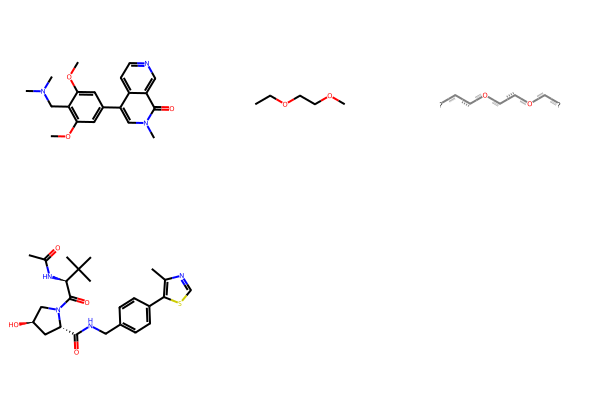

--------------------------------------------------------------------------------


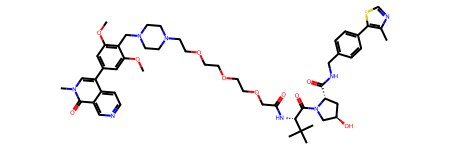

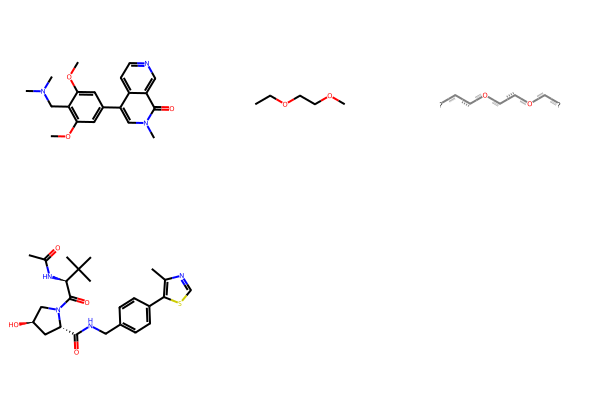

--------------------------------------------------------------------------------


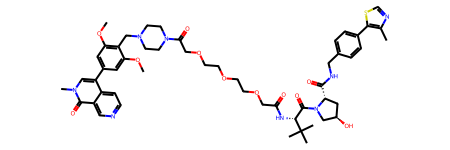

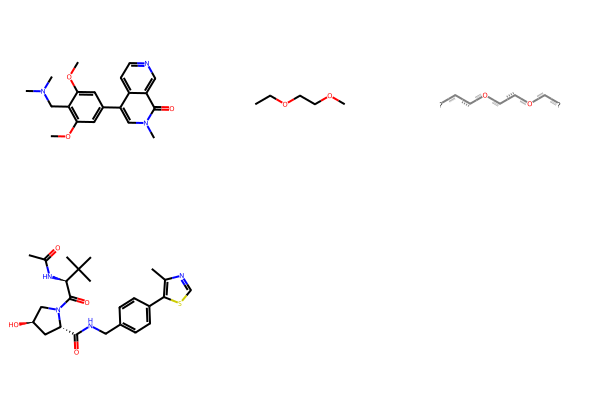

--------------------------------------------------------------------------------


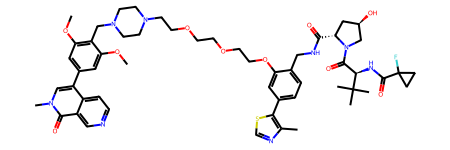

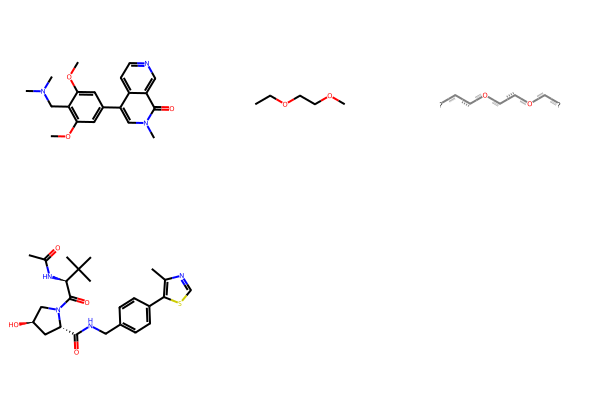

--------------------------------------------------------------------------------


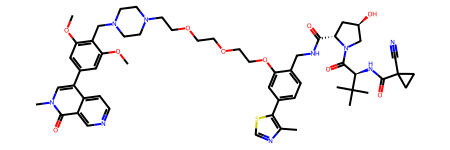

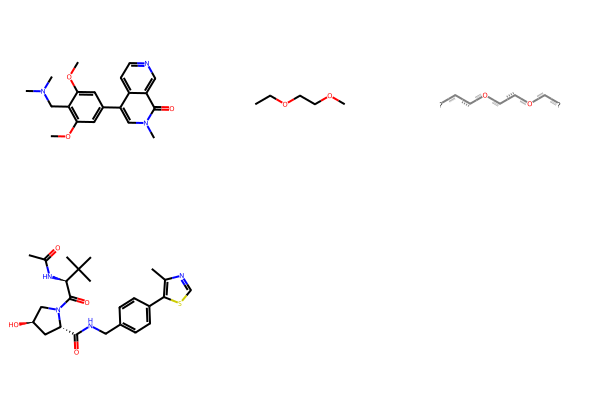

--------------------------------------------------------------------------------


In [323]:
# Display PROTAC molecule and below the E3, Linker and POI side-by-side
for i, row in result_df.dropna().iterrows():
    protac_smiles = row['PROTAC SMILES']
    e3_binder_smiles = row['E3 Binder SMILES']
    poi_ligand_smiles = row['POI Ligand SMILES']
    linker_smiles = row['Linker SMILES']
    linker_smarts = row['Linker SMARTS']
    
    protac_mol = Chem.MolFromSmiles(protac_smiles)
    e3_binder_mol = Chem.MolFromSmiles(e3_binder_smiles)
    poi_ligand_mol = Chem.MolFromSmiles(poi_ligand_smiles)
    linker_mol = Chem.MolFromSmiles(linker_smiles)
    linker_smart = Chem.MolFromSmarts(linker_smarts)
    
    display(protac_mol)
    display(Draw.MolsToGridImage([poi_ligand_mol, linker_mol, linker_smart, e3_binder_mol]))
    # display(view_difference(protac_mol, e3_binder_mol))
    # display(view_difference(protac_mol, linker_mol))
    # display(view_difference(protac_mol, poi_ligand_mol))
    print('-' * 80)
    if i > 10:
        break

In [ ]:
compound_id = protac_db_df['Compound ID'].iloc[19]
protac_smiles = protac_db_df[protac_db_df['Compound ID'] == compound_id]['Smiles'].iloc[0]
poi_smiles = protac_db_poi_df[protac_db_poi_df['Compound ID'] == compound_id]['Smiles'].iloc[0]
linker_smiles = protac_db_linkers_df[protac_db_linkers_df['Compound ID'] == compound_id]['Smiles_R'].iloc[0]
e3_smiles = protac_db_e3_df[protac_db_e3_df['Compound ID'] == compound_id]['Smiles'].iloc[0]

display(protac_db_df[protac_db_df['Compound ID'] == compound_id]['Smiles'].drop_duplicates())
display(protac_db_poi_df[protac_db_poi_df['Compound ID'] == compound_id]['Smiles'].drop_duplicates())
display(protac_db_linkers_df[protac_db_linkers_df['Compound ID'] == compound_id]['Smiles'].drop_duplicates())
display(protac_db_e3_df[protac_db_e3_df['Compound ID'] == compound_id]['Smiles'].drop_duplicates())

print_stats(protac_smiles, e3_smiles, linker_smiles, poi_smiles)
display(Chem.MolFromSmiles(protac_smiles))
display(Chem.MolFromSmiles(poi_smiles))
display(Chem.MolFromSmarts(linker_smiles))
display(Chem.MolFromSmiles(e3_smiles))

`DetectChemistryProblems`

In [257]:
def is_single_mol(mol):
    return len(Chem.MolToSmiles(mol).split('.')) == 1

# Define a function to check if 'E3 Binder SMILES' and 'POI Ligand SMILES' match the modified 'PROTAC SMILES'
def check_matching(row):
    protac_smiles = row['PROTAC SMILES']
    e3_smiles = row['E3 Binder SMILES']
    poi_smiles = row['POI Ligand SMILES']
    linker_smiles = row['Linker SMILES']

    # Split 'PROTAC SMILES' into 'E3 Binder SMILES' and 'POI Ligand SMILES'
    # Implement custom logic to perform this split

    # Remove 'Linker SMILES' from the 'PROTAC SMILES'
    protac_mol = get_mol(protac_smiles)
    linker_mol = get_mol(linker_smiles)
    e3_mol = get_mol(e3_smiles)
    poi_mol = get_mol(poi_smiles)



    e3_substracted = AllChem.DeleteSubstructs(protac_mol, poi_mol)
    e3_substracted = AllChem.DeleteSubstructs(e3_substracted, linker_mol)
    if not is_single_mol(e3_substracted):
        print(f'Non-matching E3:')
        display(protac_mol)
        display(view_difference(e3_mol, e3_substracted))
        display(Draw.MolsToGridImage([poi_mol, linker_mol]))

    poi_substracted = AllChem.DeleteSubstructs(protac_mol, e3_mol)
    poi_substracted = AllChem.DeleteSubstructs(poi_substracted, linker_mol)
    if not is_single_mol(poi_substracted):
        print(f'Non-matching POI:')
        display(protac_mol)
        display(view_difference(poi_mol, poi_substracted))
        display(Draw.MolsToGridImage([e3_mol, linker_mol]))
    #     # Compare the modified 'PROTAC SMILES' with 'E3 Binder SMILES' and 'POI Ligand SMILES'
    #     if protac_without_linker:
    #         modified_protac_smiles = Chem.MolToSmiles(protac_without_linker)
    #         return modified_protac_smiles == e3_smiles and modified_protac_smiles == poi_smiles

    # return False

all_matching_df.progress_apply(check_matching, axis=1)

  0%|          | 0/635 [00:00<?, ?it/s]

[12:40:01] 

****
Pre-condition Violation
bad replacementConnectionPoint
Violation occurred on line 177 in file C:\rdkit\build\temp.win-amd64-cpython-311\Release\rdkit\Code\GraphMol\ChemTransforms\ChemTransforms.cpp
Failed Expression: replacementConnectionPoint < replacement.getNumAtoms()
****



RuntimeError: Pre-condition Violation
	bad replacementConnectionPoint
	Violation occurred on line 177 in file Code\GraphMol\ChemTransforms\ChemTransforms.cpp
	Failed Expression: replacementConnectionPoint < replacement.getNumAtoms()
	RDKIT: 2023.03.1
	BOOST: 1_78


  0%|          | 0/635 [00:00<?, ?it/s]

[1*]C(=O)CCCCCCCCCC[2*]
C(=O)CCCCCCCCCC
[1*]C(=O)CCCCCCCCCC[2*]
C(=O)CCCCCCCCCC
PROTAC:


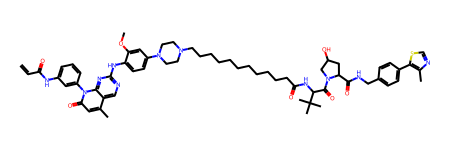

Labeled Linker vs subtracted one:


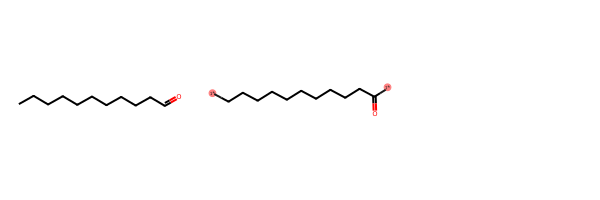

--------------------------------------------------------------------------------
[2*]=O
=O
PROTAC:


[11:42:06] SMILES Parse Error: syntax error while parsing: =O
[11:42:06] SMILES Parse Error: Failed parsing SMILES '=O' for input: '=O'


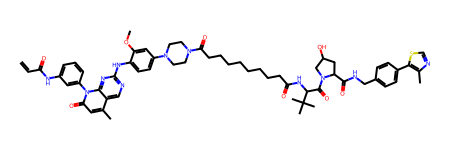

Labeled Linker vs subtracted one:


ValueError: molecule is None

In [241]:
def is_single_mol(mol):
    return len(Chem.MolToSmiles(mol).split('.')) == 1

def split_mol(mol):
    return [Chem.MolFromSmiles(s) for s in Chem.MolToSmiles(mol).split('.')]

def remove_connecting_atms(mol):
    if not isinstance(mol, str):
        mol = Chem.MolToSmiles(mol)
    print(mol)
    for i in range(10):
        mol = mol.replace(f'[{i}*]', '')
    print(mol)
    return Chem.MolFromSmiles(mol)

def view_difference(mol1, mol2):
    mcs = rdFMCS.FindMCS([mol1,mol2])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    match1 = mol1.GetSubstructMatch(mcs_mol)
    target_atm1 = []
    for atom in mol1.GetAtoms():
        if atom.GetIdx() not in match1:
            target_atm1.append(atom.GetIdx())
    match2 = mol2.GetSubstructMatch(mcs_mol)
    target_atm2 = []
    for atom in mol2.GetAtoms():
        if atom.GetIdx() not in match2:
            target_atm2.append(atom.GetIdx())
    return Draw.MolsToGridImage([mol1, mol2], highlightAtomLists=[target_atm1, target_atm2])

def are_mols_same(mol1, mol2):
    if mol1 is None or mol2 is None:
        return False
    return mol1.HasSubstructMatch(mol2) and mol2.HasSubstructMatch(mol1)

for i, row in tqdm(enumerate(all_matching_df.iterrows()), total=len(all_matching_df)):
    row_dict = row[1].to_dict()
    protac_mol = get_mol(row_dict['PROTAC SMILES'])
    e3_mol = get_mol(row_dict['E3 Binder SMILES'])
    poi_mol = get_mol(row_dict['POI Ligand SMILES'])
    linker_mol = get_mol(row_dict['Linker SMILES'])
    e3_linker_mol = Chem.ReplaceCore(protac_mol, e3_mol, labelByIndex=False)
    linker_subtracted_mol = Chem.ReplaceCore(e3_linker_mol, poi_mol, labelByIndex=False)
    if not is_single_mol(linker_subtracted_mol):
        linker_subtracted_mol = remove_connecting_atms(split_mol(linker_subtracted_mol)[-1])
    # display(e3_linker_mol)
    # display(poi_mol)
    # display(linker_subtracted_mol)
    if not are_mols_same(linker_mol, linker_subtracted_mol):
        print(f'PROTAC:')
        display(protac_mol)
        print(f'Labeled Linker vs subtracted one:')
        display(view_difference(linker_mol, linker_subtracted_mol))
        # print(f'Subtracted Linker:')
        # display(linker_subtracted_mol)
        print('-' * 80)
    if i > 20:
        break

For substrucutres that are not part of the PROTAC, we search for all the respective substructures that are of other PROTACs:

  0%|          | 0/532 [00:00<?, ?it/s]

Splitting E3+POI groups failed.
PROTAC:


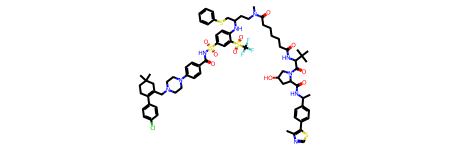

Groups:


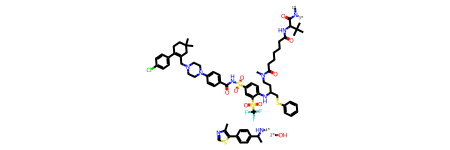

Mismatching molecule (POI Ligand SMILES):


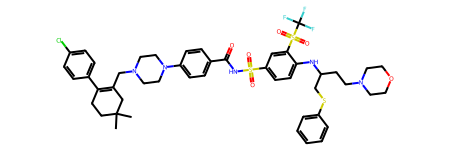

--------------------------------------------------------------------------------
Splitting E3+POI groups failed.
PROTAC:


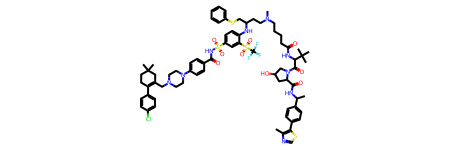

Groups:


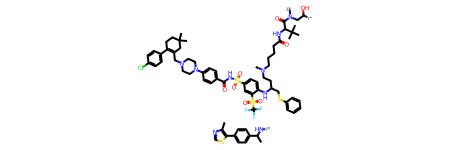

Mismatching molecule (POI Ligand SMILES):


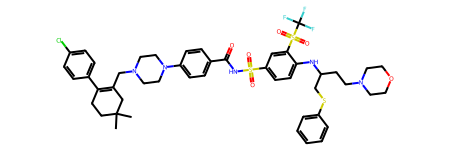

--------------------------------------------------------------------------------
Splitting E3+POI groups failed.
PROTAC:


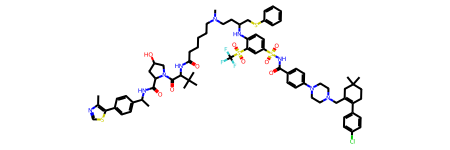

Groups:


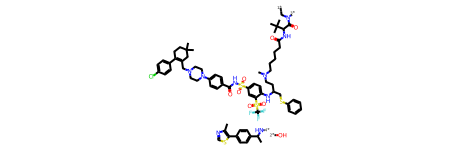

Mismatching molecule (POI Ligand SMILES):


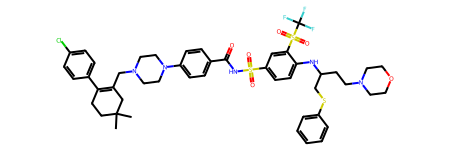

--------------------------------------------------------------------------------
Splitting E3+POI groups failed.
PROTAC:


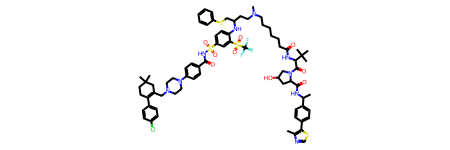

Groups:


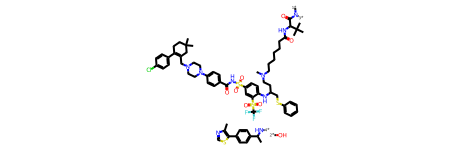

Mismatching molecule (POI Ligand SMILES):


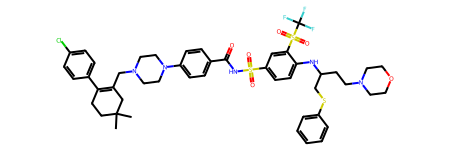

--------------------------------------------------------------------------------
E3 Binder SMILES successful substitution!
PROTAC:


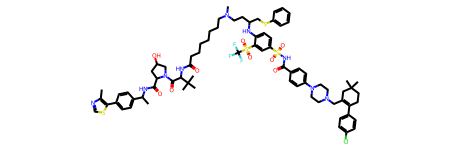

Matching molecule:


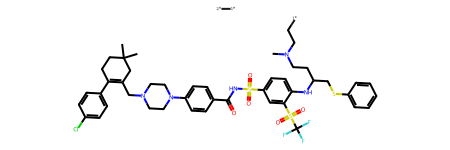

Mismatching molecule (POI Ligand SMILES):


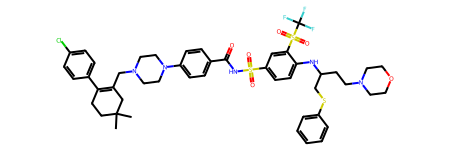

E3 Binder SMILES:


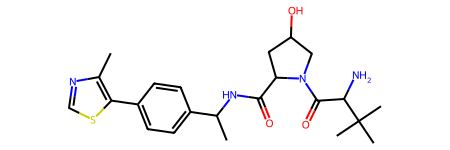

--------------------------------------------------------------------------------
E3 Binder SMILES successful substitution!
PROTAC:


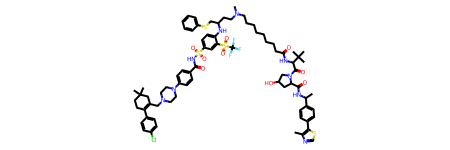

Matching molecule:


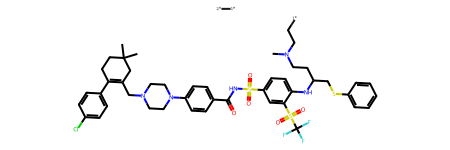

Mismatching molecule (POI Ligand SMILES):


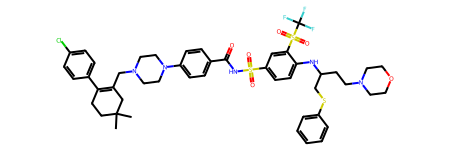

E3 Binder SMILES:


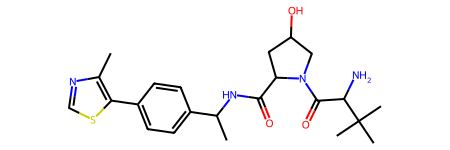

--------------------------------------------------------------------------------
E3 Binder SMILES successful substitution!
PROTAC:


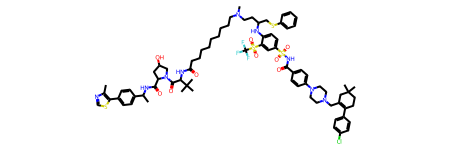

Matching molecule:


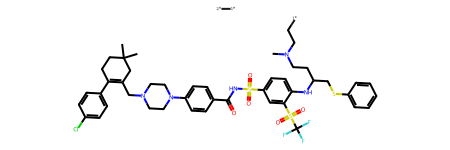

Mismatching molecule (POI Ligand SMILES):


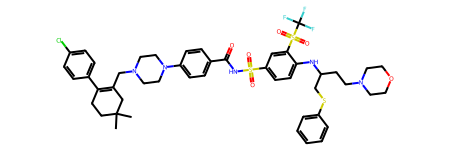

E3 Binder SMILES:


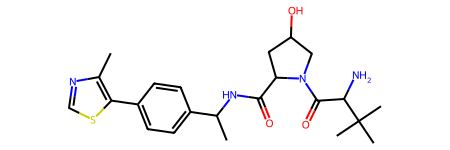

--------------------------------------------------------------------------------
E3 Binder SMILES successful substitution!
PROTAC:


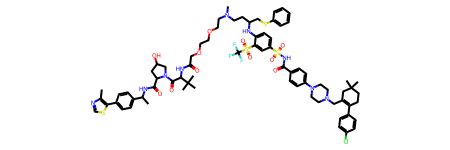

Matching molecule:


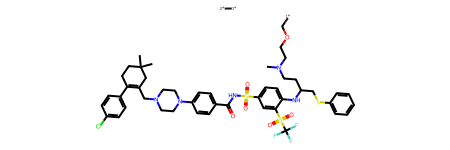

Mismatching molecule (POI Ligand SMILES):


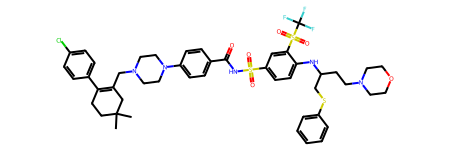

E3 Binder SMILES:


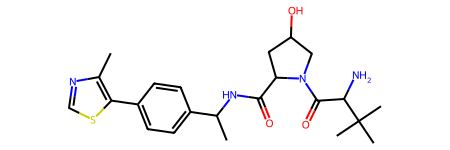

--------------------------------------------------------------------------------
E3 Binder SMILES successful substitution!
PROTAC:


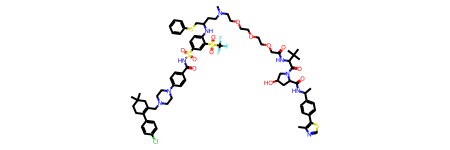

Matching molecule:


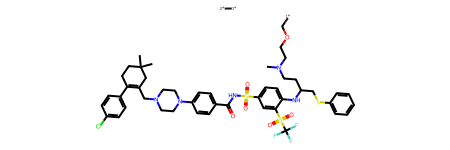

Mismatching molecule (POI Ligand SMILES):


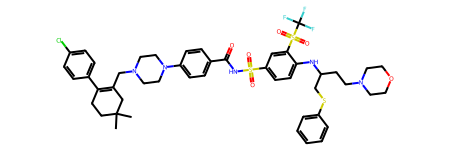

E3 Binder SMILES:


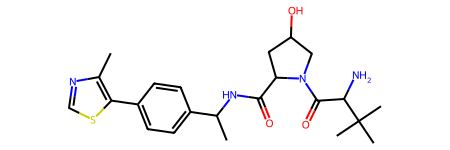

--------------------------------------------------------------------------------
E3 Binder SMILES successful substitution!
PROTAC:


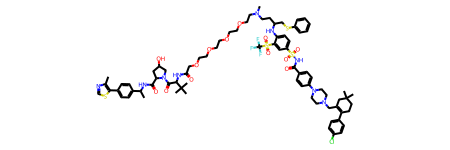

Matching molecule:


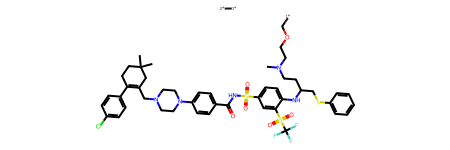

Mismatching molecule (POI Ligand SMILES):


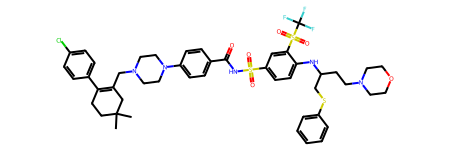

E3 Binder SMILES:


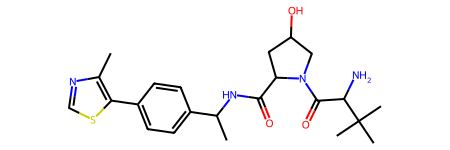

--------------------------------------------------------------------------------


KeyboardInterrupt: 

In [206]:


def get_closest_match(protac, nonmatching_substruct, substruct_dict):
    """
    Get the closest match in the set to the SMILES.
    """
    if isinstance(protac, str):
        protac_mol = Chem.MolFromSmiles(protac)
        Chem.rdmolops.RemoveStereochemistry(protac_mol)
    else:
        protac_mol = protac
    if isinstance(nonmatching_substruct, str):
        nonmatching_substruct_smiles = nonmatching_substruct
        nonmatching_substruct_mol = Chem.MolFromSmiles(nonmatching_substruct_smiles)
        Chem.rdmolops.RemoveStereochemistry(nonmatching_substruct_mol)
    else:
        nonmatching_substruct_mol = nonmatching_substruct
    min_tanimoto = 1
    closest_substruct_smiles = None
    closest_substruct_mol = None
    tanimoto_threshold = 0.8
    # Iterate over the substruct dict
    for candidate_smiles, candidate_mol in substruct_dict.items():
        tanimoto = get_tanimoto(nonmatching_substruct_mol, candidate_mol)
        if tanimoto < tanimoto_threshold:
            continue
        # NOTE: We also need to check that the candidate substruct is very
        # similar to the mismatching substruct, otherwise we might get the first
        # matching substruct in the dictionary, which is not necessarily the
        # closest one, but maybe just a smaller substructure of the mismatch.
        # Check if substruct is a substructure of the PROTAC, if yes, return it
        if protac_mol.HasSubstructMatch(candidate_mol):
            return candidate_smiles, candidate_mol
        # Else, keep looking for the most similar one
        if tanimoto < min_tanimoto:
            min_tanimoto = tanimoto
            closest_substruct_smiles = candidate_smiles
            closest_substruct_mol = candidate_mol
    return closest_substruct_smiles, closest_substruct_mol

closest_matching_df = []
still_non_matching_df = []
cnt = Counter()
# Iterate over protac_pedia_df rows
for i, row in (pbar := tqdm(enumerate(non_matching_df.iterrows()), total=len(non_matching_df))):
    if i < 15:
        continue

    # Get the row as a dict
    row_dict = row[1].to_dict()
    protac_smiles = row_dict['PROTAC SMILES']
    protac_mol = get_mol(protac_smiles)
    
    all_substruct_matching = True
    condidate_substructs = {}
    for substruct_name, substructs_dict in matching_substructs_dict.items():
        substruct_smiles = row_dict[substruct_name]
        substruct_mol = get_mol(substruct_smiles)
        if not protac_mol.HasSubstructMatch(substruct_mol):
            closest_match_smiles, closest_match_mol = get_closest_match(
                protac=protac_mol,
                nonmatching_substruct=substruct_mol,
                substruct_dict=substructs_dict,
            )
            if closest_match_smiles is None:
                all_substruct_matching = False
                cnt[f'{substruct_name} failed substitution'] += 1
                continue
            closest_match_mol = get_mol(closest_match_smiles)
            is_perfect_match = protac_mol.HasSubstructMatch(closest_match_mol)
            cnt[f'{substruct_name} successful substitution'] += int(is_perfect_match)
            # print(f'{substruct_name} non-matching:  {substruct_smiles}')
            # display(substruct_mol)
            # print(f'{substruct_name} closest match: {closest_match_smiles}')
            # display(closest_match_mol)
            # print(f'{substruct_name} is perfect substructure match: {is_perfect_match}')
            if not is_perfect_match:
                all_substruct_matching = False
                # print(f'PROTAC:')
                # display(protac_mol)
                # cnt[f'{substruct_name} failed substitution'] += 1
                condidate_substructs[substruct_name] = {
                    'smiles': closest_match_smiles,
                    'mol': closest_match_mol,
                }
    # In case we still need to match substructures, check if Linker is matching,
    # then remove it and try to match the remaining substructures 
    if not all_substruct_matching and 'Linker SMILES' not in condidate_substructs and len(condidate_substructs) == 1:
        # Remove the matching substructure from the remaining group
        if 'POI Ligand SMILES' in condidate_substructs:
            mol_to_remove = get_mol(row_dict['E3 Binder SMILES'])
            candidate_mol = condidate_substructs['POI Ligand SMILES']['mol']
            mismatch_mol = get_mol(row_dict['POI Ligand SMILES'])
        elif 'E3 Binder SMILES' in condidate_substructs:
            mol_to_remove = get_mol(row_dict['POI Ligand SMILES'])
            candidate_mol = condidate_substructs['E3 Binder SMILES']['mol']
            mismatch_mol = get_mol(row_dict['E3 Binder SMILES'])
        else:
            raise ValueError('Something went wrong with the substructure matching.')
        
        # Get E3+POI groups
        linker_mol = get_mol(row_dict['Linker SMILES'])
        rgroups_mol = Chem.ReplaceCore(protac_mol, linker_mol, labelByIndex=False)
        rgroup_mol = Chem.ReplaceCore(rgroups_mol, mol_to_remove, labelByIndex=False)


        # rgroups_mol = Chem.ReplaceCore(protac_mol, linker_mol, labelByIndex=False)
        # rgroups_smiles = Chem.MolToSmiles(rgroups_mol).split('.')

        # rgroups_mol = Chem.ReplaceCore(protac_mol, mol_to_remove, labelByIndex=False)
        # rgroup_mol = Chem.ReplaceCore(rgroups_mol, linker_mol, labelByIndex=False)


        if rgroup_mol is None:
            print(f'Splitting E3+POI groups failed.')
            print(f'PROTAC:')
            display(protac_mol)
            print(f'Groups:')
            display(rgroups_mol)
            print(f'Mismatching molecule ({list(condidate_substructs.keys())[0]}):')
            display(mismatch_mol)
            print('-' * 80)
        else:
            tanimoto_threshold = 0.95
            if get_tanimoto(rgroup_mol, mismatch_mol) > tanimoto_threshold:
                cnt[f'{substruct_name} successful substitution'] += int(is_perfect_match)
                print(f'{substruct_name} successful substitution!')
                print(f'PROTAC:')
                display(protac_mol)
                print(f'Matching molecule:')
                display(rgroup_mol)
                print(f'Mismatching molecule ({list(condidate_substructs.keys())[0]}):')
                display(mismatch_mol)
                print(f'E3 Binder SMILES:')
                display(get_mol(row_dict['E3 Binder SMILES']))
                print('-' * 80)
                all_substruct_matching = True
    # print('-' * 80)
    if all_substruct_matching:
        closest_matching_df.append(row)
    else:
        still_non_matching_df.append(row)
    fixed_smiles_len = len(closest_matching_df)
    pbar.set_postfix({f'Fixed-so-far': f'{fixed_smiles_len / len(non_matching_df):.1%}'})
for k, v in cnt.items():
    print(f'{k}: {v}')
closest_matching_df = pd.DataFrame(closest_matching_df)
still_non_matching_df = pd.DataFrame(still_non_matching_df)
print('Starting len:', len(non_matching_df))
print('Fixed len:', len(closest_matching_df))
print('Not-fixed len:', len(still_non_matching_df))

In [95]:
from tqdm import tqdm
from tqdm.auto import tqdm  # for notebooks

# Create new `pandas` methods which use `tqdm` progress
# (can use tqdm_gui, optional kwargs, etc.)
tqdm.pandas()

fpgen = AllChem.GetRDKitFPGenerator()

def assign_closest_match(protac_smiles, nonmatching_substruct_smiles, substruct_dict):
    """
    Assigns the closest match in the set to the SMILES.
    """
    protac_mol = Chem.MolFromSmiles(protac_smiles)
    Chem.rdmolops.RemoveStereochemistry(protac_mol)
    nonmatching_substruct_mol = Chem.MolFromSmiles(nonmatching_substruct_smiles)
    Chem.rdmolops.RemoveStereochemistry(nonmatching_substruct_mol)
    min_tanimoto = 1
    min_substruct = None
    for substruct_smiles, substruct_mol in substruct_dict.items():
        # Check if substruct is a substructure of the PROTAC, if yes, return it
        if protac_mol.HasSubstructMatch(substruct_mol):
            return substruct_smiles
        # Else, keep looking for the most similar one
        tanimoto = DataStructs.TanimotoSimilarity(
            fpgen.GetFingerprint(nonmatching_substruct_mol),
            fpgen.GetFingerprint(substruct_mol),
        )
        if tanimoto < min_tanimoto:
            min_tanimoto = tanimoto
            min_substruct = substruct_smiles
    return min_substruct

for substruct in matching_substructs.keys():
    print(substruct)
    non_matching_df[f'{substruct} (closest)'] = non_matching_df.progress_apply(lambda row: assign_closest_match(row['PROTAC SMILES'], row[substruct], matching_substructs_mol[substruct]), axis=1)
non_matching_df.head()

POI Ligand SMILES


  0%|          | 0/532 [00:00<?, ?it/s]

Linker SMILES


C:\Users\ste\AppData\Local\Temp\ipykernel_4040\2235113252.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_matching_df[f'{substruct} (closest)'] = non_matching_df.progress_apply(lambda row: assign_closest_match(row['PROTAC SMILES'], row[substruct], matching_substructs_mol[substruct]), axis=1)


  0%|          | 0/532 [00:00<?, ?it/s]

E3 Binder SMILES


C:\Users\ste\AppData\Local\Temp\ipykernel_4040\2235113252.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_matching_df[f'{substruct} (closest)'] = non_matching_df.progress_apply(lambda row: assign_closest_match(row['PROTAC SMILES'], row[substruct], matching_substructs_mol[substruct]), axis=1)


  0%|          | 0/532 [00:00<?, ?it/s]

C:\Users\ste\AppData\Local\Temp\ipykernel_4040\2235113252.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_matching_df[f'{substruct} (closest)'] = non_matching_df.progress_apply(lambda row: assign_closest_match(row['PROTAC SMILES'], row[substruct], matching_substructs_mol[substruct]), axis=1)


,PROTAC SMILES,E3 Binder SMILES,Linker SMILES,POI Ligand SMILES,POI Ligand SMILES (closest),Linker SMILES (closest),E3 Binder SMILES (closest)
0,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CC(=O)N2CCN(CC[C@H](CSc3ccccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,CCCCC,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C)N)cc1
1,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCC(=O)N2CCN(CC[C@H](CSc3cccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,CCCCC,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C)N)cc1
2,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCC(=O)N2CCN(CC[C@H](CSc3ccc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,CCCCC,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C)N)cc1
3,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCC(=O)N2CCN(CC[C@H](CSc3cc...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,CCCCC,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C)N)cc1
4,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)CCCCCC(=O)N2CCN(CC[C@H](CSc3c...,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,NC(=O)CCCCCC=O,CC1(C)CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)...,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1,CCCCC,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](C)N)cc1


non-matching POI Ligand SMILES. Tanimoto: 0.817095038852361
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8200359928014397
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.821021021021021
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8205282112845138
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8205282112845138
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8205282112845138
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8215144230769231
--------------------------------------------------------------------------------
non-matc

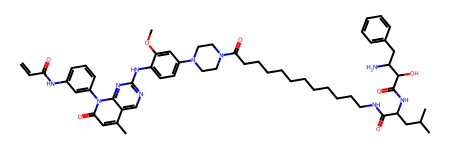

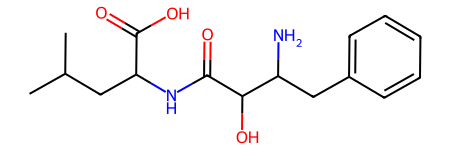

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.8206374932468936
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.8228602383531961
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.8206374932468936
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.8206374932468936
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.8206374932468936
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7297830374753451
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7288246881155613
-----------

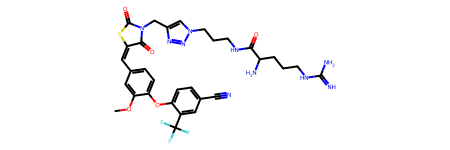

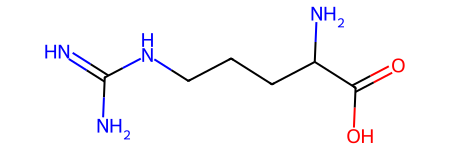

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.176


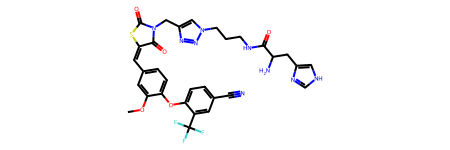

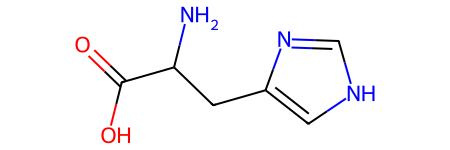

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.45692051139521955


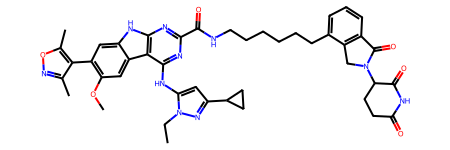

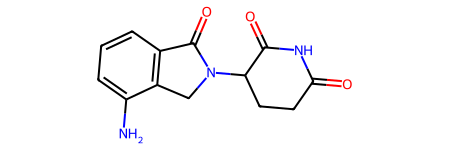

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.45666666666666667


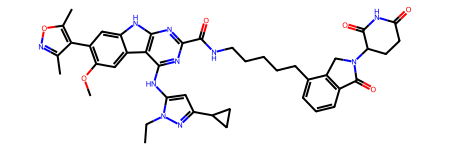

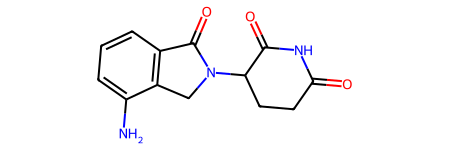

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.45692051139521955


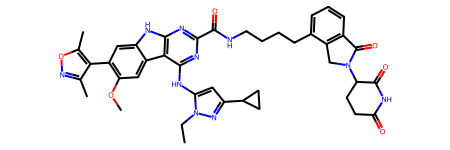

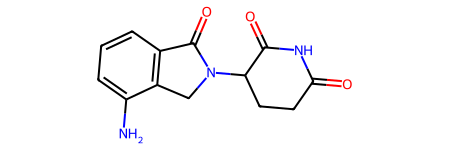

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.45798553144129106


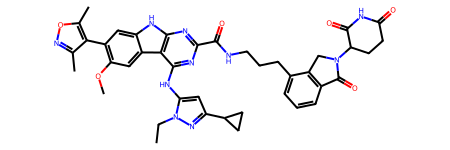

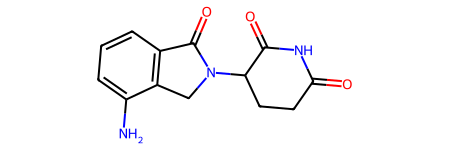

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7210702341137124
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7291807718348002
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7058437294812869
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7142857142857143
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7255689424364123
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7110091743119266
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7142857142857143
------

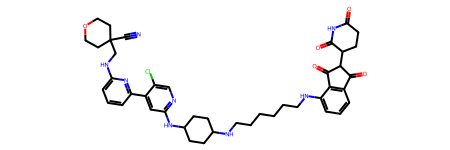

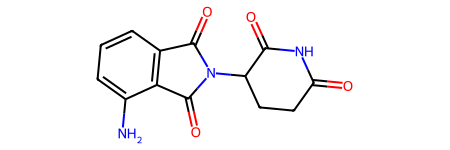

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6122311827956989
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6455516014234876
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8881004366812227
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8895571350464735
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.864516129032258
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8764897074756229
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8835429196282122
-------

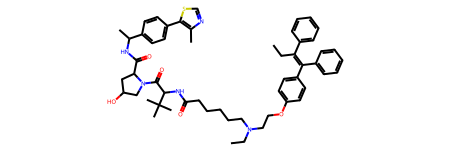

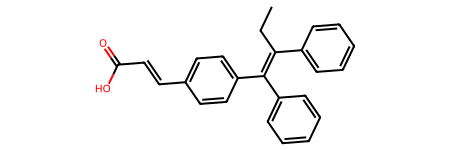

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8132825258573761
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8099891422366993
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8058252427184466
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8041958041958042
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8224917309812569
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8224917309812569
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.49604072398190047


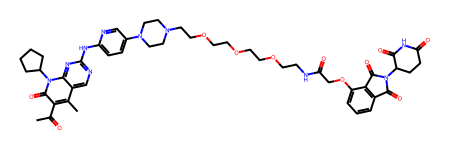

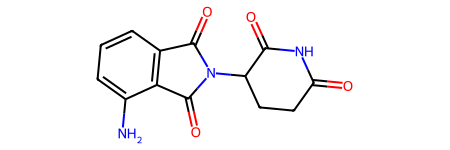

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.812807881773399
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8057514921323928
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8058568329718004
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8058568329718004
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8058568329718004
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8214876033057851
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8193300384404174
-------

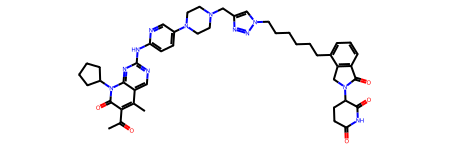

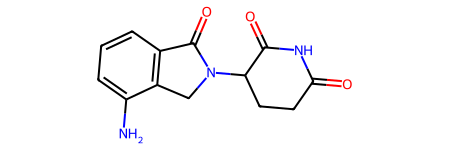

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4935284186831739


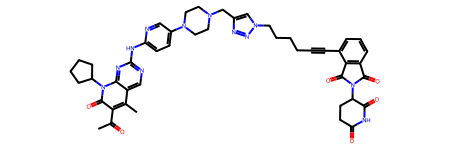

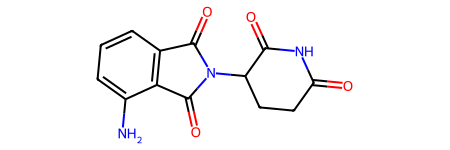

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4932508436445444


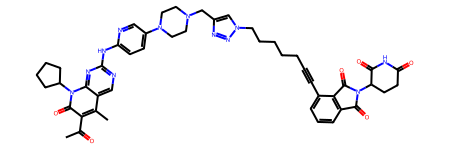

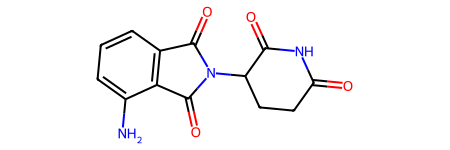

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7588270496708558
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7611044417767107
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7538644470868014
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7791601866251944
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.7437825332562175
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5544492843808339
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5217391304347826
non-mat

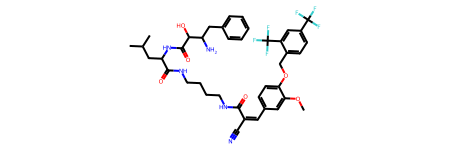

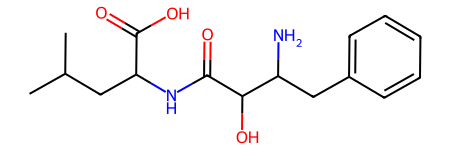

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.43613138686131386


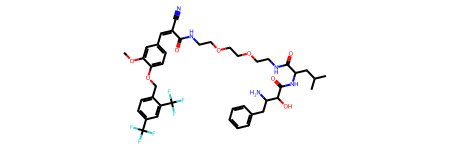

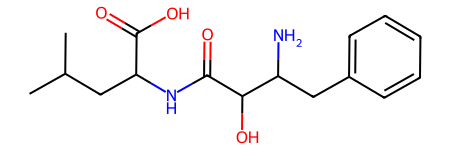

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7116438356164384
non-matching E3 Binder SMILES. Tanimoto: 0.5221414408460013
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7208821502412129
non-matching E3 Binder SMILES. Tanimoto: 0.5198150594451784
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6983277591973244
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7101154107264087
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7115646258503401
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7139931740614335
----------------------------

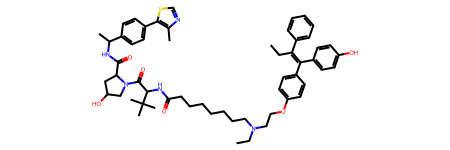

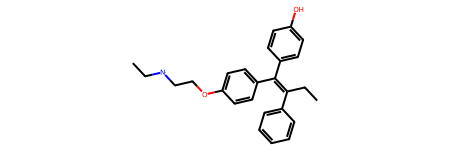

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.3993532740501213


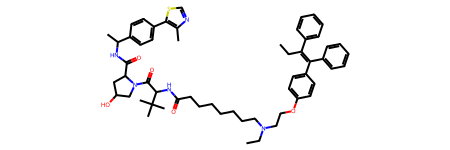

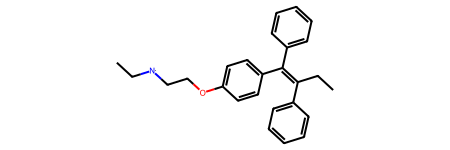

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6944809461235217
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5232732732732732
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7233748271092669
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7427149964463398
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7416607523066004
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7407932011331445
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.736953455571227
-------

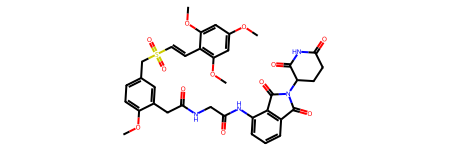

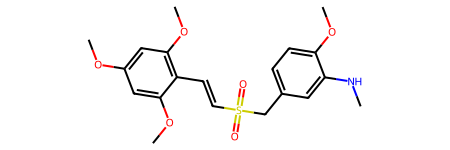

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.824773413897281
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6855807743658211
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6855807743658211
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6855807743658211
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7063172043010753
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7063172043010753
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7063172043010753
-------

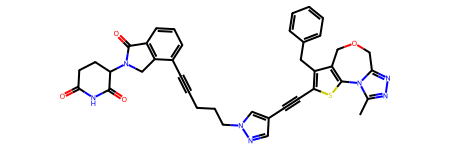

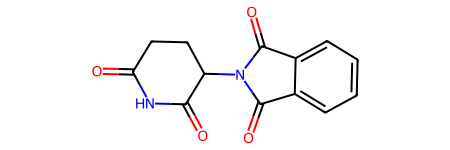

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.75737507525587
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7574287446937538
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7481005260081823
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.42105263157894735


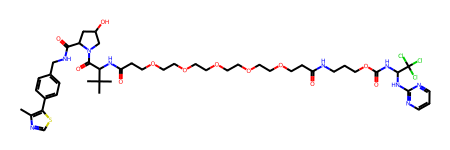

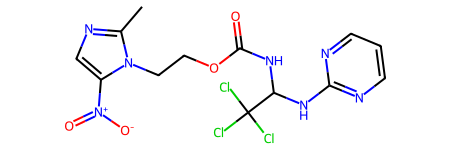

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5582431572246976
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5875238701464036
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5578880407124682
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5911708253358925
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.559462915601023
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.5229960578186597
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.5219960604070912
---------

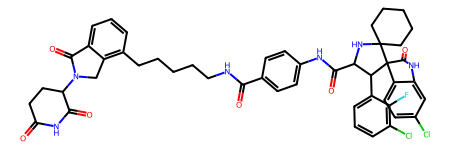

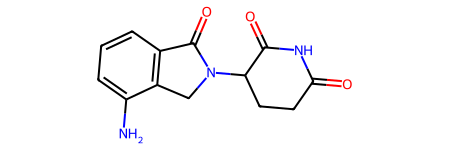

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4558011049723757


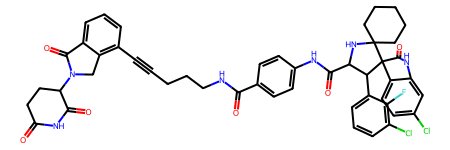

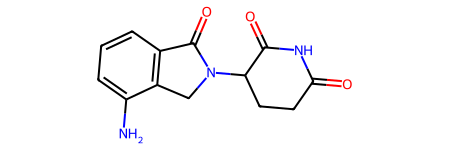

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4573170731707317


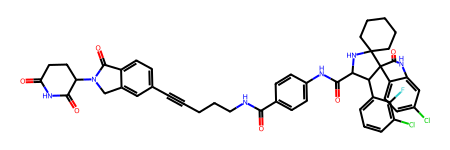

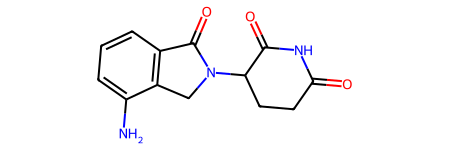

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.45706371191135736


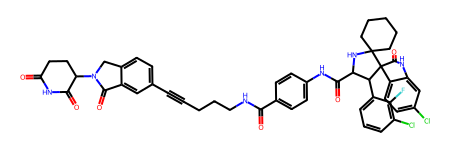

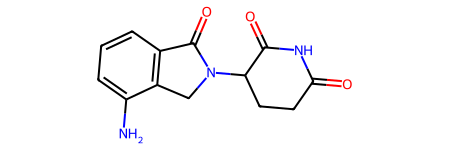

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6735459662288931
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.670404984423676
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6646115906288532
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6662546353522868
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6652281134401973
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6658431130327362
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.654380664652568
--------

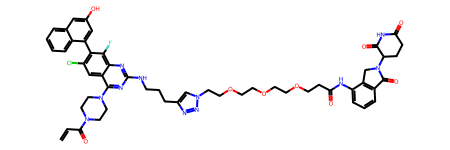

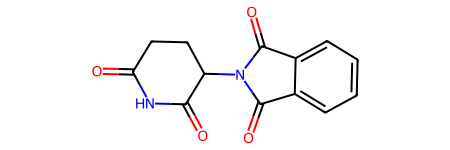

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.42981945253348863


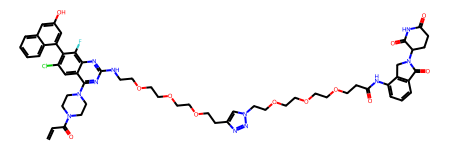

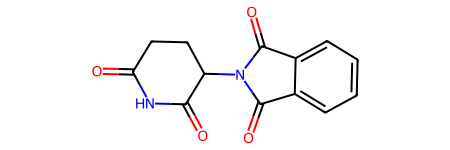

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5555555555555556
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7238848108413326
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8001086366105378
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8001086366105378
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7724803862401931
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.39967637540453077


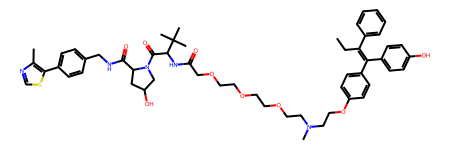

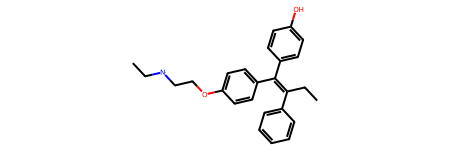

non-matching E3 Binder SMILES. Tanimoto: 0.7470449172576832
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.40425531914893614


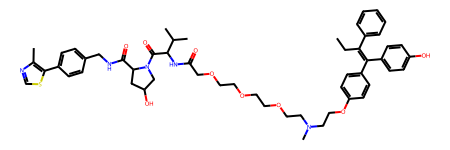

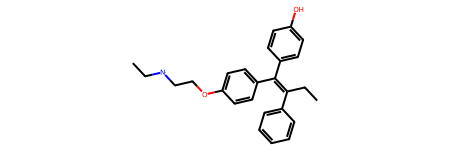

non-matching E3 Binder SMILES. Tanimoto: 0.742879746835443
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5610607117934403
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5606694560669456
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5606694560669456
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5423956931359354
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5423956931359354
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5423956931359354
--------------------------------------------------------------------------------
non-matc

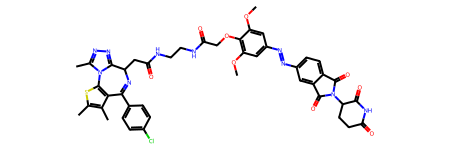

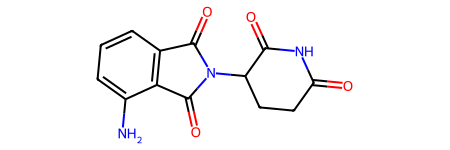

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8194826637314254
non-matching E3 Binder SMILES. Tanimoto: 0.48819330038440417


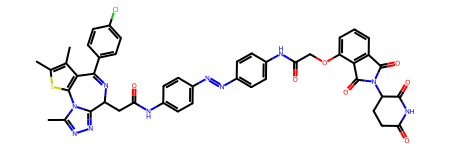

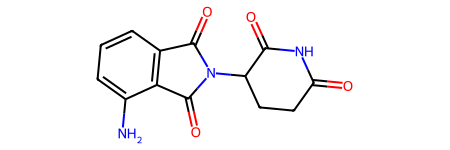

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8148959474260679
non-matching E3 Binder SMILES. Tanimoto: 0.4876847290640394


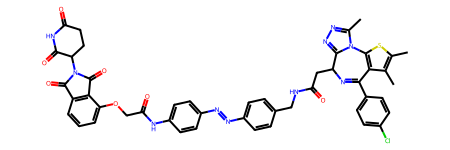

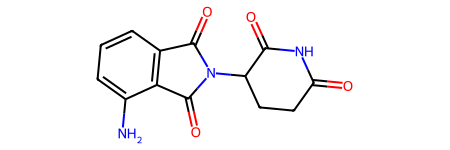

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8140043763676149
non-matching E3 Binder SMILES. Tanimoto: 0.48877941981390255


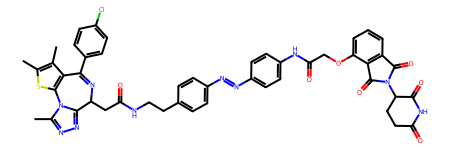

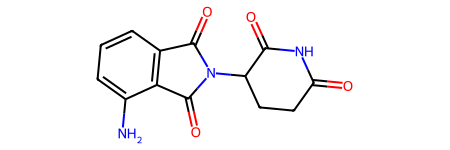

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8051807879114948
non-matching E3 Binder SMILES. Tanimoto: 0.48354020507285483


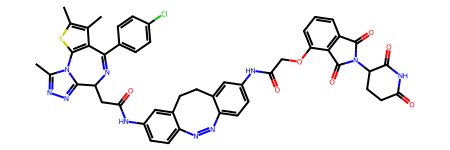

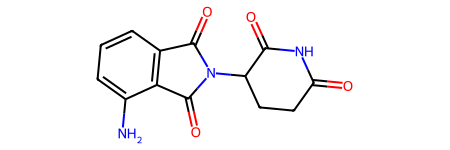

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.641042345276873
non-matching E3 Binder SMILES. Tanimoto: 0.5487571701720841
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6576338400528751
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6602521566025216
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6598143236074271
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6602521566025216
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6808219178082192
--------------------------------------------------------------------------------
non-matc

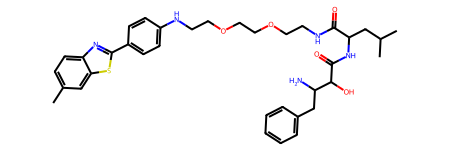

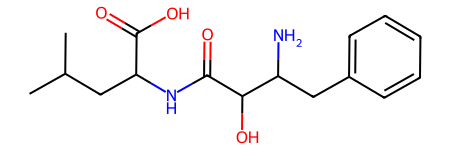

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4194395796847636


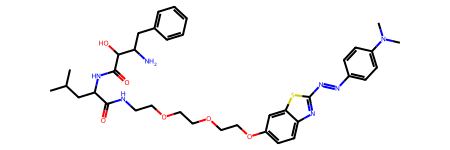

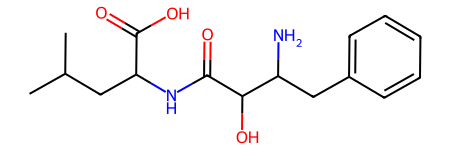

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6680851063829787
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6652542372881356
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6648517846339987
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6728358208955224
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6710291493158834
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6702317290552585
--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.5347661188369153
-------

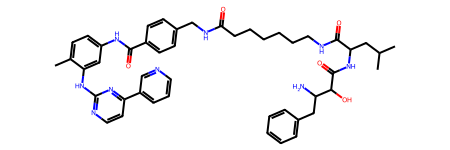

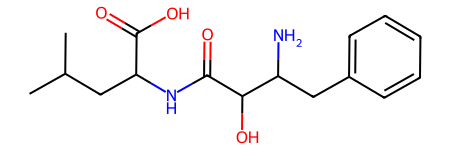

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7197290431837426
non-matching E3 Binder SMILES. Tanimoto: 0.4057480980557904


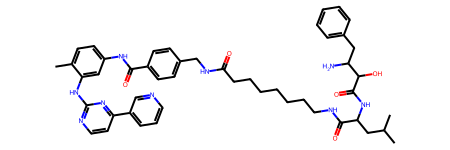

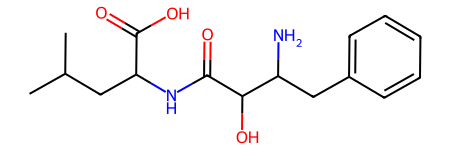

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7197290431837426
non-matching E3 Binder SMILES. Tanimoto: 0.4057480980557904


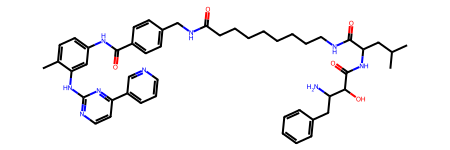

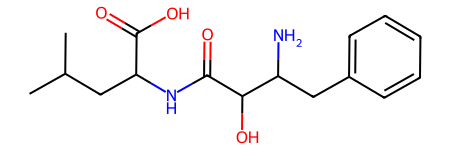

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.5377777777777778
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5952537903757416
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.591743119266055
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.589041095890411
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5898105813193991
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.55775169857937
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5587871287128713
-----------

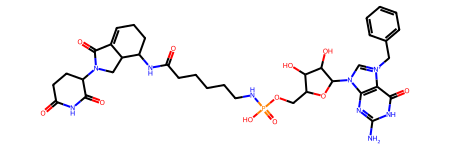

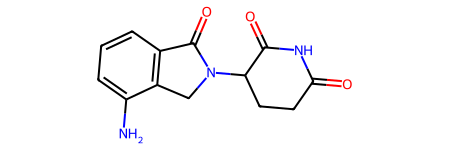

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4171270718232044


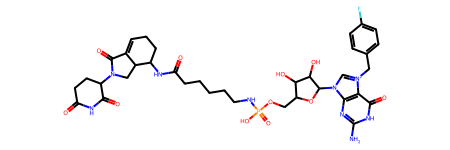

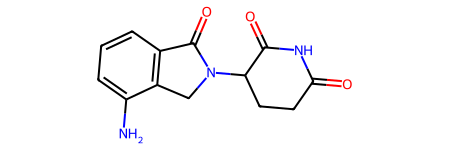

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8054607508532423
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8029697315819532
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7299093655589124
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.821247892074199
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.8189509306260575
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7514898688915376
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7510422870756402
-------

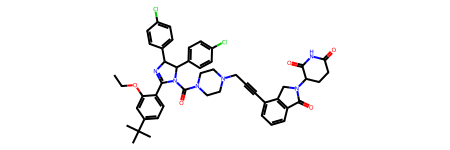

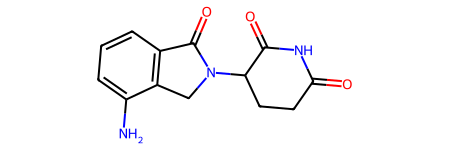

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.49814585908529047


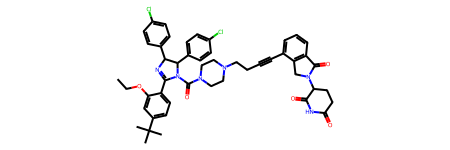

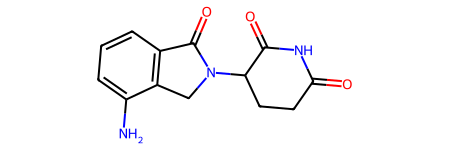

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.496


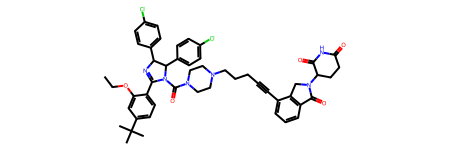

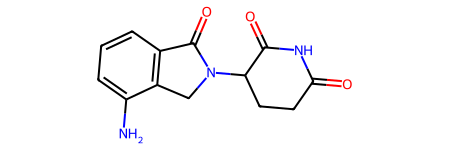

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.49056603773584906


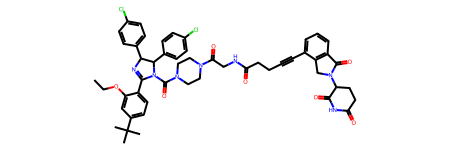

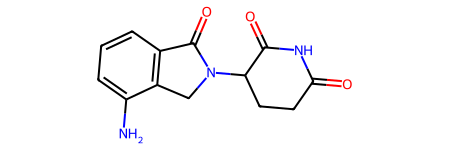

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4932844932844933


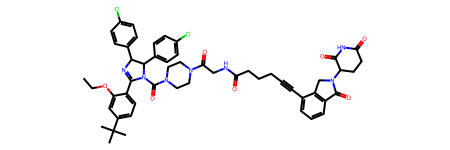

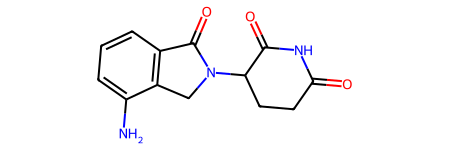

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4899696048632219


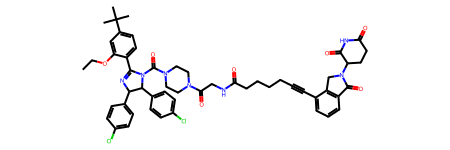

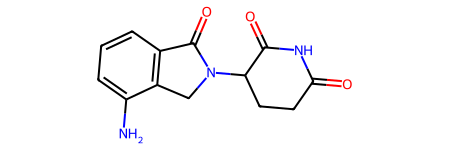

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4938800489596083


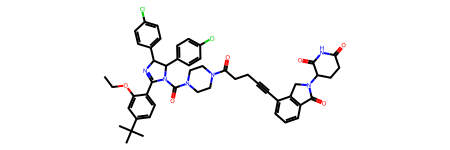

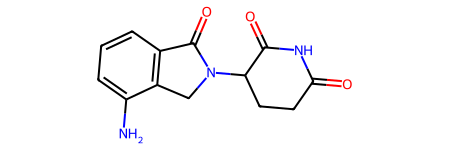

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.49692874692874694


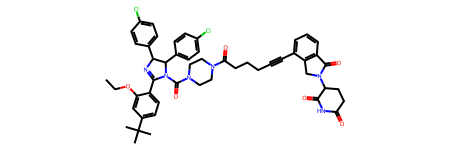

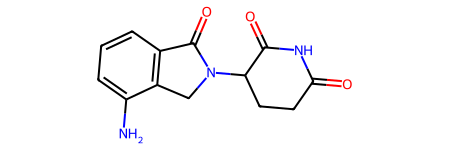

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4935779816513762


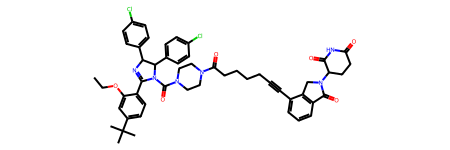

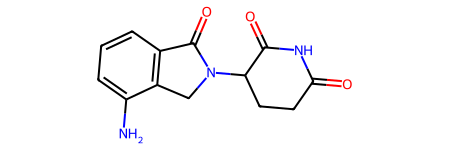

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.49692118226600984


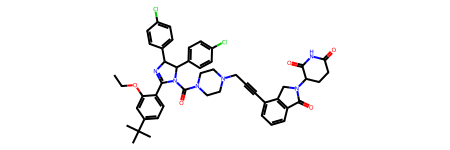

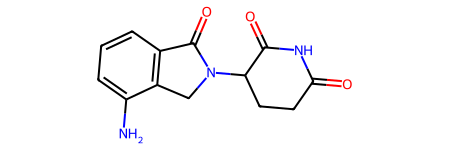

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.49814585908529047


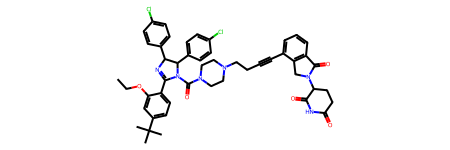

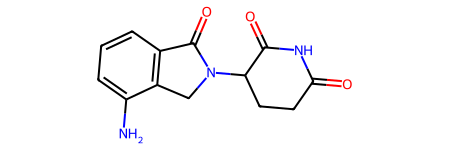

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.496


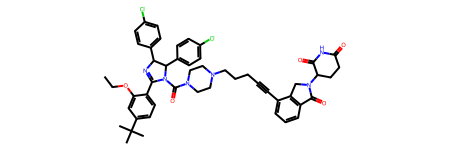

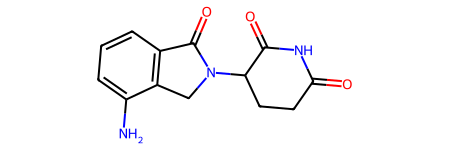

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.48875479978058145


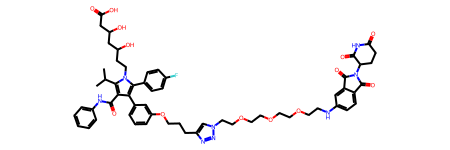

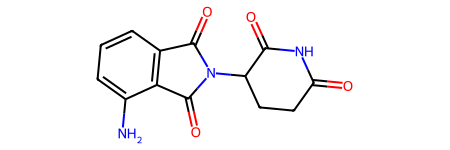

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4876847290640394


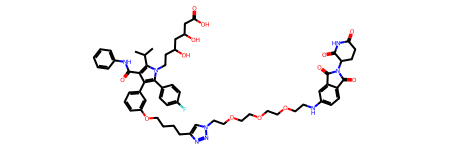

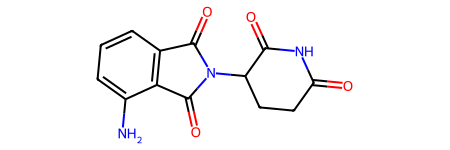

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.486870897155361


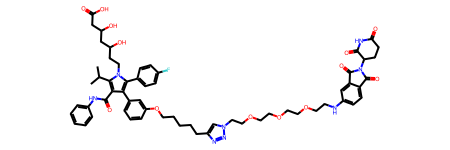

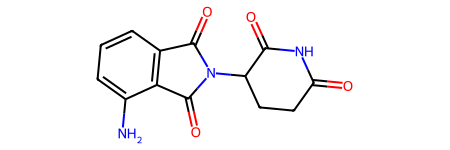

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.48875479978058145


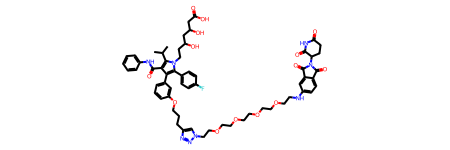

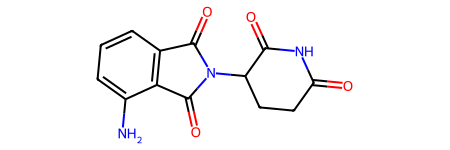

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4876847290640394


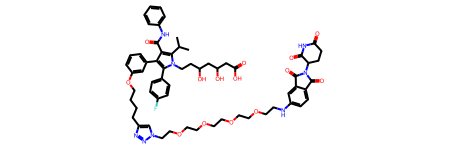

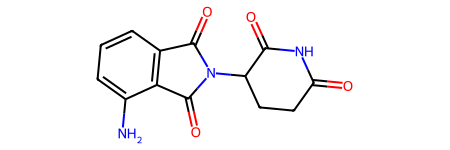

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.486870897155361


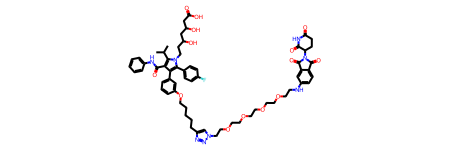

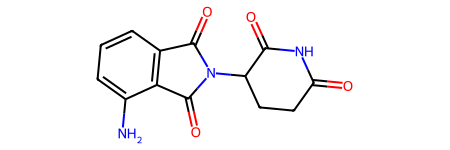

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4740295243302351


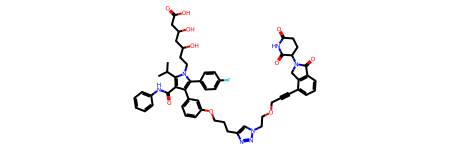

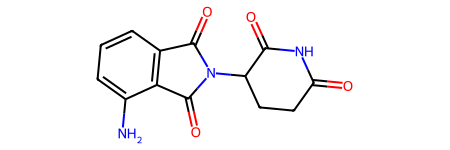

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.47538293216630195


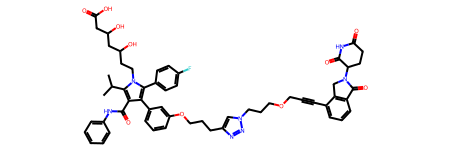

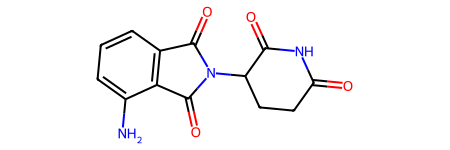

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.47538293216630195


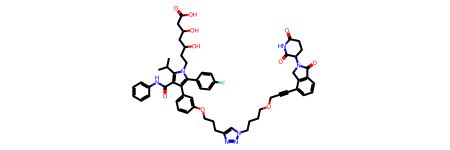

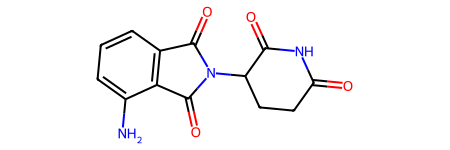

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.47752192982456143


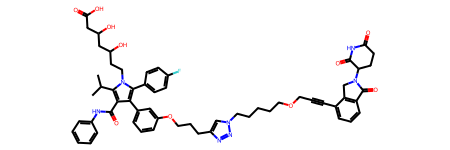

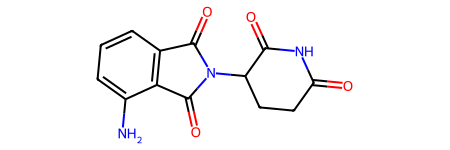

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4767123287671233


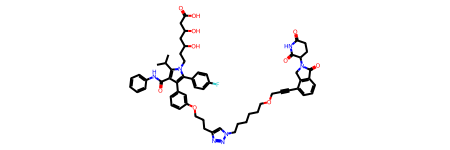

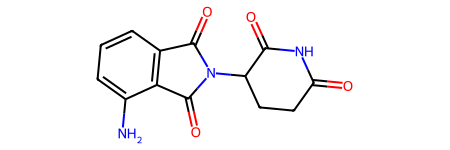

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4767123287671233


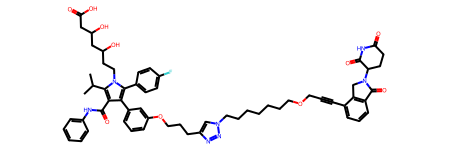

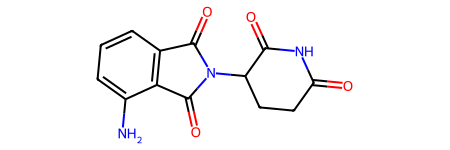

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4777838727372463


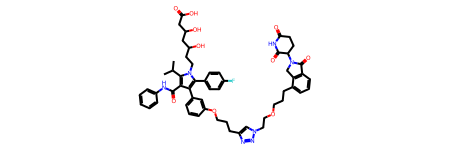

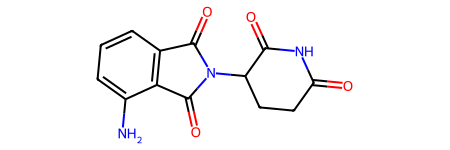

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.47885777045579353


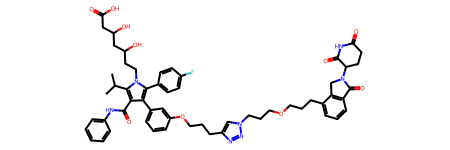

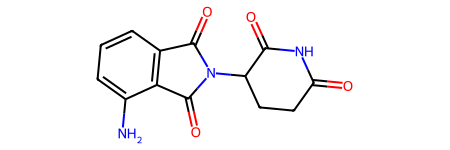

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4791437980241493


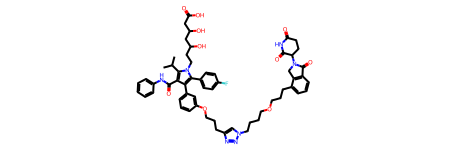

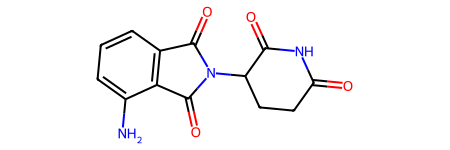

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4804837822979659


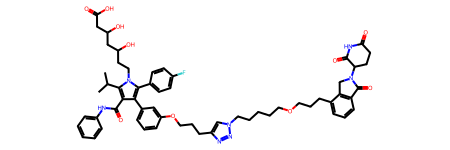

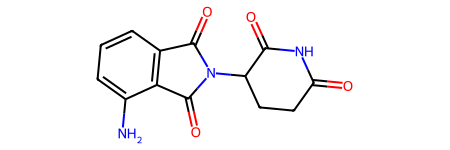

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.479934029686641


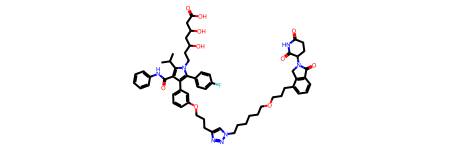

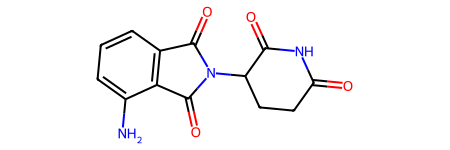

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.479934029686641


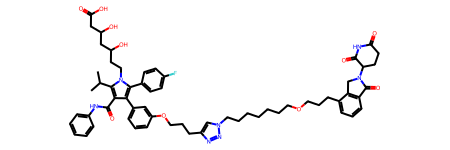

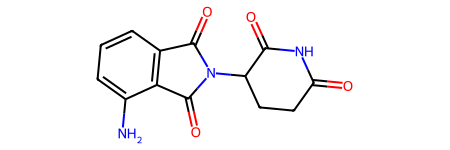

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7452367991290147
non-matching E3 Binder SMILES. Tanimoto: 0.6612289287656336
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7452367991290147
non-matching E3 Binder SMILES. Tanimoto: 0.6612289287656336
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7677672076105204
non-matching E3 Binder SMILES. Tanimoto: 0.6757660167130919
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7677672076105204
non-matching E3 Binder SMILES. Tanimoto: 0.6757660167130919
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.7686692869174621
non-matching E3 Binder SMILES. Tanimoto: 0.6782316

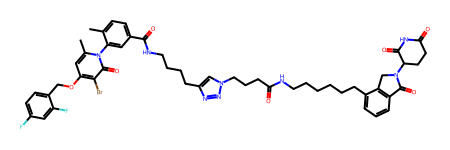

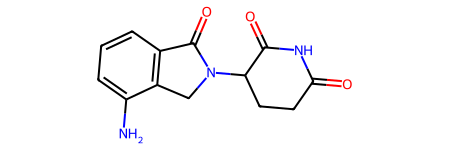

--------------------------------------------------------------------------------
non-matching E3 Binder SMILES. Tanimoto: 0.4896341463414634


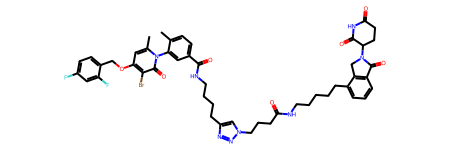

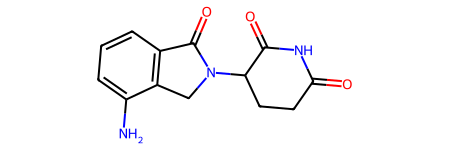

--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.557991513437058
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5502092050209205
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.5702898550724638
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6333109469442579
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6358732299393122
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6307692307692307
--------------------------------------------------------------------------------
non-matching POI Ligand SMILES. Tanimoto: 0.6358732299393122
-------

In [76]:
matching_substructs = {k: set() for k in ['POI Ligand SMILES', 'Linker SMILES', 'E3 Binder SMILES']}
cnt = Counter()
# Iterate over protac_pedia_df rows
for i, row in enumerate(protac_pedia_df.iterrows()):
    # Get the row as a dict
    row_dict = row[1].to_dict()
    protac_smiles = row_dict['PROTAC SMILES']
    protac_mol = Chem.MolFromSmiles(protac_smiles)
    Chem.rdmolops.RemoveStereochemistry(protac_mol)

    all_matching = True
    for substruct in matching_substructs.keys():
        substruct_smiles = row_dict[substruct]
        substruct_mol = Chem.MolFromSmiles(substruct_smiles)
        Chem.rdmolops.RemoveStereochemistry(substruct_mol)
        if substruct_mol is not None and protac_mol.HasSubstructMatch(substruct_mol):
            cnt[f'matching {substruct}'] += 1
            matching_substructs[substruct].add(substruct_smiles)
        elif substruct is not None:
            all_matching = False
            cnt[f'non-matching {substruct}'] += 1
            tanimoto = get_tanimoto(protac_smiles, substruct_smiles)
            print(f'non-matching {substruct}. Tanimoto: {tanimoto}')
            if tanimoto < 0.5:
                display(protac_mol)
                display(substruct_mol)
        else:
            cnt[f'none {substruct}'] += 1
            all_matching = False
    if not all_matching:
        print('-' * 80)
    else:
        cnt[f'all matching'] += 1
    
        


    # poi_smiles = row_dict['POI Ligand SMILES']
    # linker_smiles = row_dict['Linker SMILES']
    # e3_smiles = row_dict['E3 Binder SMILES']
    
    # poi_mol = Chem.MolFromSmiles(poi_smiles)
    # linker_mol = Chem.MolFromSmiles(linker_smiles)
    # e3_mol = Chem.MolFromSmiles(e3_smiles)
    # Chem.rdmolops.RemoveStereochemistry(protac_mol)
    # Chem.rdmolops.RemoveStereochemistry(poi_mol)
    # Chem.rdmolops.RemoveStereochemistry(linker_mol)
    # Chem.rdmolops.RemoveStereochemistry(e3_mol)

    # all_matching = True
    # for substruct, name in [(poi_mol, 'POI'), (linker_mol, 'Linker'), (e3_mol, 'E3')]:
    #     if substruct is not None and protac_mol.HasSubstructMatch(substruct):
    #         cnt[f'matching {name}'] += 1
    #     elif substruct is not None:
    #         cnt[f'non-matching {name}'] += 1
    #         print(f'non-matching {name}:')
    #         print_stats(protac_smiles, e3_smiles, linker_smiles, poi_smiles)
    #         all_matching = False
    #     else:
    #         cnt[f'none {name}'] += 1
    #         all_matching = False
    # if not all_matching:
    #     print('-' * 80)

print(cnt)

    # if protac_mol.HasSubstructMatch(linker_mol):
    #     rgroups = Chem.ReplaceCore(protac_mol, linker_mol, labelByIndex=False)
    #     rgroups_smiles = Chem.MolToSmiles(rgroups).split('.')
    #     print('E3 and POI substructures:')
    #     display(rgroups)
    #     for j, substruct_smiles in enumerate(rgroups_smiles):
    #         print(f'Substructure {j}: {substruct_smiles}')
    #         if Chem.MolFromSmiles(substruct_smiles).HasSubstructMatch(e3_mol):
    #             label = '1'
    #             poi_smiles_mod = substruct_smiles.replace(f'[{j + 1}*]', f'[*:{label}]')
    #             print(f'Modified E3: {poi_smiles_mod}')
    #             display(Chem.MolFromSmiles(poi_smiles_mod))
    #         elif Chem.MolFromSmiles(substruct_smiles).HasSubstructMatch(poi_mol):
    #             label = '2'
    #             poi_smiles_mod = substruct_smiles.replace(f'[{j + 1}*]', f'[*:{label}]')
    #             print(f'Modified POI: {poi_smiles_mod}')
    #             display(Chem.MolFromSmiles(poi_smiles_mod))
    #         else:
    #             print('Neither E3 nor POI match')
    # else:
    #     print('No linker match')
    # # get linker with attachment points
    # if protac_mol.HasSubstructMatch(poi_mol):
    #     rgroups = Chem.ReplaceCore(protac_mol, poi_mol, labelByIndex=False)
    #     rgroups_smiles = Chem.MolToSmiles(rgroups)
    #     display (rgroups)
    #     label='1'
    #     linker_e3_smi_mod = rgroups_smiles.replace('[1*]', '[*:'+label+']')
    #     print (linker_e3_smi_mod)

    #     linker_e3_mol = Chem.MolFromSmiles(linker_e3_smi_mod)
            
    #     if linker_e3_mol.HasSubstructMatch(e3_mol):
    #         rgroups = Chem.ReplaceCore(linker_e3_mol, e3_mol, labelByIndex=False)
    #         rgroups_smiles = Chem.MolToSmiles(rgroups)
    #         display (rgroups)

    #         label='2'
    #         linker_smi_mod = rgroups_smiles.replace('[1*]', '[*:'+label+']')
    #         print (linker_smi_mod)
    #         display(Chem.MolFromSmiles(linker_smi_mod))
    # else:
    #     print('No POI match')
    # print('-' * 80)
    # if i > 5:
    #     break

In [77]:
for substruct, smiles_set in matching_substructs.items():
    print(f'{substruct}: {len(smiles_set)}')

POI Ligand SMILES: 118
Linker SMILES: 642
E3 Binder SMILES: 53
